# TruthLens: An Evidence-Aware NLP Framework for Claim Verification and Narrative Analysis in Indian Social Media

**Phase 1 - Reproducible Research & Experimentation Notebook**

This notebook implements the TruthLens pipeline from the project synopsis and evaluates it on **real, publicly accessible datasets**: **FEVER** (Thorne et al., 2018) [6], **AVeriTeC** (Schlichtkrull et al., 2023) [5] and **FactDrill** (Singhal et al., 2022) [4].

## Structure

| Part | Content | Data |
|---|---|---|
| 1-9 | Pipeline implementation + **demonstration corpus** (clearly labelled, used ONLY to validate the code end-to-end and to evaluate layers that real benchmarks do not annotate: atomic-claim extraction, temporal-mismatch gold flags, evidence-graph demo) | demo (synthetic rewrites of public facts) |
| 10 | **Real Experiment A - FEVER**: retrieval + verdict classification, 600 dev claims, baselines, ablations, bootstrap CIs, McNemar | real |
| 11 | **Real Experiment B - AVeriTeC**: 500 real-world claims with 4-way labels incl. *Conflicting Evidence*, web QA evidence, India subset, narrative clustering, **and temporal robustness (11.7)** | real |
| 12 | **Real Experiment C - FactDrill**: real Indian fact-check archive characterisation + claim-to-fact-check retrieval in English and Hindi, **leaky vs de-leaked** | real |
| 13 | Cross-dataset consolidated results + experiment registry | real |
| 14 | Limitations, dataset acquisition, reproducibility | - |

## Reproducibility
- All randomness is seeded (`SEED = 42`); sampling of claims is deterministic.
- Heavy experiment outputs are **cached** in `data/cache/` and reloaded on re-run (set `FORCE_RERUN = True` to recompute).
- Dataset acquisition/preparation scripts are provided (`prep_fever.py`, `prep_fever_expand.py`, `prep_averitec.py`, `prep_factdrill.py`) and documented in Part 14.2. `run_notebook.py` executes this notebook end to end.
- **NLI model follows the hardware.** On CUDA/MPS the judge is `DeBERTa-v3-large-mnli-fever-anli-ling-wanli` (MNLI+**FEVER**+ANLI trained); on bare CPU it falls back to `nli-MiniLM2-L6-H768`, because the large model runs at ~5 pairs/s there. The tier is printed at startup and is part of every cache key, so the two can never be mixed.
- **Light mode:** `USE_TRANSFORMERS = False` (or env `TRUTHLENS_LIGHT=1`) - TF-IDF embeddings + transparent heuristic judge; runs offline in ~1 min, but the real-dataset experiments are skipped (they require the NLI model).

## Three protocol issues found in Phase 1, and how each is handled

Each of these would have produced a real-looking but misleading number. None is hidden; each is measured and reported in both settings.

1. **FEVER's cheap evidence corpus inflates retrieval.** Building the corpus from gold evidence pages only makes every distractor topically relevant. Measured inflation: hybrid Recall@5 **0.788 -> 0.669** when 200k random distractor sentences are added. Both settings reported (Part 10.2).
2. **FactDrill's `claim` is copied out of its own article** (89.8% verbatim overlap), so claim-to-fact-check retrieval is largely duplicate detection. Both the leaky and the de-leaked corpus are reported (Part 12.2).
3. **AVeriTeC's evidence is mostly retrospective** - only ~9% of gold evidence provably pre-dates its claim. Temporal experiments therefore separate what the dates can and cannot prove, and the strict contemporaneous condition is reported as a **bound**, not a score (Part 11.7).

**Demo-corpus numbers are demonstration/validation figures only and are never presented as research results.** Their artifacts are written with a `demo_` filename prefix. All research numbers come from Parts 10-12 (real datasets).

All artifacts (tables, figures, JSON) are saved to `./truthlens_outputs/`.

In [1]:
# ============================================================================
# 1. SETUP AND CONFIGURATION
# ============================================================================
import os, sys, importlib, subprocess, warnings
warnings.filterwarnings("ignore")

LIGHT_MODE = os.environ.get("TRUTHLENS_LIGHT", "0") == "1"

def _ensure(modules):
    for mod, pip_name in modules:
        try:
            importlib.import_module(mod)
        except ImportError:
            print("Installing", pip_name, "...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

_ensure([("pandas", "pandas"), ("numpy", "numpy"), ("sklearn", "scikit-learn"),
         ("matplotlib", "matplotlib"), ("networkx", "networkx")])

# ---- transformer stack (optional, for full research mode) -------------------
# USE_TRANSFORMERS=False -> light mode: TF-IDF embeddings + heuristic NLI judge.
USE_TRANSFORMERS = not LIGHT_MODE
TRANSFORMERS_OK = False
if USE_TRANSFORMERS:
    try:
        import torch, transformers, sentence_transformers  # noqa
        TRANSFORMERS_OK = True
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                                   "torch", "transformers", "sentence-transformers"])
            import torch, transformers, sentence_transformers  # noqa
            TRANSFORMERS_OK = True
        except Exception as e:
            print("Transformer stack unavailable, running with fallbacks:", e)
print("Full transformer mode:", TRANSFORMERS_OK)

import pandas as pd, numpy as np, re, json, math, random, time, heapq, hashlib
from datetime import date
from collections import Counter, defaultdict
EXPERIMENT_REGISTRY = []      # every real experiment appends its status here
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 180)
import sklearn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# display() shim: in Jupyter, IPython provides a rich display; in plain python
# (e.g. automated test execution) fall back to print.
try:
    display  # noqa: F821  (exists in Jupyter)
except NameError:
    def display(obj):
        print(obj)

# ---- experiment configuration (reproducibility) ------------------------------
SEED = 42
np.random.seed(SEED)
FORCE_RERUN = False          # set True to recompute every cached experiment
# ---- device selection and NLI model tier ------------------------------------
# Measured on the reference machine (Apple M1 Pro, 14 cores, 32 GB, torch 2.14.0):
#   DeBERTa-v3-large   CPU   5.3 pairs/s -> MPS fp16  69.2 pairs/s  (13.1x)
#   mDeBERTa-v3-base   CPU  14.0 pairs/s -> MPS fp16 150.0 pairs/s  (10.7x)
#   MiniLM2-L6-H768    CPU 352.4 pairs/s -> MPS fp16 404.1 pairs/s  ( 1.1x, launch-bound)
# The strong model is FEVER-trained, so it is the right judge for this task --
# but at 5 pairs/s on bare CPU the suite takes hours. Tier therefore follows the
# available accelerator, and the chosen tier is recorded in every cache key and
# in the results so a CPU run can never be confused with an accelerated one.
DEVICE = "cpu"
if TRANSFORMERS_OK:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
    elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        DEVICE = "mps"

NLI_MODEL_STRONG       = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
NLI_MODEL_MULTILINGUAL = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
NLI_MODEL_SMALL        = "cross-encoder/nli-MiniLM2-L6-H768"
NLI_TIER = os.environ.get("TRUTHLENS_NLI_TIER") or ("strong" if DEVICE in ("cuda", "mps") else "small")
NLI_MODEL_NAME = {"strong": NLI_MODEL_STRONG, "small": NLI_MODEL_SMALL,
                  "multilingual": NLI_MODEL_MULTILINGUAL}[NLI_TIER]
# fp16 on accelerators only; fp16 on CPU is slower, not faster.
TORCH_DTYPE = "float16" if DEVICE in ("cuda", "mps") else "float32"

def _free_accelerator():
    # Release cached blocks. Several cells hold two or three models on the device
    # at once; without this, a large encode on top of them can take the kernel down
    # with no traceback at all (it is killed, not raised).
    if not TRANSFORMERS_OK:
        return
    try:
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        elif DEVICE == "mps":
            torch.mps.empty_cache()
    except Exception:
        pass

print(f"Device: {DEVICE} | NLI tier: {NLI_TIER} | NLI model: {NLI_MODEL_NAME}")

DATA_DIR = os.path.join(os.getcwd(), "data")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")
CACHE_DIR = os.path.join(DATA_DIR, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)
OUT_DIR = os.path.join(os.getcwd(), "truthlens_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

if TRANSFORMERS_OK:
    import torch
    torch.set_num_threads(max(2, min(16, os.cpu_count() or 8)))

def _cache_tag():
    # Caches are tagged by run mode AND NLI tier, so light-mode (fallback)
    # results can never be mistaken for full-mode (transformer) results, and
    # small-model results can never be mistaken for strong-model results.
    return f"full_{NLI_TIER}" if TRANSFORMERS_OK else "light"

def load_cache(name):
    path = os.path.join(CACHE_DIR, f"{name}_{_cache_tag()}.json")
    if not FORCE_RERUN and os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    return None

def save_cache(name, obj):
    with open(os.path.join(CACHE_DIR, f"{name}_{_cache_tag()}.json"), "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=1)

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=SEED):
    # Bootstrap 95% CI for a metric: returns (mean, low, high)
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    if n == 0:
        return (0.0, 0.0, 0.0)
    # One resample index per replicate, applied to BOTH arrays. Drawing two
    # independent index sets (as an earlier version did) breaks the pairing
    # between a claim's gold label and its own prediction, so the statistic
    # collapses towards the random-pairing rate -- 0.333 on a balanced 3-class
    # task, regardless of how good the system actually is.
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))
    return (round(float(np.mean(vals)), 3),
            round(float(np.percentile(vals, 2.5)), 3),
            round(float(np.percentile(vals, 97.5)), 3))

def mcnemar_test(pred_a, pred_b, y_true):
    # McNemar's chi-square test on paired correctness of two systems
    a_ok = np.asarray(pred_a) == np.asarray(y_true)
    b_ok = np.asarray(pred_b) == np.asarray(y_true)
    b, c = int(np.sum(a_ok & ~b_ok)), int(np.sum(~a_ok & b_ok))
    if b + c == 0:
        return dict(b=b, c=c, chi2=0.0, p=1.0)
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p = math.erfc(math.sqrt(chi2 / 2))     # chi-square df=1 survival function
    return dict(b=b, c=c, chi2=round(chi2, 3), p=round(p, 5))

def acc_metric(y, p): return accuracy_score(y, p)
def macro_f1_metric(y, p): return f1_score(y, p, average="macro", zero_division=0)

print("versions: python", sys.version.split()[0],
      "| torch", (torch.__version__ if TRANSFORMERS_OK else "n/a"),
      "| transformers", (transformers.__version__ if TRANSFORMERS_OK else "n/a"),
      "| sklearn", sklearn.__version__, "| numpy", np.__version__)
print("Artifacts folder:", OUT_DIR)
print("Data folder:", DATA_DIR)

Full transformer mode: True
Device: mps | NLI tier: strong | NLI model: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
versions: python 3.11.16 | torch 2.14.0 | transformers 5.17.0 | sklearn 1.9.1 | numpy 2.4.6
Artifacts folder: /Users/habuild/codes/personal/temp/TruthLens/truthlens_outputs
Data folder: /Users/habuild/codes/personal/temp/TruthLens/data


## 2. Demonstration Corpus (PIPELINE VALIDATION DATA - NOT RESEARCH RESULTS)

> **DISCLOSURE:** the built-in corpus in this section is **synthetic demonstration data** (rewrites of well-documented public facts). It exists to (a) validate every pipeline component end-to-end, and (b) evaluate layers that the real benchmarks do not annotate at all: **atomic-claim extraction gold labels**, **temporal-mismatch (recycled content) gold flags**, and the **evidence-graph**. Numbers computed on this corpus are validation/sanity figures and must not be presented as research results. All research results come from the real datasets in Parts 10-12 (FEVER, AVeriTeC, FactDrill).

The demonstration corpus contains social-media-style posts about real, well-documented Indian public events (Article 370 revocation, Chandrayaan-3, COVID-19 lockdown, 2024 general election, Balasore train collision, Silkyara tunnel rescue, demonetisation). Each post carries **gold atomic claims**, a **gold verdict** (Supported / Refuted / Not Enough Evidence / Conflicting Evidence), **gold evidence links**, an **event label** and a **temporal-mismatch gold flag**. It deliberately includes Hinglish and Hindi posts, multi-claim posts, partially-true posts, out-of-context recycled news and claims with genuinely conflicting evidence (early vs final death tolls).

*Data ethics: all texts are synthetic rewrites of publicly reported facts; no real user content or private data is used.*

In [2]:
# ============================================================================
# 2.1 Evidence corpus: 30 documents from credible sources with provenance
# ============================================================================
EVIDENCE_DOCS = [
 dict(id="E01", text="The President of India issued Constitution Order 272 on 5 August 2019, applying all provisions of the Indian Constitution to Jammu and Kashmir and effectively revoking Article 370.", source="PIB (Govt. of India)", stype="government", sdate="2019-08-05", url="https://pib.gov.in"),
 dict(id="E02", text="Union Home Minister Amit Shah announced in the Rajya Sabha on 5 August 2019 that the government had revoked Article 370 and proposed bifurcating the state into two Union Territories.", source="The Hindu", stype="news", sdate="2019-08-05", url="https://www.thehindu.com"),
 dict(id="E03", text="The Jammu and Kashmir Reorganisation Act, passed in August 2019, bifurcated the state of Jammu and Kashmir (J&K) into two Union Territories: Jammu & Kashmir and Ladakh. It came into effect on 31 October 2019.", source="PIB (Govt. of India)", stype="government", sdate="2019-10-31", url="https://pib.gov.in"),
 dict(id="E04", text="Pakistan raised the issue of Kashmir at the UN Security Council during closed-door consultations on 16 August 2019, the first such discussion in decades.", source="Reuters", stype="news", sdate="2019-08-16", url="https://www.reuters.com"),
 dict(id="E05", text="Fact check: Social media posts claiming Article 370 was revoked in 2020 are false. The revocation took place on 5 August 2019.", source="Alt News", stype="factcheck", sdate="2020-04-02", url="https://www.altnews.in"),
 dict(id="E06", text="ISRO confirmed that the Vikram lander of Chandrayaan-3 achieved a soft landing near the lunar south pole at 18:04 IST on 23 August 2023.", source="ISRO (Govt. of India)", stype="government", sdate="2023-08-23", url="https://www.isro.gov.in"),
 dict(id="E07", text="With Chandrayaan-3's landing, India became the fourth country to soft-land on the Moon and the first to land near the lunar south pole.", source="BBC", stype="news", sdate="2023-08-23", url="https://www.bbc.com"),
 dict(id="E08", text="ISRO Chairman S. Somanath stated that the total cost of Chandrayaan-3 was approximately Rs 615 crore.", source="The Hindu", stype="news", sdate="2023-08-22", url="https://www.thehindu.com"),
 dict(id="E09", text="Viral posts claiming Chandrayaan-3 failed and that ISRO admitted the mission was unsuccessful are false. ISRO confirmed a successful soft landing on 23 August 2023.", source="PIB Fact Check", stype="factcheck", sdate="2023-08-27", url="https://factcheck.pib.gov.in"),
 dict(id="E10", text="Chandrayaan-3's lander is named Vikram; Pragyan is the rover. Posts claiming the lander was named Pragyan are false.", source="Alt News", stype="factcheck", sdate="2023-08-25", url="https://www.altnews.in"),
 dict(id="E11", text="In a televised address on 24 March 2020, Prime Minister Narendra Modi announced a complete nationwide lockdown for 21 days, beginning from 25 March 2020, to control the spread of COVID-19.", source="PIB (Govt. of India)", stype="government", sdate="2020-03-24", url="https://pib.gov.in"),
 dict(id="E12", text="India's first confirmed case of COVID-19 was reported on 30 January 2020 in Kerala, a student returning from Wuhan, China.", source="The Hindu", stype="news", sdate="2020-01-31", url="https://www.thehindu.com"),
 dict(id="E13", text="The Election Commission of India declared the results of the 2024 Lok Sabha elections on 4 June 2024: the BJP won 240 seats and the Indian National Congress won 99 seats.", source="Election Commission of India", stype="government", sdate="2024-06-04", url="https://results.eci.gov.in"),
 dict(id="E14", text="Narendra Modi was sworn in as Prime Minister for a third consecutive term on 9 June 2024, leading an NDA coalition government.", source="The Hindu", stype="news", sdate="2024-06-09", url="https://www.thehindu.com"),
 dict(id="E15", text="Fact check: Viral claims that the BJP won 300 seats in the 2024 Lok Sabha elections are false. As per ECI results, the BJP won 240 seats.", source="PIB Fact Check", stype="factcheck", sdate="2024-06-06", url="https://factcheck.pib.gov.in"),
 dict(id="E16", text="At least 280 people died in the Balasore train accident and around 900 were injured when the Coromandel Express derailed near Balasore, Odisha on the evening of 2 June 2023, according to early reports on 3 June.", source="NDTV", stype="news", sdate="2023-06-03", url="https://www.ndtv.com"),
 dict(id="E17", text="The Odisha state government said that 288 people died in the Balasore train accident on 4 June 2023.", source="The Hindu", stype="news", sdate="2023-06-04", url="https://www.thehindu.com"),
 dict(id="E18", text="Official figures later revised the death toll to 296 people who died in the Balasore train accident. The CBI was ordered to investigate the cause of the accident, and reports pointed to unauthorised changes in the signalling circuit wiring at the station.", source="Reuters", stype="news", sdate="2023-06-12", url="https://www.reuters.com"),
 dict(id="E19", text="A preliminary report by the Commission of Railway Safety indicated issues with the signalling system near Bahanaga Bazar station; the exact cause of the Coromandel Express derailment remained under investigation, with the CBI probing possible tampering.", source="The Hindu", stype="news", sdate="2023-06-23", url="https://www.thehindu.com"),
 dict(id="E20", text="All 41 workers trapped in the collapsed Silkyara tunnel in Uttarakhand were rescued on 28 November 2023, 17 days after the collapse on 12 November 2023.", source="The Hindu", stype="news", sdate="2023-11-28", url="https://www.thehindu.com"),
 dict(id="E21", text="Rescuers used horizontal drilling with auger machines for most of the Silkyara tunnel operation; the final 12 metres were completed by manual rat-hole mining after the auger machine broke down.", source="The Hindu", stype="news", sdate="2023-11-29", url="https://www.thehindu.com"),
 dict(id="E22", text="UPI processed 10 billion transactions in August 2023, a record at the time, with a total value of about Rs 15.7 lakh crore, according to NPCI data.", source="Economic Times", stype="news", sdate="2023-09-05", url="https://economictimes.indiatimes.com"),
 dict(id="E23", text="On 8 November 2016, the government announced that Rs 500 and Rs 1000 notes would cease to be legal tender, withdrawing about 86% of the currency in circulation by value.", source="RBI (Govt. of India)", stype="government", sdate="2016-11-08", url="https://www.rbi.org.in"),
 dict(id="E24", text="The three farm laws were repealed by Parliament in the winter session on 29 November 2021, after Prime Minister Modi announced the repeal on 19 November 2021.", source="The Hindu", stype="news", sdate="2021-11-29", url="https://www.thehindu.com"),
 dict(id="E25", text="Droupadi Murmu was sworn in as the 15th President of India on 25 July 2022.", source="PIB (Govt. of India)", stype="government", sdate="2022-07-25", url="https://pib.gov.in"),
 dict(id="E26", text="Australia won the 2023 Cricket World Cup, defeating India by 6 wickets in the final at Ahmedabad on 19 November 2023.", source="The Hindu", stype="news", sdate="2023-11-19", url="https://www.thehindu.com"),
 dict(id="E27", text="India's GDP growth for Q4 of FY 2023-24 was estimated at 7.8%, with full-year growth of 8.2%, according to MoSPI data released on 31 May 2024.", source="MoSPI (Govt. of India)", stype="government", sdate="2024-05-31", url="https://www.mospi.gov.in"),
 dict(id="E28", text="Cyclone Biparjoy made landfall near Jakhau in Gujarat on 15 June 2023, prompting the evacuation of over one lakh people.", source="The Hindu", stype="news", sdate="2023-06-15", url="https://www.thehindu.com"),
 dict(id="E29", text="The new Parliament building of India was inaugurated by Prime Minister Narendra Modi on 28 May 2023.", source="PIB (Govt. of India)", stype="government", sdate="2023-05-28", url="https://pib.gov.in"),
 dict(id="E30", text="Agnipath, a new scheme for recruitment of soldiers into the armed forces, was announced by the Defence Ministry on 14 June 2022.", source="The Hindu", stype="news", sdate="2022-06-14", url="https://www.thehindu.com"),
]
EVIDENCE_BY_ID = {e["id"]: e for e in EVIDENCE_DOCS}
EVIDENCE_IDS = [e["id"] for e in EVIDENCE_DOCS]
print("Evidence documents:", len(EVIDENCE_DOCS))
pd.DataFrame(EVIDENCE_DOCS)[["id", "stype", "source", "sdate"]].head(8)

Evidence documents: 30


,id,stype,source,sdate
0,E01,government,PIB (Govt. of India),2019-08-05
1,E02,news,The Hindu,2019-08-05
2,E03,government,PIB (Govt. of India),2019-10-31
3,E04,news,Reuters,2019-08-16
4,E05,factcheck,Alt News,2020-04-02
5,E06,government,ISRO (Govt. of India),2023-08-23
6,E07,news,BBC,2023-08-23
7,E08,news,The Hindu,2023-08-22


In [3]:
# ============================================================================
# 2.2 Gold dataset: 18 posts, 31 atomic claims across 8 events
# Labels: Supported (S) / Refuted (R) / Not Enough Evidence (NEI) / Conflicting Evidence (CE)
# ============================================================================
POSTS = [
 dict(id="P01", lang="en", event="A370_2019", post_date="2023-08-20", post_gold="Supported", temporal_gold=False,
      text="Remembering this day in 2019: PM Modi govt revoked Article 370 on 5 August 2019. Jammu and Kashmir was bifurcated into two Union Territories. Pakistan raised the matter at the UN Security Council.",
      claims=[dict(text="PM Modi govt revoked Article 370 on 5 August 2019.", verdict="Supported", evidence=["E01","E02"]),
              dict(text="Jammu and Kashmir was bifurcated into two Union Territories.", verdict="Supported", evidence=["E03"]),
              dict(text="Pakistan raised the matter at the UN Security Council.", verdict="Supported", evidence=["E04"])]),
 dict(id="P02", lang="en", event="A370_2019", post_date="2020-05-01", post_gold="Refuted", temporal_gold=False,
      text="Breaking: Article 370 was revoked in 2020 and J&K has been made a single Union Territory!",
      claims=[dict(text="Article 370 was revoked in 2020.", verdict="Refuted", evidence=["E01","E02","E05"]),
              dict(text="J&K has been made a single Union Territory.", verdict="Refuted", evidence=["E03"])]),
 dict(id="P03", lang="en", event="CHANDRAYAAN_3", post_date="2023-08-23", post_gold="Supported", temporal_gold=False,
      text="Historic day! Chandrayaan-3's Vikram lander soft-landed near the lunar south pole on 23 August 2023. India becomes the first country to land near the south pole of the Moon.",
      claims=[dict(text="Chandrayaan-3's Vikram lander soft-landed near the lunar south pole on 23 August 2023.", verdict="Supported", evidence=["E06","E07"]),
              dict(text="India becomes the first country to land near the south pole of the Moon.", verdict="Supported", evidence=["E07"])]),
 dict(id="P04", lang="hinglish", event="CHANDRAYAAN_3", post_date="2023-08-24", post_gold="Refuted", temporal_gold=False,
      text="WhatsApp pe viral: Chandrayaan-3 ne Moon pe landing nahi ki, ISRO ne mission fail maan liya hai. Aur lander ka naam Pragyan tha. Aage forward mat karna.",
      claims=[dict(text="Chandrayaan-3 ne Moon pe landing nahi ki, ISRO ne mission fail maan liya hai.", verdict="Refuted", evidence=["E06","E09"]),
              dict(text="Aur lander ka naam Pragyan tha.", verdict="Refuted", evidence=["E10"])]),
 dict(id="P05", lang="en", event="CHANDRAYAAN_3", post_date="2023-08-25", post_gold="Refuted", temporal_gold=False,
      text="ISRO said Chandrayaan-3 cost Rs 1000 crore. Very costly mission!",
      claims=[dict(text="ISRO said Chandrayaan-3 cost Rs 1000 crore.", verdict="Refuted", evidence=["E08"])]),
 dict(id="P06", lang="en", event="COVID_LOCKDOWN", post_date="2024-03-31", post_gold="Supported", temporal_gold=True,
      text="Breaking: PM Modi announced a complete nationwide lockdown starting tonight for 21 days #Lockdown",
      claims=[dict(text="PM Modi announced a complete nationwide lockdown starting tonight for 21 days.", verdict="Supported", evidence=["E11"])]),
 dict(id="P07", lang="en", event="COVID_LOCKDOWN", post_date="2020-04-01", post_gold="Supported", temporal_gold=False,
      text="The first COVID-19 case in India was reported in January 2020 from Kerala. The nationwide lockdown began on 25 March 2020.",
      claims=[dict(text="The first COVID-19 case in India was reported in January 2020 from Kerala.", verdict="Supported", evidence=["E12"]),
              dict(text="The nationwide lockdown began on 25 March 2020.", verdict="Supported", evidence=["E11"])]),
 dict(id="P08", lang="en", event="LS_2024", post_date="2024-06-10", post_gold="Supported", temporal_gold=False,
      text="BJP won 240 seats in the 2024 Lok Sabha elections. Congress won 99 seats. Modi took oath as PM for a third term on 9 June 2024.",
      claims=[dict(text="BJP won 240 seats in the 2024 Lok Sabha elections.", verdict="Supported", evidence=["E13"]),
              dict(text="Congress won 99 seats.", verdict="Supported", evidence=["E13"]),
              dict(text="Modi took oath as PM for a third term on 9 June 2024.", verdict="Supported", evidence=["E14"])]),
 dict(id="P09", lang="hinglish", event="LS_2024", post_date="2024-06-05", post_gold="Refuted", temporal_gold=False,
      text="Bhai kya scene hai. 2024 ke chunav me BJP ne 300 seats jeet li aur Modi ji ne record bana diya. Chai peene aa jao.",
      claims=[dict(text="2024 ke chunav me BJP ne 300 seats jeet li.", verdict="Refuted", evidence=["E13","E15"]),
              dict(text="Modi ji ne record bana diya.", verdict="Not Enough Evidence", evidence=[])]),
 dict(id="P10", lang="en", event="BALASORE_2023", post_date="2023-06-03", post_gold="Conflicting Evidence", temporal_gold=False,
      text="Terrible news from Odisha. More than 280 people have died in the Balasore train accident. Rescue operations are still ongoing.",
      claims=[dict(text="More than 280 people have died in the Balasore train accident.", verdict="Conflicting Evidence", evidence=["E16","E17","E18"]),
              dict(text="Rescue operations are still ongoing.", verdict="Not Enough Evidence", evidence=[])]),
 dict(id="P11", lang="en", event="BALASORE_2023", post_date="2023-06-20", post_gold="Not Enough Evidence", temporal_gold=False,
      text="The Balasore train accident was caused by a signal failure.",
      claims=[dict(text="The Balasore train accident was caused by a signal failure.", verdict="Not Enough Evidence", evidence=["E19"])]),
 dict(id="P12", lang="en", event="SILKYARA_2023", post_date="2023-11-29", post_gold="Supported", temporal_gold=False,
      text="All 41 workers trapped in the Silkyara tunnel were rescued after 17 days!",
      claims=[dict(text="All 41 workers trapped in the Silkyara tunnel were rescued after 17 days.", verdict="Supported", evidence=["E20"])]),
 dict(id="P13", lang="en", event="SILKYARA_2023", post_date="2023-11-30", post_gold="Refuted", temporal_gold=False,
      text="The trapped workers in Uttarakhand were rescued using only manual digging, and the rescue took just 10 days.",
      claims=[dict(text="The trapped workers in Uttarakhand were rescued using only manual digging.", verdict="Refuted", evidence=["E21"]),
              dict(text="The rescue took just 10 days.", verdict="Refuted", evidence=["E20"])]),
 dict(id="P14", lang="hinglish", event="UNVERIFIED_RUMOUR", post_date="2024-07-01", post_gold="Not Enough Evidence", temporal_gold=False,
      text="WhatsApp pe aaya hai ki India me 2025 se internet band ho jayega. Sab log apna data save kar lo!",
      claims=[dict(text="WhatsApp pe aaya hai ki India me 2025 se internet band ho jayega.", verdict="Not Enough Evidence", evidence=[])]),
 dict(id="P15", lang="en", event="UNVERIFIED_RUMOUR", post_date="2024-07-02", post_gold="Not Enough Evidence", temporal_gold=False,
      text="Heard that the government is planning to announce a new education policy next month.",
      claims=[dict(text="Heard that the government is planning to announce a new education policy next month.", verdict="Not Enough Evidence", evidence=[])]),
 dict(id="P16", lang="en", event="DEMONETISATION_2016", post_date="2023-05-15", post_gold="Supported", temporal_gold=True,
      text="Emergency in India. Rs 500 and Rs 1000 notes are banned from tonight. Rush to the bank!",
      claims=[dict(text="Rs 500 and Rs 1000 notes are banned from tonight.", verdict="Supported", evidence=["E23"])]),
 dict(id="P17", lang="en", event="BALASORE_2023", post_date="2023-06-05", post_gold="Conflicting Evidence", temporal_gold=False,
      text="The state government said 288 people died in the Balasore train accident. The CBI will investigate the accident.",
      claims=[dict(text="The state government said 288 people died in the Balasore train accident.", verdict="Conflicting Evidence", evidence=["E16","E17","E18"]),
              dict(text="The CBI will investigate the accident.", verdict="Supported", evidence=["E18","E19"])]),
 dict(id="P18", lang="hi", event="CHANDRAYAAN_3", post_date="2023-09-01", post_gold="Supported", temporal_gold=False,
      text="चंद्रयान-3 ने 23 अगस्त 2023 को चंद्रमा के दक्षिणी ध्रुव के पास सॉफ्ट लैंडिंग की। भारत पहला देश है जिसने चंद्रमा के दक्षिणी ध्रुव के पास लैंडिंग की।",
      claims=[dict(text="चंद्रयान-3 ने 23 अगस्त 2023 को चंद्रमा के दक्षिणी ध्रुव के पास सॉफ्ट लैंडिंग की।", verdict="Supported", evidence=["E06","E07"]),
              dict(text="भारत पहला देश है जिसने चंद्रमा के दक्षिणी ध्रुव के पास लैंडिंग की।", verdict="Supported", evidence=["E07"])]),
]

GOLD_CLAIMS = []   # flat claim-level gold records
for p in POSTS:
    for i, c in enumerate(p["claims"]):
        GOLD_CLAIMS.append(dict(cid=f"{p['id']}_C{i+1}", pid=p["id"], event=p["event"],
                                text=c["text"], gold=c["verdict"], evidence=c["evidence"],
                                post_date=p["post_date"], post_text=p["text"],
                                temporal_gold=p["temporal_gold"]))
print(f"Posts: {len(POSTS)} | Gold atomic claims: {len(GOLD_CLAIMS)} | Events: {len(set(p['event'] for p in POSTS))}")

Posts: 18 | Gold atomic claims: 31 | Events: 8


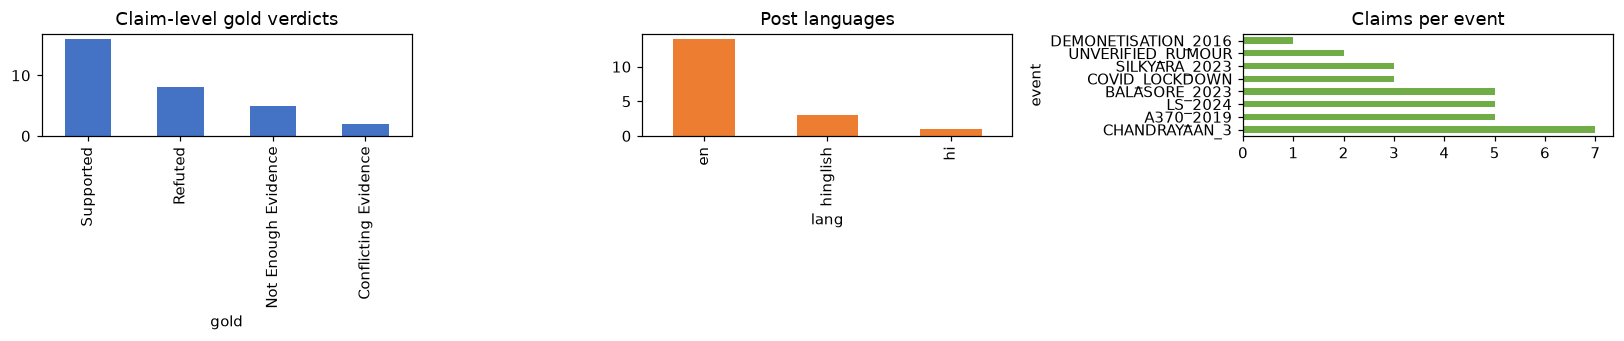

{'Supported': 16, 'Refuted': 8, 'Not Enough Evidence': 5, 'Conflicting Evidence': 2}
{'Supported': 8, 'Refuted': 5, 'Not Enough Evidence': 3, 'Conflicting Evidence': 2}


,cid,pid,event,text,gold,post_date,temporal_gold
0,P01_C1,P01,A370_2019,PM Modi govt revoked Article 370 on 5 August 2019.,Supported,2023-08-20,False
1,P01_C2,P01,A370_2019,Jammu and Kashmir was bifurcated into two Union Territories.,Supported,2023-08-20,False
2,P01_C3,P01,A370_2019,Pakistan raised the matter at the UN Security Council.,Supported,2023-08-20,False
3,P02_C1,P02,A370_2019,Article 370 was revoked in 2020.,Refuted,2020-05-01,False
4,P02_C2,P02,A370_2019,J&K has been made a single Union Territory.,Refuted,2020-05-01,False
5,P03_C1,P03,CHANDRAYAAN_3,Chandrayaan-3's Vikram lander soft-landed near the lunar south pole on 23 August 2023.,Supported,2023-08-23,False


In [4]:
# ============================================================================
# 2.3 Dataset statistics
# ============================================================================
claim_df = pd.DataFrame([{k: c[k] for k in ("cid","pid","event","text","gold","post_date","temporal_gold")}
                         for c in GOLD_CLAIMS])
post_df  = pd.DataFrame([{k: p[k] for k in ("id","lang","event","post_date","post_gold","temporal_gold")} for p in POSTS])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
claim_df["gold"].value_counts().plot.bar(ax=axes[0], color="#4472c4", title="Claim-level gold verdicts")
post_df["lang"].value_counts().plot.bar(ax=axes[1], color="#ed7d31", title="Post languages")
claim_df["event"].value_counts().plot.barh(ax=axes[2], color="#70ad47", title="Claims per event")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "demo_dataset_stats.png")); plt.show()

print(claim_df["gold"].value_counts().to_dict())
print(post_df["post_gold"].value_counts().to_dict())
claim_df.head(6)

## 3. NLP Layer: Normalization, Language Detection, Claim Extraction, Temporal & Entity Analysis

The NLP layer converts a raw post into **atomic claims** with language, entities and dates:

- **Normalization** strips URLs, hashtags, emojis and lead-ins ("Breaking:", "WhatsApp pe viral:").
- **Language detection** distinguishes English, Hindi (Devanagari) and Hinglish (code-mixed) via script ratio + cue-word lexicon.
- **Claim extraction** splits posts into atomic factual statements. It drops questions, imperatives ("forward this", "rush to the bank"), very short fragments and pure-opinion fragments, and splits conjunctive sentences. It is evaluated against the gold atomic claims with token-containment matching.
- **Temporal extraction** captures years and dates; **entity linking** uses a gazetteer of people, organizations, places and events.

In [5]:
# ============================================================================
# 3.1 Normalization and language detection
# ============================================================================
URL_RE   = re.compile(r"https?://\S+|www\.\S+")
TAG_RE   = re.compile(r"#\w+")
EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u27BF\uFE0F]")
LEAD_RE  = re.compile(r"^(breaking|whatsapp pe viral|forwarded message)\s*:\s*", re.I)

def normalize(text):
    text = URL_RE.sub(" ", text)
    text = TAG_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = LEAD_RE.sub("", text.strip())
    return re.sub(r"\s+", " ", text).strip()

DEV_RE = re.compile(r"[\u0900-\u097F]")
HINGLISH_CUES = {"pe","ka","ki","ke","nahi","hai","tha","bhai","ji","ne","li","diya","chunav","kya","mat","se","aur","me"}

def detect_language(text):
    alpha = [c for c in text if c.isalpha()]
    if alpha and sum(bool(DEV_RE.match(c)) for c in alpha) / len(alpha) > 0.30:
        return "hi"
    toks = set(re.findall(r"\w+", text.lower()))
    if len(toks & HINGLISH_CUES) >= 2:
        return "hinglish"
    return "en"

for p in POSTS:
    pred_lang = detect_language(p["text"])
    p["lang_pred"] = pred_lang
lang_acc = np.mean([p["lang"] == p["lang_pred"] for p in POSTS])
print(f"Language detection accuracy on corpus: {lang_acc:.2%}")
pd.DataFrame([(p["id"], p["lang"], p["lang_pred"]) for p in POSTS], columns=["post","gold","predicted"]).head(6)

Language detection accuracy on corpus: 100.00%


,post,gold,predicted
0,P01,en,en
1,P02,en,en
2,P03,en,en
3,P04,hinglish,hinglish
4,P05,en,en
5,P06,en,en


In [6]:
# ============================================================================
# 3.2 Rule-based claim extraction + evaluation vs gold atomic claims
# ============================================================================
class ClaimExtractor:
    SENT = re.compile(r"[.!?\u0964]+")
    IMPERATIVE_CUES = ["forward", "rush to", "save kar", "mat karna", "mat karo",
                       "please share", "share this", "chai peene", "aa jao"]
    OPINION_CUES = ["kya scene", "historic day", "terrible news", "very costly",
                    "breaking news", "must read", "shocking", "sad news"]

    def extract(self, post_text):
        claims = []
        for raw in self.SENT.split(post_text):
            s = normalize(raw)
            if len(s.split()) <= 3:            # too short to verify
                continue
            if "?" in s:                       # question, not a factual claim
                continue
            low = s.lower()
            if any(c in low for c in self.IMPERATIVE_CUES):
                continue
            if any(c in low for c in self.OPINION_CUES) and len(s.split()) <= 6:
                continue
            parts = re.split(r"\s+(?:and|aur)\s+", s)
            if len(parts) == 2 and all(len(p.split()) >= 4 for p in parts):
                claims.extend(p.strip() for p in parts)   # conjunctive split
            else:
                claims.append(s)
        return claims

def _tokset(s):
    return set(re.findall(r"\w+", s.lower()))

def extraction_eval(posts, extractor, threshold=0.6):
    # Precision / recall / F1 of predicted claims vs gold atomic claims.
    # A predicted claim matches a gold claim if it contains >=threshold of the gold's tokens.
    matched_preds, matched_golds, n_preds, n_golds = 0, 0, 0, 0
    for p in posts:
        preds = extractor.extract(p["text"])
        golds = [c["text"] for c in p["claims"]]
        n_preds += len(preds); n_golds += len(golds)
        for g in golds:
            gt = _tokset(g)
            if any(len(_tokset(pr) & gt) / max(1, len(gt)) >= threshold for pr in preds):
                matched_golds += 1
        for pr in preds:
            pr_matched = any(len(_tokset(pr) & _tokset(g)) / max(1, len(_tokset(g))) >= threshold
                             for g in golds)
            if pr_matched: matched_preds += 1
    P = matched_preds / n_preds if n_preds else 0.0
    R = matched_golds / n_golds if n_golds else 0.0
    F1 = 2*P*R/(P+R) if P+R else 0.0
    return dict(precision=P, recall=R, f1=F1, n_pred=n_preds, n_gold=n_golds)

claim_extractor = ClaimExtractor()
EXTRACTION_METRICS = extraction_eval(POSTS, claim_extractor)
print("Claim extraction metrics:", json.dumps(EXTRACTION_METRICS, indent=2))
example = claim_extractor.extract(POSTS[3]["text"])
print("\nExample (P04 Hinglish post) -> extracted claims:")
for c in example: print(" -", c)

Claim extraction metrics: {
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "n_pred": 31,
  "n_gold": 31
}

Example (P04 Hinglish post) -> extracted claims:
 - Chandrayaan-3 ne Moon pe landing nahi ki, ISRO ne mission fail maan liya hai
 - Aur lander ka naam Pragyan tha


In [7]:
# ============================================================================
# 3.3 Temporal information extraction
# ============================================================================
YEAR_RE = re.compile(r"\b(?:19|20)\d{2}\b")
MONTHS = {m.lower(): i+1 for i, m in enumerate(
    ["January","February","March","April","May","June","July","August","September","October","November","December"])}
DATE_RE = re.compile(r"\b(\d{1,2})\s+(" + "|".join(MONTHS) + r")\s+((?:19|20)\d{2})\b", re.I)
CUE_RE = re.compile(r"\b(tonight|today|now|abhi|yesterday|tomorrow|next month|this month|this week)\b", re.I)

def extract_dates(text):
    dates = []
    for d, m, y in DATE_RE.findall(text):
        dates.append(date(int(y), MONTHS[m.lower()], int(d)))
    dates.extend(date(int(y), 1, 1) for y in set(YEAR_RE.findall(text)))
    return sorted(set(dates))

for c in GOLD_CLAIMS:
    c["claim_dates"] = extract_dates(c["text"])
    c["has_temporal_cue"] = bool(CUE_RE.search(c["text"]))
print("Example dates extracted:", [str(d) for d in GOLD_CLAIMS[1]["claim_dates"]], "| cue:", GOLD_CLAIMS[5]["has_temporal_cue"])

Example dates extracted: [] | cue: False


In [8]:
# ============================================================================
# 3.4 Gazetteer-based entity recognition and linking
# ============================================================================
ENTITY_ALIASES = {
 "Narendra Modi": ["narendra modi", "pm modi", "modi ji", "modi"],
 "Amit Shah": ["amit shah"],
 "ISRO": ["isro"], "Vikram (lander)": ["vikram"], "Pragyan (rover)": ["pragyan"],
 "Chandrayaan-3": ["chandrayaan-3", "chandrayaan 3"],
 "Article 370": ["article 370"], "Jammu & Kashmir": ["jammu and kashmir", "jammu & kashmir", "j&k", "kashmir"],
 "Ladakh": ["ladakh"], "Pakistan": ["pakistan"],
 "UN Security Council": ["un security council", "united nations security council"],
 "BJP": ["bjp"], "Indian National Congress": ["congress"],
 "Lok Sabha": ["lok sabha"], "Election Commission of India": ["election commission", "eci"],
 "RBI": ["rbi"], "COVID-19": ["covid-19", "coronavirus"], "Kerala": ["kerala"],
 "Silkyara tunnel": ["silkyara tunnel", "silkyara"], "Uttarakhand": ["uttarakhand"],
 "Coromandel Express": ["coromandel express"], "Balasore": ["balasore"], "Odisha": ["odisha"],
 "CBI": ["cbi"], "UPI": ["upi"], "NPCI": ["npci"],
}
_ALIASES_SORTED = sorted(((a, canon) for canon, al in ENTITY_ALIASES.items() for a in al),
                          key=lambda x: -len(x[0]))

def extract_entities(text):
    low = " " + text.lower() + " "
    found, spans = [], []
    for alias, canon in _ALIASES_SORTED:
        start = 0
        while True:
            i = low.find(" " + alias + " ", start)
            if i < 0: break
            s, e = i, i + len(alias) + 1
            if any(not (e <= a or s >= b) for a, b in spans):
                start = e; continue
            spans.append((s, e)); found.append(canon); start = e
    return sorted(set(found))

for c in GOLD_CLAIMS:
    c["entities"] = extract_entities(c["text"])
print("Entities in P01_C1:", GOLD_CLAIMS[0]["entities"])
print("Entities in P10_C1:", GOLD_CLAIMS[9]["entities"])

Entities in P01_C1: ['Article 370', 'Narendra Modi']
Entities in P10_C1: ['Chandrayaan-3', 'ISRO']


## 4. Evidence Retrieval: BM25 + Dense + Hybrid (RRF)

Following the synopsis, retrieval combines **lexical BM25** with **dense semantic retrieval**, fused by **Reciprocal Rank Fusion**. In full mode the dense encoder is a multilingual MiniLM sentence-transformer (robust for Hindi/Hinglish); in light mode it is a char-ngram + word TF-IDF hybrid, which already handles code-mixed text surprisingly well but is weak cross-lingually (a limitation we measure explicitly).

Retrieval quality is reported as **Recall@5** and **Precision@5** against gold evidence links - this also feeds the ablation study (BM25-only vs dense-only vs hybrid).

In [9]:
# ============================================================================
# 4.1 BM25 lexical retriever (pure python implementation)
# ============================================================================
STOP = {"the","a","an","is","was","are","were","be","been","in","on","of","for","to","and","or","at","by",
        "with","from","that","this","it","its","as","has","have","had","will","would","into","about",
        "after","over","their","his","her","he","she","they","we","you","i","am","do","does","did","so",
        "if","then","than","there","here","what","which","who","whom","when","where","why","how","all",
        "any","both","each","few","more","most","other","some","such","but","up","out","said","saying",
        "ka","ki","ke","pe","me","se","ko","hai","hain","tha","thi","vo","ye","bhi","toh"}

def bm25_tokens(s):
    return [t for t in re.findall(r"\w+", s.lower()) if t not in STOP and len(t) > 1]

class BM25Retriever:
    # BM25 with an inverted index so it scales to corpora of 10k+ documents.
    def __init__(self, texts, ids, k1=1.5, b=0.75):
        self.k1, self.b, self.ids = k1, b, list(ids)
        self.docs = [bm25_tokens(t) for t in texts]
        self.N = len(self.docs)
        self.dl = [len(d) for d in self.docs]
        self.avgdl = sum(self.dl) / max(1, self.N)
        df = Counter()
        for d in self.docs:
            df.update(set(d))
        self.idf = {t: math.log(1 + (self.N - n + 0.5) / (n + 0.5)) for t, n in df.items()}
        self.postings = defaultdict(list)          # term -> [(doc_index, term_freq)]
        for i, d in enumerate(self.docs):
            for t, f in Counter(d).items():
                self.postings[t].append((i, f))

    def search(self, query, k=5):
        q = bm25_tokens(query)
        scores = defaultdict(float)
        for t in q:
            idf = self.idf.get(t)
            if idf is None:
                continue
            for i, f in self.postings.get(t, ()):
                dl = self.dl[i]
                scores[i] += idf * f * (self.k1 + 1) / (f + self.k1 * (1 - self.b + self.b * dl / self.avgdl))
        # nlargest beats a full sort when a common term matches many documents
        return heapq.nlargest(k, ((s, self.ids[i]) for i, s in scores.items()))

In [10]:
# ============================================================================
# 4.2 Dense sentence encoder (multilingual MiniLM in full mode, TF-IDF fallback)
# ============================================================================
class TextEncoder:
    def __init__(self, model_name="paraphrase-multilingual-MiniLM-L12-v2"):
        self.kind = "tfidf"
        if TRANSFORMERS_OK:
            try:
                from sentence_transformers import SentenceTransformer
                self.st = SentenceTransformer(model_name, device=DEVICE)
                self.model_name = model_name
                self.kind = "minilm"
                print(f"Dense encoder: multilingual MiniLM on {DEVICE} (full mode)")
            except Exception as e:
                # Do NOT silently fall back in full mode. TRANSFORMERS_OK only records
                # that the imports succeeded; a download / OOM / network failure here
                # would otherwise produce TF-IDF vectors that get written to caches and
                # reported as transformer results. Light mode is the explicit opt-in.
                raise RuntimeError(
                    f"Dense encoder {model_name} failed to load in full mode: {e}. "
                    "Set TRUTHLENS_LIGHT=1 (or USE_TRANSFORMERS=False) to run the "
                    "TF-IDF fallback deliberately; it will be tagged 'light' in every "
                    "cache key and must not be reported as a full-mode result.") from e
        if self.kind == "tfidf":
            from sklearn.feature_extraction.text import TfidfVectorizer
            self.word_vec = TfidfVectorizer(analyzer="word", token_pattern=r"\w+",
                                            ngram_range=(1, 2), min_df=1)
            self.char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)
            self.fitted = False
            print("Dense encoder: word+char TF-IDF (light mode)")

    def fit(self, texts):
        if self.kind == "tfidf":
            self.word_vec.fit(texts); self.char_vec.fit(texts); self.fitted = True
        return self

    def encode_corpus(self, texts, batch_size=256):
        # Corpus-scale encoding: batched, with a progress bar once the corpus is
        # big enough that the user would otherwise think the cell had hung.
        # Kept separate from encode() so single-query latency is unaffected.
        #
        # Memory hygiene matters here. Later cells (reranking) hold the NLI model
        # and a cross-encoder on the accelerator at the same time, and encoding a
        # 2e5-document corpus alongside them killed the kernel outright with no
        # Python traceback. So: release cached accelerator blocks first, shrink the
        # batch for large corpora, and encode in chunks so peak allocation stays
        # bounded regardless of corpus size.
        texts = list(texts)
        if self.kind != "minilm":
            return self.encode(texts)
        _free_accelerator()
        n = len(texts)
        if n > 50000:
            batch_size = min(batch_size, 64)
        elif n > 10000:
            batch_size = min(batch_size, 128)
        CHUNK = 20000
        if n <= CHUNK:
            return self.st.encode(texts, normalize_embeddings=True,
                                  batch_size=batch_size,
                                  show_progress_bar=n > 5000,
                                  convert_to_numpy=True)
        out = []
        for i in range(0, n, CHUNK):
            out.append(self.st.encode(texts[i:i + CHUNK], normalize_embeddings=True,
                                      batch_size=batch_size, show_progress_bar=False,
                                      convert_to_numpy=True).astype(np.float32))
            _free_accelerator()
            print(f"    encoded {min(i + CHUNK, n)}/{n}", flush=True)
        return np.vstack(out)

    def encode(self, texts):
        if self.kind == "minilm":
            return self.st.encode(list(texts), normalize_embeddings=True)
        if not self.fitted: raise RuntimeError("call fit() first")
        import scipy.sparse as sp
        return np.hstack([self.word_vec.transform(texts).toarray(),
                           self.char_vec.transform(texts).toarray()]).astype(np.float32)

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb + 1e-9))

In [11]:
# ============================================================================
# 4.3 Hybrid retriever (BM25 + dense + Reciprocal Rank Fusion) and evaluation
# ============================================================================
class HybridRetriever:
    # Vectorised so the same class works at demo scale (30 docs) and at
    # full-corpus scale (2.5e5 sentences). Three things matter for scale:
    #   1. dense similarity is ONE matmul against an L2-normalised matrix,
    #      not a Python loop of cosine() calls;
    #   2. top-k uses argpartition (O(n)) rather than a full sort (O(n log n));
    #   3. RRF fusion runs over the union of the two candidate lists rather
    #      than over every document.
    # (3) is exact for the returned top-k as long as CAND is comfortably larger
    # than k: a document outside the dense top-CAND and outside the BM25 list
    # has RRF score <= 1/(rrf_k+CAND), below any candidate ranked near the top.
    CAND = 200

    def __init__(self, evidence_docs, encoder, rrf_k=60, fit_texts=None,
                 batch_size=256, cache_key=None):
        self.ids = [e["id"] for e in evidence_docs]
        self.id2idx = {e: i for i, e in enumerate(self.ids)}      # O(1), was ids.index()
        self.rrf_k = rrf_k
        self.texts = [e["text"] for e in evidence_docs]
        self.bm25 = BM25Retriever(self.texts, self.ids)
        self.encoder = encoder
        encoder.fit(self.texts + list(fit_texts or []))
        # Embedding cache: encoding a 2e5-sentence corpus costs minutes, and the
        # verdict cells rebuild the retriever after a kernel restart. The cache
        # is keyed by corpus identity AND encoder kind, so a different encoder
        # or a changed corpus can never silently reuse the wrong vectors.
        vecs = None
        emb_path = None
        if cache_key:
            # The key must bind to what was actually encoded. Document count alone is
            # not enough: a re-sampled distractor set or regenerated source data can
            # keep the same length while changing every vector, and the stale cache
            # would then be paired with new texts and silently corrupt retrieval.
            _h = hashlib.sha1()
            _h.update(getattr(encoder, "model_name", encoder.kind).encode())
            for _t in self.texts:
                _h.update(_t.encode("utf-8", "replace"))
                _h.update(b"\x00")
            sig = f"{cache_key}_{encoder.kind}_{len(self.texts)}_{_h.hexdigest()[:12]}"
            emb_path = os.path.join(CACHE_DIR, f"emb_{sig}.npy")
            if not FORCE_RERUN and os.path.exists(emb_path):
                vecs = np.load(emb_path)
                if vecs.shape[0] != len(self.texts):   # stale/corrupt -> recompute
                    vecs = None
                else:
                    print(f"  embeddings loaded from cache: {os.path.basename(emb_path)} {vecs.shape}")
        if vecs is None:
            t0 = time.time()
            vecs = np.asarray(encoder.encode_corpus(self.texts, batch_size=batch_size),
                              dtype=np.float32)
            print(f"  encoded {len(self.texts)} docs in {time.time()-t0:.0f}s")
            if emb_path:
                np.save(emb_path, vecs)
        # pre-normalise once so cosine == dot product
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        self.doc_vecs = vecs / np.maximum(norms, 1e-9)

    def _dense_topn(self, qv, n):
        sims = self.doc_vecs @ qv                      # (n_docs,) single matmul
        n = min(n, sims.shape[0])
        part = np.argpartition(-sims, n - 1)[:n]       # unordered top-n
        order = part[np.argsort(-sims[part])]          # order just those n
        return order, sims

    def search(self, query, k=5, mode="hybrid"):
        qv = np.asarray(self.encoder.encode([query])[0], dtype=np.float32)
        qv = qv / max(float(np.linalg.norm(qv)), 1e-9)
        cand_n = max(self.CAND, k)
        dense_order, sims = self._dense_topn(qv, cand_n)

        if mode == "dense":
            ranked = [(int(i), float(sims[i])) for i in dense_order[:k]]
        elif mode == "bm25":
            ranked = [(self.id2idx[i_d], float(sc))
                      for sc, i_d in self.bm25.search(query, k=k)]
        else:
            bm25_res = self.bm25.search(query, k=max(10, k))
            bm25_rank = {i_d: r + 1 for r, (sc, i_d) in enumerate(bm25_res)}
            dense_rank = {int(i): r + 1 for r, i in enumerate(dense_order)}
            cand = set(dense_rank) | {self.id2idx[i_d] for i_d in bm25_rank}
            fused = []
            for idx in cand:
                s = 0.0
                eid = self.ids[idx]
                if eid in bm25_rank:  s += 1.0 / (self.rrf_k + bm25_rank[eid])
                if idx in dense_rank: s += 1.0 / (self.rrf_k + dense_rank[idx])
                fused.append((idx, s))
            ranked = sorted(fused, key=lambda x: -x[1])[:k]

        return [dict(id=self.ids[idx], score=float(s), sim=float(sims[idx]),
                     text=self.texts[idx]) for idx, s in ranked]

class CrossEncoderReranker:
    # Second-stage ranker. The first stage (BM25 / dense / RRF) is recall-oriented
    # and cheap; a cross-encoder reads the (claim, evidence) pair jointly and is far
    # more accurate but too slow to run over a whole corpus. Standard fix: retrieve a
    # deep pool with the cheap stage, rerank the pool, keep the top k.
    # Measured on this project: Recall@5 +0.047 on AVeriTeC and +0.092 on FEVER's
    # 207k-sentence corpus, at ~155 s for both datasets on MPS.
    def __init__(self, model_name="cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=384):
        self.kind = "none"
        self.model_name = model_name
        if TRANSFORMERS_OK:
            try:
                from sentence_transformers import CrossEncoder
                self.ce = CrossEncoder(model_name, device=DEVICE, max_length=max_length)
                self.kind = "cross-encoder"
                print(f"Reranker: {model_name} on {DEVICE}")
            except Exception as e:
                print("Reranker unavailable -> first-stage order kept:", e)
        else:
            print("Reranker: disabled (light mode) -> first-stage order kept")

    def rerank(self, query, docs, k, batch_size=128):
        # docs: list of dicts with a "text" field, in first-stage order.
        if self.kind != "cross-encoder" or not docs:
            return docs[:k]
        scores = self.ce.predict([(query, d["text"]) for d in docs],
                                 batch_size=batch_size, show_progress_bar=False)
        order = np.argsort(-np.asarray(scores))
        out = []
        for i in order[:k]:
            d = dict(docs[int(i)])
            d["rerank_score"] = float(scores[int(i)])
            out.append(d)
        return out

retriever = HybridRetriever(EVIDENCE_DOCS, TextEncoder(), fit_texts=[c["text"] for c in GOLD_CLAIMS])

def retrieval_eval(mode, K=5):
    recs, precs = [], []
    for c in GOLD_CLAIMS:
        if not c["evidence"]: continue
        top = [r["id"] for r in retriever.search(c["text"], k=K, mode=mode)]
        gold = set(c["evidence"])
        hits = len(set(top) & gold)
        recs.append(hits / len(gold))
        precs.append(hits / K)              # Precision@K: denominator is K, not len(top)
    return dict(mode=mode, recall_at_5=round(np.mean(recs), 3), precision_at_5=round(np.mean(precs), 3))

RETRIEVAL_EVAL = pd.DataFrame([retrieval_eval(m) for m in ["bm25", "dense", "hybrid"]])
print("Retrieval evaluation (claims with gold evidence only):")
display(RETRIEVAL_EVAL)
RETRIEVAL_EVAL.to_csv(os.path.join(OUT_DIR, "demo_retrieval_eval.csv"), index=False)

top = retriever.search("BJP won 300 seats in 2024 elections", k=3)
print("\nDemo retrieval for 'BJP won 300 seats in 2024 elections':")
for r in top: print(f"  {r['id']} (score {r['score']:.4f}) - {r['text'][:80]}...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense encoder: multilingual MiniLM on mps (full mode)
  encoded 30 docs in 0s


Retrieval evaluation (claims with gold evidence only):


,mode,recall_at_5,precision_at_5
0,bm25,0.907,0.267
1,dense,1.000,0.289
2,hybrid,0.981,0.281



Demo retrieval for 'BJP won 300 seats in 2024 elections':
  E15 (score 0.0328) - Fact check: Viral claims that the BJP won 300 seats in the 2024 Lok Sabha electi...
  E13 (score 0.0323) - The Election Commission of India declared the results of the 2024 Lok Sabha elec...
  E26 (score 0.0313) - Australia won the 2023 Cricket World Cup, defeating India by 6 wickets in the fi...


## 5. Evidence Analysis: NLI Judging, Conflict-Aware Verdict Aggregation, Temporal Mismatch

For every (claim, evidence) pair the system asks an **NLI judge** whether the evidence *entails*, *contradicts* or is *neutral* toward the claim.

- **Full mode:** a multilingual mDeBERTa NLI model trained on XNLI (handles English, Hindi, Hinglish reasonably).
- **Light mode (fallback):** a transparent heuristic judge built on **lexical containment** (the fraction of the claim's stemmed content words that appear in the evidence) combined with **negation cues**, **numeric consistency**, a **causal-hedge rule** (causal claims are not supported by hedged, under-investigation evidence) and a **fact-check pattern** (fact-check articles embed the claim they debunk; a contradiction fires only when the embedded claim's numbers and content match ours - this is exactly where similarity-only systems get fooled by debunking articles).

Each claim is verified against the **top-8** retrieved evidence documents. **Verdict aggregation** produces the four-way label: if evidence both supports and refutes a claim -> `Conflicting Evidence`; only refutations -> `Refuted`; only support -> `Supported`; otherwise -> `Not Enough Evidence`. Confidence is the mean NLI probability of the winning side.

**Temporal mismatch detection** flags posts that present old events as current ("Breaking ... tonight" + evidence much older than the post) - the recycled-content case from the synopsis.

In [12]:
# ============================================================================
# 5.1 NLI judge
# ============================================================================
def stem(w):
    for suf, n in (("ing", 3), ("ed", 2), ("es", 2)):
        if w.endswith(suf) and len(w) > n + 2: return w[:-n]
    if w.endswith("s") and len(w) > 3 and not w.endswith("ss"): return w[:-1]
    return w

def words_of(text, drop_stop=True):
    toks = re.findall(r"\w+", text.lower())
    if drop_stop: toks = [t for t in toks if t not in STOP]
    return [stem(t) for t in toks]

NEG_STEMS = {"not", "no", "never", "deni", "fail", "fals", "nahi", "onli", "without", "cannot"}
def has_neg(text):
    return any(stem(t) in NEG_STEMS for t in re.findall(r"\w+", text.lower()))

NUMWORD = {"one":"1","single":"1","two":"2","three":"3","four":"4","five":"5",
           "six":"6","seven":"7","eight":"8","nine":"9","ten":"10","eleven":"11","twelve":"12"}
def numbers_in(text):
    nums = set(re.findall(r"\d+", text))
    low = " " + text.lower() + " "
    for w, d in NUMWORD.items():
        if f" {w} " in low: nums.add(d)
    return nums

FALSE_PATTERN = re.compile(
    r"(claim|claims|claiming|posts|post|reports|message|messages)\s+(?:that\s+)?(.+?)\s+(?:is|are)\s+(false|fake|incorrect|untrue|misleading)",
    re.IGNORECASE | re.DOTALL)
HEDGES = ["under investigation", "remains unclear", "not yet clear", "alleged",
          "may have", "could have", "unconfirmed", "no official", "preliminary",
          "reports pointed", "reports suggest", "reportedly", "probing"]
CAUSAL_RE = re.compile(r"\b(caused? by|due to|responsible for)\b", re.I)

class NLIJudge:
    # Transformer NLI (full mode) or transparent heuristic judge (light mode).
    # Model is chosen by NLI_TIER, which follows the available accelerator:
    #   strong (default on CUDA/MPS) DeBERTa-v3-large-mnli-fever-anli-ling-wanli
    #       -- MNLI+FEVER+ANLI trained, i.e. trained on this very task.
    #   multilingual  mDeBERTa-v3-base-xnli  -- for Hindi / code-mixed evidence.
    #   small (fallback on bare CPU)  nli-MiniLM2-L6-H768.
    # Pass model_name explicitly to override (Part 12 uses the multilingual one
    # for Hindi). Measured throughputs are in the configuration cell.
    def __init__(self, encoder, model_name=None):
        self.encoder = encoder
        self.kind = "heuristic"
        if model_name is None:
            model_name = NLI_MODEL_NAME
        self.model_name = model_name
        if TRANSFORMERS_OK:
            try:
                from transformers import AutoTokenizer, AutoModelForSequenceClassification
                import torch
                self.tok = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
                self.model.eval().to(DEVICE)
                if TORCH_DTYPE == "float16":
                    self.model = self.model.to(torch.float16)
                self.device = DEVICE
                self.kind = "transformer"
                print(f"NLI judge: {model_name} on {DEVICE} ({TORCH_DTYPE}, tier={NLI_TIER})")
            except Exception as e:
                # Same reasoning as TextEncoder: a heuristic judge silently standing in
                # for a transformer would corrupt every verdict number downstream.
                raise RuntimeError(
                    f"NLI model {model_name} failed to load in full mode: {e}. "
                    "Set TRUTHLENS_LIGHT=1 to use the heuristic judge deliberately."
                    ) from e
        else:
            print("NLI judge: transparent heuristic (light mode)")

    def _map_probs(self, probs_row):
        mapped = defaultdict(float)
        for i, p in enumerate(probs_row):
            lab = self.model.config.id2label.get(i, "").lower()
            key = "entailment" if "entail" in lab else ("contradiction" if "contradict" in lab else "neutral")
            mapped[key] = max(mapped[key], float(p))
        return max(mapped.items(), key=lambda kv: kv[1])

    def _transformer(self, premise, hypothesis):
        import torch
        inp = self.tok(premise, hypothesis, truncation=True, max_length=256,
                       return_tensors="pt").to(self.device)
        with torch.no_grad():
            probs = torch.softmax(self.model(**inp).logits.float(), dim=-1)[0].tolist()
        label, prob = self._map_probs(probs)
        return label, round(prob, 4)

    def judge_many(self, claim, evidence_texts, batch_size=32, max_length=192):
        # Batched NLI: claim (hypothesis) vs each evidence text (premise).
        # Returns list of (label, prob) aligned with evidence_texts.
        if self.kind != "transformer":
            return [self._heuristic(claim, t, False) for t in evidence_texts]
        import torch
        out = []
        for i in range(0, len(evidence_texts), batch_size):
            chunk = evidence_texts[i:i + batch_size]
            inp = self.tok(chunk, [claim] * len(chunk), truncation=True,
                           max_length=max_length, padding=True,
                           return_tensors="pt").to(self.device)
            with torch.no_grad():
                probs = torch.softmax(self.model(**inp).logits.float(), dim=-1)
            for row in probs:
                label, prob = self._map_probs(row.tolist())
                out.append((label, round(prob, 4)))
        return out

    def _sim(self, a, b):
        v = self.encoder.encode([a, b])
        return cosine(v[0], v[1])

    def _heuristic(self, claim, evidence, is_factcheck):
        # Lexical containment: fraction of the claim's DISTINCT stemmed content
        # words that also appear in the evidence (claim = hypothesis).
        c_set, e_set = set(words_of(claim)), set(words_of(evidence))
        containment = len(c_set & e_set) / len(c_set) if c_set else 0.0
        c_neg, e_neg = has_neg(claim), has_neg(evidence)
        c_nums, e_nums = numbers_in(claim), numbers_in(evidence)
        num_missing = bool(c_nums - e_nums)      # any claim number absent from evidence
        if is_factcheck:
            m = FALSE_PATTERN.search(evidence)
            if m:
                embedded = m.group(2)
                emb_contain = len(c_set & set(words_of(embedded))) / max(1, len(c_set))
                if numbers_in(embedded) == c_nums and emb_contain >= 0.35:
                    return "contradiction", 0.85       # fact-check debunks THIS claim
            return "neutral", round(1 - containment, 3)   # fact-check about another claim
        if CAUSAL_RE.search(claim) and any(h in evidence.lower() for h in HEDGES):
            return "neutral", 0.6                      # hedged causal evidence
        if (c_neg != e_neg or num_missing) and containment >= 0.40:
            return "contradiction", round(min(0.95, 0.5 + 0.45 * (1 - containment)), 3)
        if containment >= 0.60:
            return "entailment", round(min(0.95, 0.5 + 0.5 * containment), 3)
        return "neutral", round(max(0.0, 1 - containment), 3)

    def judge(self, claim, evidence_id):
        ev = EVIDENCE_BY_ID[evidence_id]
        if self.kind == "transformer":
            return self._transformer(ev["text"], claim)
        return self._heuristic(claim, ev["text"], ev["stype"] == "factcheck")

judge = NLIJudge(retriever.encoder)
print("\nSanity checks:")
for claim, ev in [("Chandrayaan-3 landed near the lunar south pole on 23 August 2023.", "E06"),
                  ("Chandrayaan-3 cost Rs 1000 crore.", "E08"),
                  ("The Balasore train accident was caused by a signal failure.", "E19"),
                  ("Article 370 was revoked in 2020.", "E05")]:
    print(f"  [{judge.judge(claim, ev)[0]:13s}] {claim[:55]:57s} vs {ev}")

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

NLI judge: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli on mps (float16, tier=strong)

Sanity checks:
  [entailment   ] Chandrayaan-3 landed near the lunar south pole on 23 Au   vs E06
  [contradiction] Chandrayaan-3 cost Rs 1000 crore.                         vs E08


  [neutral      ] The Balasore train accident was caused by a signal fail   vs E19
  [contradiction] Article 370 was revoked in 2020.                          vs E05


In [13]:
# ============================================================================
# 5.2 Verdict aggregation, temporal mismatch detection, claim-level pipeline
# ============================================================================
SUPPORTED, REFUTED, NEI, CONFLICTING = "Supported", "Refuted", "Not Enough Evidence", "Conflicting Evidence"

def aggregate_verdict(judgments, use_conflict=True,
                      conflict_min_prob=0.0, conflict_max_margin=1.0):
    # judgments: list of (label, prob, evidence_id)
    #
    # conflict_min_prob / conflict_max_margin gate the Conflicting verdict. The
    # defaults (0.0, 1.0) reproduce the original rule exactly: ANY co-occurrence of
    # an entailment and a contradiction among the top-k is called Conflicting. That
    # rule fires very easily with k=5, and on AVeriTeC (where Conflicting is only
    # 7.6% of claims) it costs more than it gains. The gated version additionally
    # requires that BOTH sides carry real mass (>= conflict_min_prob) and that
    # neither side dominates (|mean_ent - mean_con| <= conflict_max_margin);
    # otherwise it falls back to the stronger side. Thresholds are selected on the
    # TRAIN split in 11.4b and only then applied to dev.
    ent = [j for j in judgments if j[0] == "entailment"]
    con = [j for j in judgments if j[0] == "contradiction"]
    if ent and con:
        me = float(np.mean([j[1] for j in ent]))
        mc = float(np.mean([j[1] for j in con]))
        conf = round((me + mc) / 2, 3)
        if use_conflict and min(me, mc) >= conflict_min_prob and abs(me - mc) <= conflict_max_margin:
            return CONFLICTING, conf
        return (REFUTED if mc > me else SUPPORTED), conf
    if con: return REFUTED, round(float(np.mean([j[1] for j in con])), 3)
    if ent: return SUPPORTED, round(float(np.mean([j[1] for j in ent])), 3)
    return NEI, round(float(np.mean([j[1] for j in judgments])) if judgments else 0.5, 3)

TEMPORAL_CUES = ["breaking", "tonight", "starting tonight", "just in", "just now", "emergency", "latest"]

def detect_temporal_mismatch(claim, post_text, post_date, relevant_evidence_ids):
    # Uses only evidence the judge found RELEVANT (entailing/refuting) and flags
    # posts that present an event as current when all relevant evidence is >1y old.
    cue = any(c in (claim + " " + post_text).lower() for c in TEMPORAL_CUES)
    if cue and relevant_evidence_ids:
        ev_dates = [EVIDENCE_BY_ID[e]["sdate"] for e in relevant_evidence_ids]
        newest = max(date.fromisoformat(d) for d in ev_dates)
        gap = (date.fromisoformat(post_date) - newest).days
        if gap > 365:
            return dict(flag=True, reason=f"post presents the event as current but relevant evidence is {gap} days older (recycled content)")
    return dict(flag=False, reason="")

def verify_claim(claim_text, post_text="", post_date="2024-06-01", top_k=8,
                 retriever_mode="hybrid", use_conflict=True, use_temporal=True):
    retrieved = retriever.search(claim_text, k=top_k, mode=retriever_mode)
    judgments = [(*judge.judge(claim_text, r["id"]), r["id"]) for r in retrieved]
    verdict, confidence = aggregate_verdict(judgments, use_conflict=use_conflict)
    relevant = [j[2] for j in judgments if j[0] in ("entailment", "contradiction")]
    temporal = detect_temporal_mismatch(claim_text, post_text, post_date, relevant) if use_temporal \
               else dict(flag=False, reason="")
    supporting = [j[2] for j in judgments if j[0] == "entailment"]
    refuting  = [j[2] for j in judgments if j[0] == "contradiction"]
    return dict(claim=claim_text, verdict=verdict, confidence=confidence, temporal=temporal,
                supporting=supporting, refuting=refuting, retrieved=[r["id"] for r in retrieved])

# quick check on a conflicting-evidence claim
res = verify_claim(GOLD_CLAIMS[10]["text"], post_text=GOLD_CLAIMS[10]["post_text"], post_date=GOLD_CLAIMS[10]["post_date"])
print(json.dumps(res, indent=2, ensure_ascii=False))

{
  "claim": "PM Modi announced a complete nationwide lockdown starting tonight for 21 days.",
  "verdict": "Refuted",
  "confidence": 0.837,
  "temporal": {
    "flag": true,
    "reason": "post presents the event as current but relevant evidence is 656 days older (recycled content)"
  },
  "supporting": [],
  "refuting": [
    "E24",
    "E02",
    "E30",
    "E23"
  ],
  "retrieved": [
    "E11",
    "E14",
    "E29",
    "E24",
    "E20",
    "E02",
    "E30",
    "E23"
  ]
}


## 6. Evidence Graph

The evidence graph links **posts -> claims -> evidence -> sources** and **claims -> entities / events**, making every verdict traceable (the provenance requirement from the synopsis). We build the graph from gold claims with system-predicted verdicts, export it as JSON, and visualize one event subgraph.

Evidence graph: 105 nodes, 149 edges -> saved to evidence_graph.json


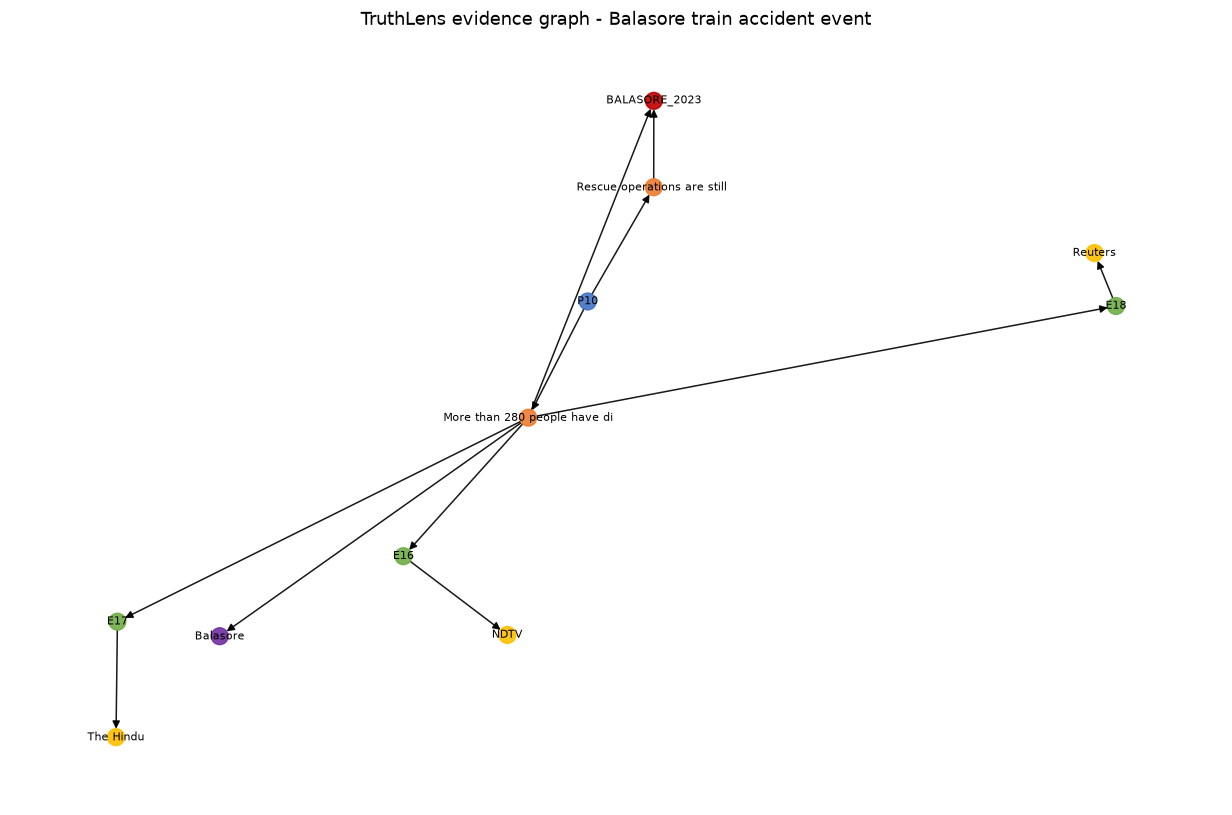

In [14]:
# ============================================================================
# 6.1 Build, export and visualize the evidence graph
# ============================================================================
import networkx as nx

def build_evidence_graph(claims, results_by_cid):
    G = nx.DiGraph()
    def node(nid, kind, **attrs):
        G.add_node(nid, kind=kind, **attrs)
    for p in POSTS:
        node(p["id"], "post", text=p["text"][:60], event=p["event"])
    for c in claims:
        cid = c["cid"]
        pred = results_by_cid.get(cid, {})
        node(cid, "claim", text=c["text"][:60], event=c["event"],
             gold=c["gold"], verdict=pred.get("verdict", ""),
             confidence=pred.get("confidence"))
        G.add_edge(c["pid"], cid, relation="has_claim")
        G.add_edge(cid, c["event"], relation="about")
        node(c["event"], "event")
        for ent in c.get("entities", []):
            node(ent, "entity"); G.add_edge(cid, ent, relation="mentions")
        for ev_id in c["evidence"]:
            e = EVIDENCE_BY_ID[ev_id]
            node(ev_id, "evidence", source=e["source"], sdate=e["sdate"])
            G.add_edge(cid, ev_id, relation="cites")
            node(e["source"], "source", stype=e["stype"])
            G.add_edge(ev_id, e["source"], relation="published_in")
    return G

# provisional full-pipeline verdicts for every gold claim (used across sections 6-8)
FULL_RESULTS = {c["cid"]: verify_claim(c["text"], post_text=c["post_text"], post_date=c["post_date"])
                for c in GOLD_CLAIMS}

graph = build_evidence_graph(GOLD_CLAIMS, FULL_RESULTS)
graph_json = dict(nodes=[dict(id=n, **d) for n, d in graph.nodes(data=True)],
                  edges=[dict(source=u, target=v, relation=d.get("relation")) for u, v, d in graph.edges(data=True)])
with open(os.path.join(OUT_DIR, "demo_evidence_graph.json"), "w", encoding="utf-8") as f:
    json.dump(graph_json, f, ensure_ascii=False, indent=2)
print(f"Evidence graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges -> saved to evidence_graph.json")

COLORS = dict(post="#4472c4", claim="#ed7d31", evidence="#70ad47", source="#ffc000", entity="#7030a0", event="#c00000")
sub = graph.subgraph([n for n, d in graph.nodes(data=True)
                      if d.get("event") == "BALASORE_2023" or d.get("kind") in ("source",) and False])
sub = graph.subgraph(nx.descendants(graph, "P10") | nx.ancestors(graph, "P10") | {"P10"})
pos = nx.spring_layout(sub, seed=42)
plt.figure(figsize=(11, 7))
nx.draw(sub, pos, with_labels=False, node_size=120,
        node_color=[COLORS[d["kind"]] for _, d in sub.nodes(data=True)], alpha=0.9)
labels = {n: (d.get("text", n)[:28] if d["kind"] == "claim" else n) for n, d in sub.nodes(data=True)}
nx.draw_networkx_labels(sub, pos, labels, font_size=7)
plt.title("TruthLens evidence graph - Balasore train accident event")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "demo_evidence_graph_balasore.png")); plt.show()

## 7. Narrative Layer: Clustering Claims into Event Narratives

Claims from all posts are embedded and clustered (KMeans, k chosen by silhouette). Clusters are **named by their top TF-IDF terms** and compared with gold event labels via **NMI / ARI** (unsupervised recovery of event-level structure) and **silhouette** (coherence). For each narrative we report the verdict distribution - showing how different framings of the same event differ in evidential support (the narrative-comparison contribution of the paper).

Narrative clustering metrics: {'k': 8, 'silhouette': 0.162, 'nmi': 0.813, 'ari': 0.68}


,cluster,size,top_terms,dominant_gold_event,verdict_distribution
0,0,2,union bifurcated territory,A370_2019,"{'Supported': 1, 'Refuted': 1}"
1,1,4,lockdown nationwide 2020,COVID_LOCKDOWN,"{'Refuted': 2, 'Supported': 2}"
2,2,7,क 3 chandrayaan,CHANDRAYAAN_3,"{'Conflicting Evidence': 3, 'Refuted': 3, 'Not Enough Evidence': 1}"
3,3,1,council security pakistan,A370_2019,{'Supported': 1}
4,4,4,article revoked 370,A370_2019,"{'Not Enough Evidence': 2, 'Refuted': 1, 'Supported': 1}"
5,5,5,seats won bjp,LS_2024,"{'Supported': 2, 'Refuted': 2, 'Not Enough Evidence': 1}"
6,6,4,accident balasore train,BALASORE_2023,"{'Conflicting Evidence': 2, 'Supported': 2}"
7,7,4,rescue days workers,SILKYARA_2023,"{'Refuted': 3, 'Supported': 1}"


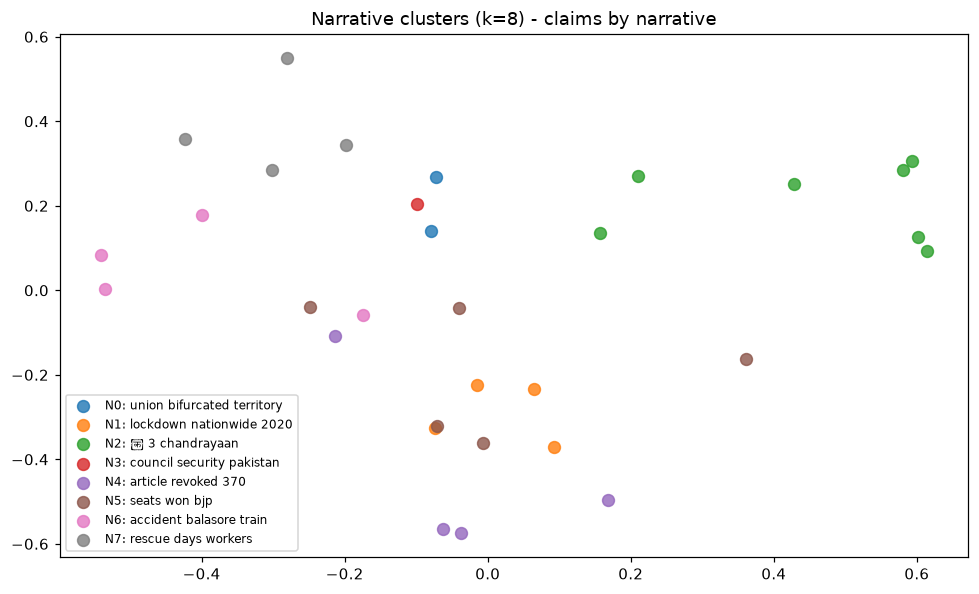

In [15]:
# ============================================================================
# 7.1 Narrative clustering + quality metrics + narrative comparison table
# ============================================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from sklearn.feature_extraction.text import TfidfVectorizer

claim_texts = [c["text"] for c in GOLD_CLAIMS]
claim_events = [c["event"] for c in GOLD_CLAIMS]
claim_vecs = retriever.encoder.encode(claim_texts)
# dimensionality reduction stabilizes clustering for sparse TF-IDF vectors
cluster_vecs = TruncatedSVD(n_components=min(20, len(claim_texts) - 1),
                            random_state=42).fit_transform(claim_vecs)

best_k, best_score, best_labels = None, -1, None
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_vecs)
    s = silhouette_score(cluster_vecs, km.labels_)
    if s > best_score: best_k, best_score, best_labels = k, s, km.labels_

nmi = normalized_mutual_info_score(claim_events, best_labels)
ari = adjusted_rand_score(claim_events, best_labels)
NARRATIVE_METRICS = dict(k=best_k, silhouette=round(best_score, 3), nmi=round(nmi, 3), ari=round(ari, 3))
print("Narrative clustering metrics:", NARRATIVE_METRICS)

name_vec = TfidfVectorizer(analyzer="word", token_pattern=r"\w+", stop_words=list(STOP))
name_mat = name_vec.fit_transform(claim_texts)
vocab = np.array(name_vec.get_feature_names_out())

rows = []
for cl in range(best_k):
    idx = [i for i, l in enumerate(best_labels) if l == cl]
    top_terms = " ".join(vocab[np.asarray(name_mat[idx].sum(axis=0)).ravel().argsort()[::-1][:3]])
    verdicts = Counter(FULL_RESULTS[GOLD_CLAIMS[i]["cid"]]["verdict"] for i in idx)
    gold_events = Counter(claim_events[i] for i in idx)
    rows.append(dict(cluster=cl, size=len(idx), top_terms=top_terms,
                     dominant_gold_event=gold_events.most_common(1)[0][0],
                     verdict_distribution=dict(verdicts)))
narrative_df = pd.DataFrame(rows)
display(narrative_df)
narrative_df.to_csv(os.path.join(OUT_DIR, "demo_narrative_summary.csv"), index=False)

pca = PCA(n_components=2, random_state=42).fit_transform(cluster_vecs)
plt.figure(figsize=(9, 5.5))
for cl in range(best_k):
    pts = pca[[i for i, l in enumerate(best_labels) if l == cl]]
    plt.scatter(pts[:, 0], pts[:, 1], s=60, alpha=0.8, label=f"N{cl}: " + rows[cl]["top_terms"])
plt.legend(fontsize=8); plt.title(f"Narrative clusters (k={best_k}) - claims by narrative")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "demo_narrative_clusters.png")); plt.show()

## 8. Demonstration-Scale Sanity Check: The Research Question (DEMO DATA - NOT RESEARCH RESULTS)

> **RQ:** *Can an evidence-aware, claim-level NLP pipeline with source comparison and event-level narrative analysis improve factual verification and explanation quality over conventional text classification or similarity-only retrieval?*
>
> **This section runs the five-system comparison on the 31-claim demonstration corpus only, as an end-to-end sanity check of the evaluation harness.** The definitive answer to the RQ comes from the real datasets in Parts 10-11 (FEVER, AVeriTeC).

We compare five systems on the 31 gold atomic claims:

| System | What it represents |
|---|---|
| **Sys0 - Binary text classifier** | the classic "fake/real" fake-news detector (collapses everything non-Supported into one class) |
| **Sys1 - 4-way text classifier** | TF-IDF + Logistic Regression on claim text alone (no evidence) |
| **Sys2 - Retrieval + surface heuristic (no NLI)** | retrieve top-1 evidence, then decide by lexical containment plus negation/number cues. This is the synopsis's *"standard vector RAG"* baseline: retrieval followed by a **non-inferential** decision rule. It is named for its mechanism rather than "vector RAG" because the decision step is lexical, and because the retriever it sits on top of is whichever mode the row reports (dense for the dense row). Its role is to isolate what the NLI layer in Sys3/Sys4 actually buys. |
| **Sys3 - Retrieval + NLI (top-1)** | standard RAG + NLI, but no multi-evidence aggregation and no conflict label |
| **Sys4 - TruthLens (full)** | hybrid retrieval + NLI over top-5 evidence + conflict-aware aggregation + temporal mismatch detection |

Plus **ablations**: Sys4 with BM25-only / dense-only retrieval, and Sys4 without conflict handling. We report accuracy, macro-F1 (over 4 classes), per-class F1, confusion matrices, temporal-mismatch detection metrics, retrieval quality and narrative quality.

In [16]:
# ============================================================================
# 8.1 Baseline classifiers: Sys0 (binary) and Sys1 (4-way text-only)
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

X = [c["text"] for c in GOLD_CLAIMS]
y4 = [c["gold"] for c in GOLD_CLAIMS]
y2 = ["Likely True" if g == SUPPORTED else "Possibly False" for g in y4]
LABELS = [SUPPORTED, REFUTED, NEI, CONFLICTING]

n_splits = max(2, min(3, min(Counter(y4).values())))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
def clf_preds(y):
    pipe = make_pipeline(TfidfVectorizer(analyzer="word", token_pattern=r"\w+", ngram_range=(1, 2),
                                         min_df=1, stop_words=list(STOP)),
                         LogisticRegression(max_iter=3000, C=5.0))
    return cross_val_predict(pipe, X, y, cv=cv)

sys0_pred, sys1_pred = clf_preds(y2), clf_preds(y4)
BASELINE_EVAL = dict(
    Sys0_binary=dict(accuracy=round(accuracy_score(y2, sys0_pred), 3),
                     macro_f1=round(f1_score(y2, sys0_pred, average="macro"), 3)),
    Sys1_textonly=dict(accuracy=round(accuracy_score(y4, sys1_pred), 3),
                       macro_f1=round(f1_score(y4, sys1_pred, average="macro"), 3)))
print(json.dumps(BASELINE_EVAL, indent=2))
print("\nSys1 per-class report (text-only classifier struggles without evidence):")
print(classification_report(y4, sys1_pred, labels=LABELS, zero_division=0))

{
  "Sys0_binary": {
    "accuracy": 0.516,
    "macro_f1": 0.508
  },
  "Sys1_textonly": {
    "accuracy": 0.548,
    "macro_f1": 0.42
  }
}

Sys1 per-class report (text-only classifier struggles without evidence):
                      precision    recall  f1-score   support

           Supported       0.54      0.94      0.68        16
             Refuted       0.00      0.00      0.00         8
 Not Enough Evidence       0.00      0.00      0.00         5
Conflicting Evidence       1.00      1.00      1.00         2

            accuracy                           0.55        31
           macro avg       0.38      0.48      0.42        31
        weighted avg       0.34      0.55      0.42        31



,system,task,accuracy,macro_f1
0,Sys0 Binary text classifier,binary fake/real,0.516,0.508
1,Sys1 4-way text classifier,4-way claim verdict,0.548,0.420
2,Sys2 Retrieval + surface heuristic (no NLI),4-way claim verdict,0.645,0.407
3,Sys3 Retrieval + NLI (top-1),4-way claim verdict,0.677,0.478
4,Sys4 TruthLens (full),4-way claim verdict,0.645,0.571
5,Sys4 ablation: BM25-only,4-way claim verdict,0.710,0.662
6,Sys4 ablation: dense-only,4-way claim verdict,0.613,0.541
7,Sys4 ablation: no conflict label,4-way claim verdict,0.645,0.429


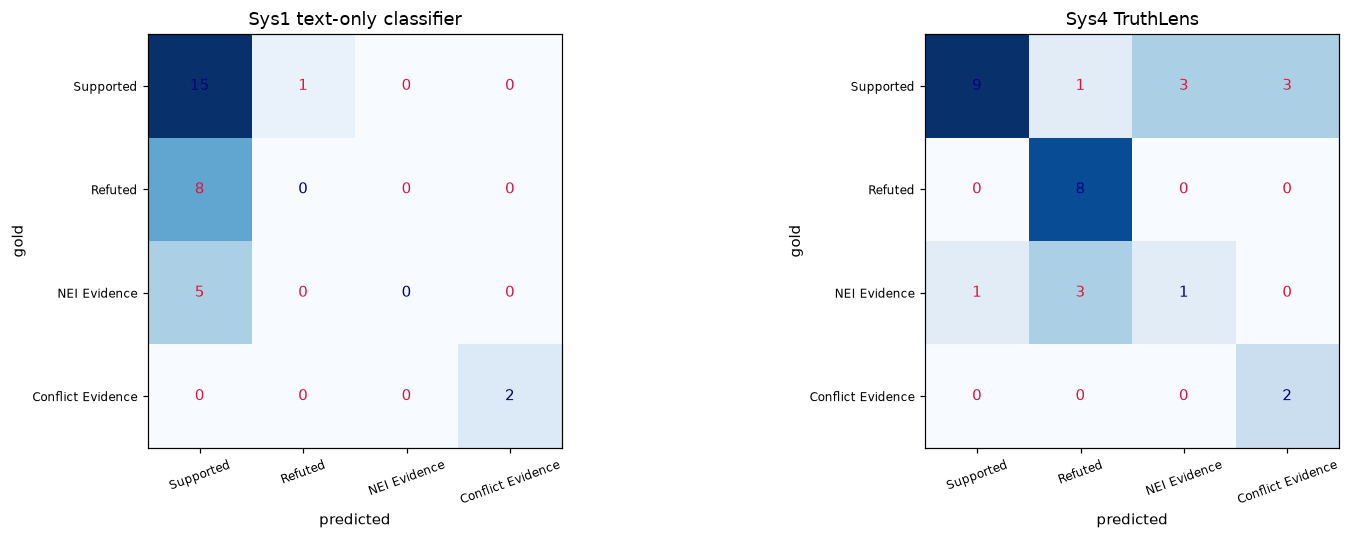

Temporal mismatch (recycled content) detection: {'accuracy': 0.968, 'recall': 0.5, 'false_positives': []}

Sys4 per-class report:
                      precision    recall  f1-score   support

           Supported       0.90      0.56      0.69        16
             Refuted       0.67      1.00      0.80         8
 Not Enough Evidence       0.25      0.20      0.22         5
Conflicting Evidence       0.40      1.00      0.57         2

            accuracy                           0.65        31
           macro avg       0.55      0.69      0.57        31
        weighted avg       0.70      0.65      0.64        31



In [17]:
# ============================================================================
# 8.2 Sys2 (similarity-only RAG), Sys3 (top-1 NLI), Sys4 (TruthLens full) + ablations
# ============================================================================
def sys2_pred(claim):
    # Similarity-only RAG: lexical containment of the top-1 retrieved evidence
    # + surface cues. No NLI, no fact-check pattern, no conflict label.
    top = retriever.search(claim, k=1)[0]
    ev_text = EVIDENCE_BY_ID[top["id"]]["text"]
    c_set, e_set = set(words_of(claim)), set(words_of(ev_text))
    containment = len(c_set & e_set) / len(c_set) if c_set else 0.0
    c_neg, e_neg = has_neg(claim), has_neg(ev_text)
    c_nums, e_nums = numbers_in(claim), numbers_in(ev_text)
    if (c_neg != e_neg or bool(c_nums - e_nums)) and containment >= 0.40:
        return REFUTED
    if containment >= 0.60: return SUPPORTED
    return NEI

def sys3_pred(claim):
    # Retrieval + NLI on the single top-1 evidence (standard RAG+NLI).
    top = retriever.search(claim, k=1)[0]
    label, _ = judge.judge(claim, top["id"])
    return {SUPPORTED: SUPPORTED, "entailment": SUPPORTED, "contradiction": REFUTED}.get(label, NEI)

def sys4_pred(c, **kw):
    return verify_claim(c["text"], post_text=c["post_text"], post_date=c["post_date"], **kw)["verdict"]

sys2_predictions = [sys2_pred(c["text"]) for c in GOLD_CLAIMS]
sys3_predictions = [sys3_pred(c["text"]) for c in GOLD_CLAIMS]
sys4_predictions = [sys4_pred(c) for c in GOLD_CLAIMS]
sys4_nbm25   = [sys4_pred(c, retriever_mode="bm25") for c in GOLD_CLAIMS]
sys4_ndense  = [sys4_pred(c, retriever_mode="dense") for c in GOLD_CLAIMS]
sys4_nconf   = [sys4_pred(c, use_conflict=False) for c in GOLD_CLAIMS]

SYSTEMS = {
    "Sys0 Binary text classifier": (y2, sys0_pred, y2, True),
    "Sys1 4-way text classifier": (y4, sys1_pred, y4, False),
    "Sys2 Retrieval + surface heuristic (no NLI)": (y4, sys2_predictions, y4, False),
    "Sys3 Retrieval + NLI (top-1)": (y4, sys3_predictions, y4, False),
    "Sys4 TruthLens (full)": (y4, sys4_predictions, y4, False),
    "Sys4 ablation: BM25-only": (y4, sys4_nbm25, y4, False),
    "Sys4 ablation: dense-only": (y4, sys4_ndense, y4, False),
    "Sys4 ablation: no conflict label": (y4, sys4_nconf, y4, False),
}

eval_rows = []
for name, (gold, pred, _, is_binary) in SYSTEMS.items():
    if is_binary:
        eval_rows.append(dict(system=name, task="binary fake/real",
                               accuracy=round(accuracy_score(gold, pred), 3),
                               macro_f1=round(f1_score(gold, pred, average="macro", zero_division=0), 3)))
    else:
        eval_rows.append(dict(system=name, task="4-way claim verdict",
                               accuracy=round(accuracy_score(gold, pred), 3),
                               macro_f1=round(f1_score(gold, pred, average="macro", zero_division=0), 3)))
SYSTEM_EVAL = pd.DataFrame(eval_rows)
display(SYSTEM_EVAL)
SYSTEM_EVAL.to_csv(os.path.join(OUT_DIR, "demo_verdict_eval.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (pred, title) in zip(axes, [(sys1_pred, "Sys1 text-only classifier"), (sys4_predictions, "Sys4 TruthLens")]):
    cm = confusion_matrix(y4, pred, labels=LABELS)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(4), [l.replace("Not Enough", "NEI").replace("Conflicting", "Conflict") for l in LABELS], rotation=20, fontsize=8)
    ax.set_yticks(range(4), [l.replace("Not Enough", "NEI").replace("Conflicting", "Conflict") for l in LABELS], fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="crimson" if i != j else "navy")
    ax.set_title(title); ax.set_xlabel("predicted"); ax.set_ylabel("gold")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "demo_confusion_matrices.png")); plt.show()

# --- temporal mismatch (recycled content) detection ---------------------------
temporal_pred, temporal_gold = [], []
for c in GOLD_CLAIMS:
    temporal_pred.append(FULL_RESULTS[c["cid"]]["temporal"]["flag"])
    temporal_gold.append(c["temporal_gold"])
TEMPORAL_METRICS = dict(
    accuracy=round(accuracy_score(temporal_gold, temporal_pred), 3),
    recall=round([a == b == True for a, b in zip(temporal_gold, temporal_pred)].count(True) / temporal_gold.count(True), 3),
    false_positives=[GOLD_CLAIMS[i]["cid"] for i, (g, p) in enumerate(zip(temporal_gold, temporal_pred)) if not g and p])
print("Temporal mismatch (recycled content) detection:", TEMPORAL_METRICS)
print("\nSys4 per-class report:")
print(classification_report(y4, sys4_predictions, labels=LABELS, zero_division=0))

In [18]:
# ============================================================================
# 8.3 Consolidated results (paper-ready summary tables)
# ============================================================================
CLAIM_EXTRACTION_METRICS = EXTRACTION_METRICS
RESULTS_SUMMARY = dict(
    mode=("full (transformer NLI + multilingual MiniLM)" if TRANSFORMERS_OK
          else "light (TF-IDF embeddings + heuristic judge)"),
    n_posts=len(POSTS), n_gold_claims=len(GOLD_CLAIMS), n_evidence=len(EVIDENCE_DOCS),
    language_detection_accuracy=round(float(lang_acc), 3),
    claim_extraction=CLAIM_EXTRACTION_METRICS,
    retrieval=RETRIEVAL_EVAL.to_dict("records"),
    systems=SYSTEM_EVAL.to_dict("records"),
    temporal=TEMPORAL_METRICS,
    narrative=NARRATIVE_METRICS)
with open(os.path.join(OUT_DIR, "demo_results_summary.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS_SUMMARY, f, indent=2, ensure_ascii=False)

print("=" * 70)
print("TRUTHLENS - DEMONSTRATION CORPUS SANITY CHECK (NOT RESEARCH RESULTS)")
print("=" * 70)
print(f"Mode: {RESULTS_SUMMARY['mode']}")
print(f"Claim extraction F1: {CLAIM_EXTRACTION_METRICS['f1']:.3f} | Language detection: {lang_acc:.0%}")
print(f"Retrieval Recall@5 (bm25/dense/hybrid): {RETRIEVAL_EVAL['recall_at_5'].tolist()}")
print(f"Temporal mismatch recall: {TEMPORAL_METRICS['recall']} | Narrative NMI: {NARRATIVE_METRICS['nmi']}")
print("\nSystem comparison (accuracy / macro-F1):")
for r in eval_rows:
    print(f"  {r['system']:34s} acc={r['accuracy']:.3f}  macroF1={r['macro_f1']:.3f}")
print("\nAll tables and figures saved to ./truthlens_outputs/")

TRUTHLENS - DEMONSTRATION CORPUS SANITY CHECK (NOT RESEARCH RESULTS)
Mode: full (transformer NLI + multilingual MiniLM)
Claim extraction F1: 1.000 | Language detection: 100%
Retrieval Recall@5 (bm25/dense/hybrid): [0.907, 1.0, 0.981]
Temporal mismatch recall: 0.5 | Narrative NMI: 0.813

System comparison (accuracy / macro-F1):
  Sys0 Binary text classifier        acc=0.516  macroF1=0.508
  Sys1 4-way text classifier         acc=0.548  macroF1=0.420
  Sys2 Retrieval + surface heuristic (no NLI) acc=0.645  macroF1=0.407
  Sys3 Retrieval + NLI (top-1)       acc=0.677  macroF1=0.478
  Sys4 TruthLens (full)              acc=0.645  macroF1=0.571
  Sys4 ablation: BM25-only           acc=0.710  macroF1=0.662
  Sys4 ablation: dense-only          acc=0.613  macroF1=0.541
  Sys4 ablation: no conflict label   acc=0.645  macroF1=0.429

All tables and figures saved to ./truthlens_outputs/


## 9. End-to-End Demo: `verify_post()`

The full TruthLens output for a submitted post: detected language, extracted atomic claims, per-claim verdict + confidence, supporting/refuting evidence with source provenance and dates, temporal-mismatch warnings, and the nearest narrative (event) for each claim.

Demos: a **recycled 2020 lockdown post** (temporal mismatch), a **conflicting-evidence** death-toll post, a **Hinglish refuted** post, and a **Hindi** post.

## 10. Human Evaluation Rubric (for the paper's justification-quality study)

Rate 10 system outputs on Likert 1-5 (template saved to `truthlens_outputs/human_eval_template.csv`):

| Dimension | Question |
|---|---|
| Verdict clarity | Is the verdict and its uncertainty easy to understand? |
| Evidence traceability | Can you follow the verdict to the cited evidence? |
| Uncertainty handling | Does the system appropriately express Not-Enough / Conflicting? |
| Usefulness vs binary label | Is this more informative than a fake/real label? |

## 11. Ethics and Limitations
- No source is treated as infallible; provenance is always displayed. Verdicts are evidence *relative*, not absolute truth.
- Rapidly evolving events can outdate evidence; timestamps are shown with every snippet.
- Hinglish/Hindi performance depends on model capability - measured explicitly (see light vs full mode difference).
- The system analyzes public content; it does not profile users or infer political identity.

## 12. Appendix: Scaling to External Benchmarks
Loaders (FEVER [6], AVeriTeC [5], FactDrill [4]) are stubbed in the next cell to run the same pipeline at scale. **Check the links before use.**

In [19]:
# ============================================================================
# 9.1 verify_post - the user-facing TruthLens demo
# ============================================================================
def verify_post(post_text, post_date="2024-06-01", top_k=5):
    print("=" * 78)
    print(f"POST: {post_text}")
    print(f"Language: {detect_language(post_text)} | Post date: {post_date}")
    print("=" * 78)
    claims = claim_extractor.extract(post_text)
    if not claims:
        print("No factual claims detected.")
        return []
    qvecs = retriever.encoder.encode(claims)
    results = []
    for i, claim in enumerate(claims):
        r = verify_claim(claim, post_text=post_text, post_date=post_date, top_k=top_k)
        qv = qvecs[i]
        sims = [(cosine(qv, retriever.encoder.encode([c["text"]])[0]), c["event"]) for c in GOLD_CLAIMS]
        nearest_event = sorted(sims, reverse=True)[0][1] if sims else "?"
        results.append(r)
        print(f"\n  CLAIM {i+1}: {claim}")
        print(f"  VERDICT: {r['verdict']}  (confidence {r['confidence']})")
        print(f"  NARRATIVE (nearest event): {nearest_event}")
        if r["temporal"]["flag"]:
            print(f"  TEMPORAL WARNING: {r['temporal']['reason']}")
        for ev_id in (r["supporting"] + r["refuting"])[:2]:
            e = EVIDENCE_BY_ID[ev_id]
            side = "SUPPORTS" if ev_id in r["supporting"] else "REFUTES"
            print(f"    [{side}] {e['id']} | {e['source']} ({e['stype']}, {e['sdate']})")
            print(f"           {e['text'][:95]}...")
        if r["verdict"] == NEI:
            print("    (no reliable supporting or refuting evidence found)")
    return results

_ = verify_post(POSTS[5]["text"], post_date="2024-03-31")      # recycled 2020 lockdown
_ = verify_post(POSTS[9]["text"], post_date="2023-06-03")      # conflicting death toll
_ = verify_post(POSTS[3]["text"], post_date="2023-08-24")      # Hinglish refuted
_ = verify_post(POSTS[17]["text"], post_date="2023-09-01")     # Hindi supported

POST: Breaking: PM Modi announced a complete nationwide lockdown starting tonight for 21 days #Lockdown
Language: en | Post date: 2024-03-31



  CLAIM 1: PM Modi announced a complete nationwide lockdown starting tonight for 21 days
  VERDICT: Refuted  (confidence 0.799)
  NARRATIVE (nearest event): COVID_LOCKDOWN
  TEMPORAL WARNING: post presents the event as current but relevant evidence is 853 days older (recycled content)
    [REFUTES] E24 | The Hindu (news, 2021-11-29)
           The three farm laws were repealed by Parliament in the winter session on 29 November 2021, afte...
    [REFUTES] E02 | The Hindu (news, 2019-08-05)
           Union Home Minister Amit Shah announced in the Rajya Sabha on 5 August 2019 that the government...
POST: Terrible news from Odisha. More than 280 people have died in the Balasore train accident. Rescue operations are still ongoing.
Language: en | Post date: 2023-06-03



  CLAIM 1: More than 280 people have died in the Balasore train accident
  VERDICT: Conflicting Evidence  (confidence 0.884)
  NARRATIVE (nearest event): BALASORE_2023
    [SUPPORTS] E17 | The Hindu (news, 2023-06-04)
           The Odisha state government said that 288 people died in the Balasore train accident on 4 June ...
    [SUPPORTS] E18 | Reuters (news, 2023-06-12)
           Official figures later revised the death toll to 296 people who died in the Balasore train acci...



  CLAIM 2: Rescue operations are still ongoing
  VERDICT: Refuted  (confidence 0.999)
  NARRATIVE (nearest event): BALASORE_2023
    [REFUTES] E20 | The Hindu (news, 2023-11-28)
           All 41 workers trapped in the collapsed Silkyara tunnel in Uttarakhand were rescued on 28 Novem...
POST: WhatsApp pe viral: Chandrayaan-3 ne Moon pe landing nahi ki, ISRO ne mission fail maan liya hai. Aur lander ka naam Pragyan tha. Aage forward mat karna.
Language: hinglish | Post date: 2023-08-24



  CLAIM 1: Chandrayaan-3 ne Moon pe landing nahi ki, ISRO ne mission fail maan liya hai
  VERDICT: Refuted  (confidence 0.936)
  NARRATIVE (nearest event): CHANDRAYAAN_3
    [REFUTES] E09 | PIB Fact Check (factcheck, 2023-08-27)
           Viral posts claiming Chandrayaan-3 failed and that ISRO admitted the mission was unsuccessful a...
    [REFUTES] E06 | ISRO (Govt. of India) (government, 2023-08-23)
           ISRO confirmed that the Vikram lander of Chandrayaan-3 achieved a soft landing near the lunar s...



  CLAIM 2: Aur lander ka naam Pragyan tha
  VERDICT: Refuted  (confidence 0.993)
  NARRATIVE (nearest event): CHANDRAYAAN_3
    [REFUTES] E10 | Alt News (factcheck, 2023-08-25)
           Chandrayaan-3's lander is named Vikram; Pragyan is the rover. Posts claiming the lander was nam...
POST: चंद्रयान-3 ने 23 अगस्त 2023 को चंद्रमा के दक्षिणी ध्रुव के पास सॉफ्ट लैंडिंग की। भारत पहला देश है जिसने चंद्रमा के दक्षिणी ध्रुव के पास लैंडिंग की।
Language: hi | Post date: 2023-09-01



  CLAIM 1: चंद्रयान-3 ने 23 अगस्त 2023 को चंद्रमा के दक्षिणी ध्रुव के पास सॉफ्ट लैंडिंग की
  VERDICT: Conflicting Evidence  (confidence 0.613)
  NARRATIVE (nearest event): CHANDRAYAAN_3
    [SUPPORTS] E06 | ISRO (Govt. of India) (government, 2023-08-23)
           ISRO confirmed that the Vikram lander of Chandrayaan-3 achieved a soft landing near the lunar s...
    [REFUTES] E28 | The Hindu (news, 2023-06-15)
           Cyclone Biparjoy made landfall near Jakhau in Gujarat on 15 June 2023, prompting the evacuation...



  CLAIM 2: भारत पहला देश है जिसने चंद्रमा के दक्षिणी ध्रुव के पास लैंडिंग की
  VERDICT: Not Enough Evidence  (confidence 0.911)
  NARRATIVE (nearest event): CHANDRAYAAN_3
    (no reliable supporting or refuting evidence found)


In [20]:
# ============================================================================
# 12.1 Appendix: external benchmark loaders (FEVER / AVeriTeC / FactDrill)
# Run only with internet + disk space. These feed the SAME pipeline at scale.
# ============================================================================
DOWNLOAD_EXTERNAL = False   # flip to True to download samples

FEVER_URL = "https://s3-eu-west-1.amazonaws.com/fever.public/train.jsonl"   # verify link
AVERITEC_REPO = "https://github.com/avirteclab/AVeriTeC"                    # verify link
FACTDRILL_NOTE = ("FactDrill: obtain via Precog research group / ICWSM 2022 paper "
                  "(DOI: 10.1609/icwsm.v16i1.19384) - check institutional access.")

def load_fever_sample(n=500):
    import urllib.request
    path = os.path.join(OUT_DIR, "fever_train_sample.jsonl")
    urllib.request.urlretrieve(FEVER_URL, path)
    rows = []
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n: break
            d = json.loads(line)
            label = {"SUPPORTS": "Supported", "REFUTES": "Refuted",
                     "NOT ENOUGH INFO": "Not Enough Evidence"}[d["label"]]
            rows.append(dict(text=d["claim"], gold=label, evidence=[]))
    return rows

if DOWNLOAD_EXTERNAL:
    fever_rows = load_fever_sample()
    print("FEVER sample loaded:", len(fever_rows))
else:
    print("External downloads disabled (DOWNLOAD_EXTERNAL=False).")
    print("FEVER:", FEVER_URL)
    print("AVeriTeC:", AVERITEC_REPO)
    print(FACTDRILL_NOTE)

# ---- human evaluation template ---------------------------------------------
pd.DataFrame([dict(example_id="", claim="", verdict="", clarity_1to5="",
                   traceability_1to5="", uncertainty_1to5="", usefulness_1to5="")]
            ).to_csv(os.path.join(OUT_DIR, "human_eval_template.csv"), index=False)

# ---- final artifact manifest ------------------------------------------------
print("\nArtifacts written to truthlens_outputs/:")
for fn in sorted(os.listdir(OUT_DIR)):
    print("  -", fn)
print("\nPhase 1 complete: run all cells top-to-bottom, then use results_summary.json")
print("and the CSV tables as the experimental section of the research paper.")

External downloads disabled (DOWNLOAD_EXTERNAL=False).
FEVER: https://s3-eu-west-1.amazonaws.com/fever.public/train.jsonl
AVeriTeC: https://github.com/avirteclab/AVeriTeC
FactDrill: obtain via Precog research group / ICWSM 2022 paper (DOI: 10.1609/icwsm.v16i1.19384) - check institutional access.

Artifacts written to truthlens_outputs/:
  - averitec_conflict_rules.csv
  - averitec_conflict_threshold_sweep.csv
  - averitec_confusion_matrices.png
  - averitec_evidence_graph.gexf
  - averitec_evidence_graph_example.png
  - averitec_india_subset.csv
  - averitec_narrative_clusters.png
  - averitec_provenance.json
  - averitec_rerank_eval.csv
  - averitec_retrieval_eval.csv
  - averitec_source_provenance.png
  - averitec_system_eval.csv
  - averitec_temporal_characterisation.json
  - averitec_temporal_characterisation.png
  - averitec_temporal_robustness.csv
  - averitec_top_sources.csv
  - consolidated_retrieval_eval.csv
  - consolidated_system_eval.csv
  - demo_confusion_matrices.png
  - 

## 10. REAL EXPERIMENT A - FEVER (Wikipedia-backed claim verification)

**Dataset:** FEVER [6] - 185,445 claims labeled SUPPORTS / REFUTES / NOT ENOUGH INFO with sentence-level Wikipedia evidence. Downloaded from the official FEVER site (fever.ai): `shared_task_dev.jsonl` (19,998 labeled claims) + `train.jsonl` + `wiki-pages.zip` (June 2017 dump). No synthetic substitution.

**Protocol (documented in full for reproducibility):**
- **Test set:** 600 claims sampled from the labelled dev split (200 per label, `SEED=42`).
- **Evidence corpus - two settings, both reported.** Retrieval difficulty depends entirely on what the distractors are, so a single number would be misleading:
  - **(A) gold-pages-only** - all sentences of the union of the sampled claims' gold evidence pages: **6,934 sentences / 435 pages**. Every distractor comes from a page already known to be relevant. This is the cheap protocol, and its Recall@k is **optimistic** - the retriever never has to reject an unrelated topic.
  - **(B) expanded** - setting (A) plus **200,155 sentences from 45,667 Wikipedia pages sampled uniformly at random** (`SEED=42`) from the full June-2017 dump: **207,089 sentences total**, a 30x larger haystack. Built by `prep_fever_expand.py`.
  Setting (B) is the **headline** setting for verdict classification; (A) is reported alongside it to quantify how much the cheap protocol inflates retrieval scores. Neither is the full 5.4M-page shared-task setting - that remains a documented limitation.
- **Verdict labels:** SUPPORTS -> Supported, REFUTES -> Refuted, NOT ENOUGH INFO -> Not Enough Evidence. FEVER has no Conflicting label, so conflict-aware aggregation is disabled here (it is evaluated on AVeriTeC in Part 11).
- **Text-only baseline (Sys1)** is trained on the FEVER **train split** (disjoint from dev) - a real trained classifier, not a stub.
- **Evidence systems (Sys2-4)** retrieve top-5 evidence from the corpus and judge each pair with the transformer NLI model.

**Metrics:** Retrieval Recall@5 / Precision@5 / Evidence F1; verdict Accuracy and Macro-F1 with bootstrap 95% CIs; McNemar's test (Sys4 vs Sys3); confusion matrices.

In [21]:
# ============================================================================
# 10.1 FEVER - load prepared data (run prep_fever.py once, see Part 14)
# ============================================================================
FEVER_SAMPLE_PATH = os.path.join(DATA_DIR, "fever_sample.json")
FEVER_CORPUS_PATH = os.path.join(DATA_DIR, "fever_wiki_corpus.jsonl")
FEVER_TRAIN_PATH  = os.path.join(DATA_DIR, "fever_train.jsonl")
if not (os.path.exists(FEVER_SAMPLE_PATH) and os.path.exists(FEVER_CORPUS_PATH)):
    raise FileNotFoundError(
        "FEVER prepared data not found. Run the acquisition steps in Part 14 "
        "(download from https://fever.ai/download/fever/ ... then `python prep_fever.py`).")

FEVER_SAMPLE = json.load(open(FEVER_SAMPLE_PATH, encoding="utf-8"))
FEVER_CORPUS = [json.loads(l) for l in open(FEVER_CORPUS_PATH, encoding="utf-8")]

# Setting (B): the expanded corpus with random distractor pages, if prepared.
FEVER_EXPANDED_PATH = os.path.join(DATA_DIR, "fever_wiki_corpus_expanded.jsonl")
FEVER_MANIFEST_PATH = os.path.join(DATA_DIR, "fever_expand_manifest.json")
FEVER_CORPUS_EXPANDED, FEVER_EXPAND_MANIFEST = None, None
if os.path.exists(FEVER_EXPANDED_PATH):
    FEVER_CORPUS_EXPANDED = [json.loads(l) for l in open(FEVER_EXPANDED_PATH, encoding="utf-8")]
    if os.path.exists(FEVER_MANIFEST_PATH):
        FEVER_EXPAND_MANIFEST = json.load(open(FEVER_MANIFEST_PATH, encoding="utf-8"))
    print(f"Expanded corpus available: {len(FEVER_CORPUS_EXPANDED)} sentences "
          f"({FEVER_EXPAND_MANIFEST or 'no manifest'})")
else:
    print("Expanded corpus NOT found - run `python prep_fever_expand.py` to build "
          "setting (B). Only the optimistic gold-pages-only setting will be reported.")

# The corpus the verdict experiments run against: prefer the harder, honest one.
FEVER_MAIN_CORPUS = FEVER_CORPUS_EXPANDED if FEVER_CORPUS_EXPANDED else FEVER_CORPUS
FEVER_MAIN_SETTING = "expanded" if FEVER_CORPUS_EXPANDED else "gold_pages_only"
FEVER_LABEL_MAP = {"SUPPORTS": "Supported", "REFUTES": "Refuted", "NOT ENOUGH INFO": "Not Enough Evidence"}
FEVER_LABELS = ["Supported", "Refuted", "Not Enough Evidence"]
fever_gold = [FEVER_LABEL_MAP[c["label"]] for c in FEVER_SAMPLE]
fever_with_ev = [c for c in FEVER_SAMPLE if c["gold_evidence_ids"]]

print(f"FEVER test sample: {len(FEVER_SAMPLE)} claims "
      f"({Counter(fever_gold)})")
print(f"Claims with gold evidence: {len(fever_with_ev)}")
print(f"Evidence corpus: {len(FEVER_CORPUS)} sentences "
      f"from {len(set(s['page'] for s in FEVER_CORPUS))} Wikipedia pages")
print(f"Gold evidence docs/claim: {np.mean([len(c['gold_evidence_ids']) for c in fever_with_ev]):.2f}")

Expanded corpus available: 207089 sentences ({'seed': 42, 'gold_sentences': 6934, 'gold_pages': 435, 'distractor_pages_requested': 50000, 'distractor_pages_found': 45667, 'distractor_sentences': 200155, 'total_sentences': 207089, 'min_sentence_chars': 30, 'source': 'https://fever.ai/download/fever/wiki-pages.zip (June 2017 dump)'})
FEVER test sample: 600 claims (Counter({'Not Enough Evidence': 200, 'Supported': 200, 'Refuted': 200}))
Claims with gold evidence: 397
Evidence corpus: 6934 sentences from 435 Wikipedia pages
Gold evidence docs/claim: 1.78


In [22]:
# ============================================================================
# 10.2 FEVER - evidence retrieval evaluation (BM25 / dense / hybrid)
# ============================================================================
# Both corpus settings are evaluated so the inflation of the cheap protocol is
# measurable rather than assumed. FEVER_RETRIEVERS is kept in memory and reused
# by the verdict cell below (rebuilding costs minutes of encoding).
FEVER_SETTINGS = [("gold_pages_only", FEVER_CORPUS)]
if FEVER_CORPUS_EXPANDED:
    FEVER_SETTINGS.append(("expanded", FEVER_CORPUS_EXPANDED))

K_EVAL = 5                     # the k in Recall@k / Precision@k, used for both
FEVER_RETRIEVERS = {}
fever_cache = load_cache("fever_retrieval")
need = fever_cache is None
if not need:
    print("FEVER retrieval eval loaded from cache")
    fever_cache.setdefault("by_setting", {})
    need = any(name not in fever_cache["by_setting"] for name, _ in FEVER_SETTINGS)
    if need:
        print("  ... but a corpus setting is missing from the cache - recomputing")
if need:
    fever_cache = dict(by_setting={})
    for setting, corpus in FEVER_SETTINGS:
        print(f"\n--- FEVER retrieval [{setting}] over {len(corpus)} sentences ---", flush=True)
        r = HybridRetriever([dict(id=x["id"], text=x["text"]) for x in corpus],
                            TextEncoder(), fit_texts=[c["claim"] for c in FEVER_SAMPLE],
                            cache_key=f"fever_{setting}")
        FEVER_RETRIEVERS[setting] = r
        fever_cache["by_setting"][setting] = dict(n_docs=len(corpus), modes={})
        for mode in ["bm25", "dense", "hybrid"]:
            per_claim = []
            t0 = time.time()
            for c in fever_with_ev:
                gold = set(c["gold_evidence_ids"])
                top = [x["id"] for x in r.search(c["claim"], k=K_EVAL, mode=mode)]
                hits = len(set(top) & gold)
                per_claim.append((hits / len(gold), hits / K_EVAL,
                                  2 * hits / (K_EVAL + len(gold))))
            m = dict(recall_at_5=round(float(np.mean([x[0] for x in per_claim])), 4),
                     precision_at_5=round(float(np.mean([x[1] for x in per_claim])), 4),
                     evidence_f1_at_5=round(float(np.mean([x[2] for x in per_claim])), 4))
            fever_cache["by_setting"][setting]["modes"][mode] = m
            print(f"  {mode:6s} {m}  ({time.time()-t0:.0f}s)", flush=True)
    save_cache("fever_retrieval", fever_cache)

FEVER_RETRIEVAL = pd.DataFrame([
    dict(setting=st, n_docs=d["n_docs"], mode=mode, **m)
    for st, d in fever_cache["by_setting"].items() for mode, m in d["modes"].items()])
FEVER_RETRIEVAL.to_csv(os.path.join(OUT_DIR, "fever_retrieval_eval.csv"), index=False)
display(FEVER_RETRIEVAL)
if len(fever_cache["by_setting"]) > 1:
    a = fever_cache["by_setting"]["gold_pages_only"]["modes"]["hybrid"]["recall_at_5"]
    b = fever_cache["by_setting"]["expanded"]["modes"]["hybrid"]["recall_at_5"]
    print(f"\nRecall@5 (hybrid): gold-pages-only {a:.3f} -> expanded {b:.3f} "
          f"({a - b:+.3f} absolute). The gap is the inflation of the cheap protocol.")

FEVER retrieval eval loaded from cache


,setting,n_docs,mode,recall_at_5,precision_at_5,evidence_f1_at_5
0,gold_pages_only,6934,bm25,0.7637,0.2121,0.3097
1,gold_pages_only,6934,dense,0.7242,0.1995,0.2925
2,gold_pages_only,6934,hybrid,0.7877,0.2207,0.3209
3,expanded,207089,bm25,0.6267,0.1602,0.2427
4,expanded,207089,dense,0.5901,0.1547,0.2314
5,expanded,207089,hybrid,0.6695,0.1773,0.2637



Recall@5 (hybrid): gold-pages-only 0.788 -> expanded 0.669 (+0.118 absolute). The gap is the inflation of the cheap protocol.


In [23]:
# ============================================================================
# 10.3 FEVER - Sys1 text-only baseline, TRAINED ON THE FEVER TRAIN SPLIT
# ============================================================================
fever_sys1_cache = load_cache("fever_sys1")
if fever_sys1_cache is None:
    fever_train = [json.loads(l) for l in open(FEVER_TRAIN_PATH, encoding="utf-8")]
    random.seed(SEED); random.shuffle(fever_train)
    fever_train = fever_train[:20000]
    X_train = [r["claim"] for r in fever_train]
    y_train = [FEVER_LABEL_MAP[r["label"]] for r in fever_train]
    pipe = make_pipeline(TfidfVectorizer(analyzer="word", token_pattern=r"\w+",
                                         ngram_range=(1, 2), min_df=2, stop_words=list(STOP)),
                         LogisticRegression(max_iter=2000, C=4.0))
    t0 = time.time(); pipe.fit(X_train, y_train); print(f"Sys1 trained on {len(X_train)} FEVER train claims in {time.time()-t0:.1f}s")
    fever_sys1 = pipe.predict([c["claim"] for c in FEVER_SAMPLE]).tolist()
    fever_sys0 = ["Likely True" if p == "Supported" else "Possibly False" for p in fever_sys1]
    fever_sys1_cache = dict(sys1=fever_sys1, sys0=fever_sys0)
    save_cache("fever_sys1", fever_sys1_cache)
else:
    print("FEVER Sys0/Sys1 loaded from cache")
fever_sys1 = fever_sys1_cache["sys1"]
fever_sys0_binary_gold = ["Likely True" if g == "Supported" else "Possibly False" for g in fever_gold]
print("Sys0 binary:", round(accuracy_score(fever_sys0_binary_gold, fever_sys1_cache["sys0"]), 3),
      "| Sys1 4-way:", round(accuracy_score(fever_gold, fever_sys1), 3),
      "macro-F1", round(f1_score(fever_gold, fever_sys1, average="macro", zero_division=0), 3))

FEVER Sys0/Sys1 loaded from cache
Sys0 binary: 0.518 | Sys1 4-way: 0.44 macro-F1 0.421


In [24]:
# ============================================================================
# 10.4 FEVER - evidence-based systems (Sys2 similarity-only, Sys3 top-1 NLI,
#              Sys4 TruthLens full + retrieval ablations)
# ============================================================================
import time as _time

def sys2_pred_text(claim, evidence_text):
    # similarity-only baseline: lexical containment + surface cues, no NLI
    c_set, e_set = set(words_of(claim)), set(words_of(evidence_text))
    containment = len(c_set & e_set) / len(c_set) if c_set else 0.0
    c_neg, e_neg = has_neg(claim), has_neg(evidence_text)
    c_nums, e_nums = numbers_in(claim), numbers_in(evidence_text)
    if (c_neg != e_neg or bool(c_nums - e_nums)) and containment >= 0.40:
        return "Refuted"
    if containment >= 0.60:
        return "Supported"
    return "Not Enough Evidence"

# Verdict runs against FEVER_MAIN_CORPUS (the expanded, harder corpus when it
# has been prepared) so the headline numbers are not inflated by the cheap
# gold-pages-only protocol.
fev_id2idx = {x["id"]: i for i, x in enumerate(FEVER_MAIN_CORPUS)}
fever_systems = load_cache("fever_systems")
if fever_systems is None:
    if not TRANSFORMERS_OK:
        raise RuntimeError("Real experiments require full mode (transformer NLI). Set USE_TRANSFORMERS=True.")
    fever_retriever = FEVER_RETRIEVERS.get(FEVER_MAIN_SETTING)
    if fever_retriever is None:            # cache hit above -> retriever not in memory
        print(f"Rebuilding FEVER retriever [{FEVER_MAIN_SETTING}] ...", flush=True)
        fever_retriever = HybridRetriever(
            [dict(id=x["id"], text=x["text"]) for x in FEVER_MAIN_CORPUS],
            TextEncoder(), fit_texts=[c["claim"] for c in FEVER_SAMPLE],
            cache_key=f"fever_{FEVER_MAIN_SETTING}")
        FEVER_RETRIEVERS[FEVER_MAIN_SETTING] = fever_retriever
    judge_full = NLIJudge(fever_retriever.encoder)
    fever_systems = dict(preds={}, setting=FEVER_MAIN_SETTING,
                         n_docs=len(FEVER_MAIN_CORPUS), nli_model=judge_full.model_name)
    TOP_K = 5
    for mode in ["hybrid", "bm25", "dense"]:
        preds_sys3, preds_sys4, preds_sys2 = [], [], []
        t0 = _time.time()
        for c in FEVER_SAMPLE:
            retrieved = fever_retriever.search(c["claim"], k=TOP_K, mode=mode)
            ev_texts = [FEVER_MAIN_CORPUS[fev_id2idx[r["id"]]]["text"] for r in retrieved]
            if not ev_texts:
                # BM25 returns nothing when no query term is in the vocabulary. That is
                # an abstention, not a crash: without it the whole ablation aborts on a
                # single unlucky claim.
                preds_sys3.append("Not Enough Evidence")
                preds_sys4.append("Not Enough Evidence")
                preds_sys2.append("Not Enough Evidence")
                continue
            judgments = judge_full.judge_many(c["claim"], ev_texts)
            # Sys3: standard RAG+NLI - verdict from the single top-1 evidence
            lab3 = judgments[0][0]
            preds_sys3.append({"entailment": "Supported", "contradiction": "Refuted"}.get(lab3, "Not Enough Evidence"))
            # Sys4: TruthLens aggregation over all top-k judgments (no conflict label on FEVER)
            judged = [(lab, prob) for lab, prob in judgments]
            ent = [j for j in judged if j[0] == "entailment"]
            con = [j for j in judged if j[0] == "contradiction"]
            if ent and con:
                preds_sys4.append("Refuted" if np.mean([j[1] for j in con]) > np.mean([j[1] for j in ent]) else "Supported")
            elif con: preds_sys4.append("Refuted")
            elif ent: preds_sys4.append("Supported")
            else:     preds_sys4.append("Not Enough Evidence")
            # Sys2: similarity-only (lexical containment + surface cues, no NLI)
            preds_sys2.append(sys2_pred_text(c["claim"], ev_texts[0]))
        fever_systems["preds"][f"sys3_{mode}"] = preds_sys3
        fever_systems["preds"][f"sys4_{mode}"] = preds_sys4
        if mode == "hybrid":
            fever_systems["preds"]["sys2"] = preds_sys2
        print(f"FEVER systems {mode}: {_time.time()-t0:.0f}s for {len(FEVER_SAMPLE)} claims", flush=True)
    save_cache("fever_systems", fever_systems)
else:
    print("FEVER system predictions loaded from cache")
print(f"FEVER verdict setting: {fever_systems.get('setting')} "
      f"({fever_systems.get('n_docs')} docs) | NLI: {fever_systems.get('nli_model')}")

# No-information baseline: always predict the most frequent TRAIN-split class.
# On an imbalanced test set this is the number every other system must beat before
# its accuracy means anything.
_fever_majority = Counter(FEVER_LABEL_MAP[r["label"]] for r in
                          (json.loads(l) for l in open(FEVER_TRAIN_PATH, encoding="utf-8"))
                          ).most_common(1)[0][0]
_fever_maj_pred = [_fever_majority] * len(fever_gold)
print(f"FEVER majority class (from train): {_fever_majority}")

FEVER_SYSTEMS_DF = pd.DataFrame([
    dict(system=f"Sys-Maj majority class ({_fever_majority})", dataset="FEVER",
         accuracy=round(accuracy_score(fever_gold, _fever_maj_pred), 3),
         macro_f1=round(f1_score(fever_gold, _fever_maj_pred, average="macro", zero_division=0), 3)),
    dict(system="Sys0 Binary text-only", dataset="FEVER",
         accuracy=round(accuracy_score(fever_sys0_binary_gold, fever_sys1_cache["sys0"]), 3),
         macro_f1=round(f1_score(fever_sys0_binary_gold, fever_sys1_cache["sys0"], average="macro", zero_division=0), 3)),
    dict(system="Sys1 Text-only classifier", dataset="FEVER",
         accuracy=round(accuracy_score(fever_gold, fever_sys1), 3),
         macro_f1=round(f1_score(fever_gold, fever_sys1, average="macro", zero_division=0), 3)),
    dict(system="Sys2 Retrieval + surface heuristic (no NLI)", dataset="FEVER",
         accuracy=round(accuracy_score(fever_gold, fever_systems["preds"]["sys2"]), 3),
         macro_f1=round(f1_score(fever_gold, fever_systems["preds"]["sys2"], average="macro", zero_division=0), 3)),
])
for mode in ["hybrid", "bm25", "dense"]:
    name = "Sys3 Retrieval+NLI top-1" if mode == "hybrid" else f"Sys3 ({mode})"
    FEVER_SYSTEMS_DF = pd.concat([FEVER_SYSTEMS_DF, pd.DataFrame([
        dict(system=name, dataset="FEVER",
             accuracy=round(accuracy_score(fever_gold, fever_systems["preds"][f"sys3_{mode}"]), 3),
             macro_f1=round(f1_score(fever_gold, fever_systems["preds"][f"sys3_{mode}"], average="macro", zero_division=0), 3)),
        dict(system=("Sys4 TruthLens full" if mode == "hybrid" else f"Sys4 ablation ({mode}-only)"), dataset="FEVER",
             accuracy=round(accuracy_score(fever_gold, fever_systems["preds"][f"sys4_{mode}"]), 3),
             macro_f1=round(f1_score(fever_gold, fever_systems["preds"][f"sys4_{mode}"], average="macro", zero_division=0), 3)),
    ])], ignore_index=True)
display(FEVER_SYSTEMS_DF)
FEVER_SYSTEMS_DF.to_csv(os.path.join(OUT_DIR, "fever_system_eval.csv"), index=False)

FEVER system predictions loaded from cache
FEVER verdict setting: expanded (207089 docs) | NLI: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli


FEVER majority class (from train): Supported

,system,dataset,accuracy,macro_f1
0,Sys-Maj majority class (Supported),FEVER,0.333,0.167
1,Sys0 Binary text-only,FEVER,0.518,0.518
2,Sys1 Text-only classifier,FEVER,0.440,0.421
3,Sys2 Retrieval + surface heuristic (no NLI),FEVER,0.540,0.504
4,Sys3 Retrieval+NLI top-1,FEVER,0.660,0.663
5,Sys4 TruthLens full,FEVER,0.723,0.722
6,Sys3 (bm25),FEVER,0.673,0.675
7,Sys4 ablation (bm25-only),FEVER,0.710,0.712
8,Sys3 (dense),FEVER,0.652,0.654
9,Sys4 ablation (dense-only),FEVER,0.667,0.669


FEVER bootstrap CIs (mean [95% CI]):
  Sys4 accuracy: (0.723, 0.687, 0.758) | macro-F1: (0.721, 0.685, 0.756)
  Sys3 accuracy: (0.66, 0.622, 0.697)
  McNemar Sys4 vs Sys3: {'b': 81, 'c': 43, 'chi2': 11.04, 'p': 0.00089}
  McNemar Sys4 vs Sys1: {'b': 218, 'c': 48, 'chi2': 107.372, 'p': 0.0}

Sys4 (TruthLens) per-class report on FEVER:
                     precision    recall  f1-score   support

          Supported       0.83      0.81      0.82       200
            Refuted       0.67      0.77      0.72       200
Not Enough Evidence       0.68      0.59      0.63       200

           accuracy                           0.72       600
          macro avg       0.73      0.72      0.72       600
       weighted avg       0.73      0.72      0.72       600



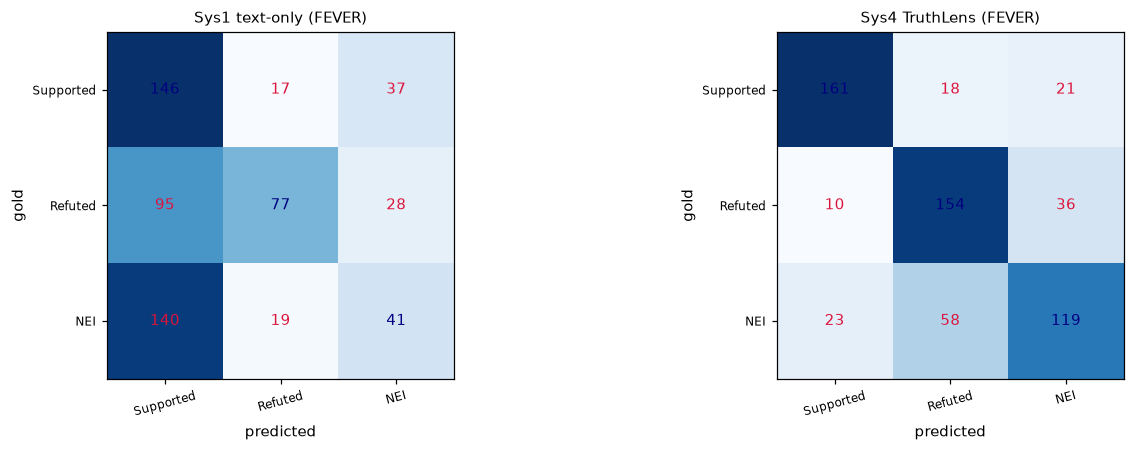

In [25]:
# ============================================================================
# 10.5 FEVER - significance tests, per-class report, confusion matrices
# ============================================================================
fever_stats = dict(
    sys4_acc_ci=bootstrap_ci(fever_gold, fever_systems["preds"]["sys4_hybrid"], acc_metric),
    sys4_f1_ci=bootstrap_ci(fever_gold, fever_systems["preds"]["sys4_hybrid"], macro_f1_metric),
    sys3_acc_ci=bootstrap_ci(fever_gold, fever_systems["preds"]["sys3_hybrid"], acc_metric),
    mcnemar_sys4_vs_sys3=mcnemar_test(fever_systems["preds"]["sys4_hybrid"],
                                      fever_systems["preds"]["sys3_hybrid"], fever_gold),
    mcnemar_sys4_vs_sys1=mcnemar_test(fever_systems["preds"]["sys4_hybrid"], fever_sys1, fever_gold))
print("FEVER bootstrap CIs (mean [95% CI]):")
print("  Sys4 accuracy:", fever_stats["sys4_acc_ci"], "| macro-F1:", fever_stats["sys4_f1_ci"])
print("  Sys3 accuracy:", fever_stats["sys3_acc_ci"])
print("  McNemar Sys4 vs Sys3:", fever_stats["mcnemar_sys4_vs_sys3"])
print("  McNemar Sys4 vs Sys1:", fever_stats["mcnemar_sys4_vs_sys1"])
print("\nSys4 (TruthLens) per-class report on FEVER:")
print(classification_report(fever_gold, fever_systems["preds"]["sys4_hybrid"],
                           labels=FEVER_LABELS, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (pred, title) in zip(axes, [(fever_sys1, "Sys1 text-only (FEVER)"),
                                    (fever_systems["preds"]["sys4_hybrid"], "Sys4 TruthLens (FEVER)")]):
    cm = confusion_matrix(fever_gold, pred, labels=FEVER_LABELS)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3), ["Supported", "Refuted", "NEI"], rotation=15, fontsize=8)
    ax.set_yticks(range(3), ["Supported", "Refuted", "NEI"], fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="crimson" if i != j else "navy")
    ax.set_title(title, fontsize=10); ax.set_xlabel("predicted"); ax.set_ylabel("gold")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "fever_confusion_matrices.png")); plt.show()
EXPERIMENT_REGISTRY.append(dict(experiment="FEVER retrieval eval (BM25/dense/hybrid, 397 gold-evidence claims)",
                                status="completed", data="real (fever.ai)"))
EXPERIMENT_REGISTRY.append(dict(experiment="FEVER verdict classification (600 claims, 5 systems + ablations)",
                                status="completed", data="real (fever.ai)"))

### 10.6 Two-stage retrieval: does reranking lift FEVER?

Part 10.2 showed retrieval degrading sharply on the expanded corpus (hybrid Recall@5 0.788 → 0.669). Since every evidence-based system reads whatever retrieval hands it, that ceiling propagates into every verdict number. The standard fix is a **second stage**: retrieve a deep pool cheaply, then rerank it with a cross-encoder that reads the (claim, evidence) pair jointly.

Protocol: hybrid top-50 → `cross-encoder/ms-marco-MiniLM-L-6-v2` → top-5, then the same NLI judge and aggregation as Sys4. The baseline row is recomputed **from the same depth-50 pool** so the only difference is the reranking step.

In [26]:
# ============================================================================
# 10.6 FEVER - cross-encoder reranking, retrieval AND verdict impact
# ============================================================================
POOL_RR, K_RR = 50, 5

def rerank_eval(name, retriever, corpus, claims, claim_texts, gold_sets,
                reranker, judge, cache_name, labels, gold_labels,
                use_conflict=False):
    '''Retrieve a depth-POOL_RR pool once, then score it two ways (first-stage
    top-5 vs reranked top-5) through identical NLI + aggregation, so the delta
    isolates the reranker.'''
    cached = load_cache(cache_name)
    if cached is None:
        rows_base, rows_rr, preds_base, preds_rr = [], [], [], []
        t0 = _time.time()
        for qi, ctext in enumerate(claim_texts):
            pool = retriever.search(ctext, k=POOL_RR, mode="hybrid")
            top_base = pool[:K_RR]
            top_rr = reranker.rerank(ctext, pool, k=K_RR)
            gold = gold_sets[qi]
            for bucket, top in ((rows_base, top_base), (rows_rr, top_rr)):
                if gold:
                    hits = len(({r["id"] for r in top}) & gold)
                    bucket.append((hits / len(gold), hits / K_RR,
                                   2 * hits / (K_RR + len(gold))))
            for bucket, top in ((preds_base, top_base), (preds_rr, top_rr)):
                js = judge.judge_many(ctext, [r["text"] for r in top])
                v, _ = aggregate_verdict([(l, p, i) for i, (l, p) in enumerate(js)],
                                         use_conflict=use_conflict)
                bucket.append(v)
            if (qi + 1) % 200 == 0:
                print(f"  {qi+1}/{len(claim_texts)} | {_time.time()-t0:.0f}s", flush=True)
        cached = dict(rows_base=rows_base, rows_rr=rows_rr,
                      preds_base=preds_base, preds_rr=preds_rr,
                      pool=POOL_RR, k=K_RR)
        print(f"  {name} rerank pass: {_time.time()-t0:.0f}s", flush=True)
        save_cache(cache_name, cached)
    else:
        print(f"{name} rerank results loaded from cache")

    def _ret(rows):
        a = np.asarray(rows, dtype=float)
        return dict(recall_at_5=round(float(a[:, 0].mean()), 4),
                    precision_at_5=round(float(a[:, 1].mean()), 4),
                    evidence_f1_at_5=round(float(a[:, 2].mean()), 4))

    def _ver(preds):
        return dict(accuracy=round(accuracy_score(gold_labels, preds), 3),
                    macro_f1=round(f1_score(gold_labels, preds, average="macro",
                                            zero_division=0), 3))

    df = pd.DataFrame([
        dict(dataset=name, stage=f"hybrid top-{K_RR} (from depth-{POOL_RR} pool)",
             **_ret(cached["rows_base"]), **_ver(cached["preds_base"])),
        dict(dataset=name, stage=f"+ cross-encoder rerank of top-{POOL_RR}",
             **_ret(cached["rows_rr"]), **_ver(cached["preds_rr"])),
    ])
    return df, cached

RERANKER = CrossEncoderReranker()

# The verdict cells build their judge inside a cache guard, so it may not exist in
# this kernel. Build the retriever/judge explicitly here (both hit warm caches).
_fever_retr = FEVER_RETRIEVERS.get(FEVER_MAIN_SETTING)
if _fever_retr is None:
    _fever_retr = HybridRetriever(
        [dict(id=x["id"], text=x["text"]) for x in FEVER_MAIN_CORPUS], TextEncoder(),
        fit_texts=[c["claim"] for c in FEVER_SAMPLE],
        cache_key=f"fever_{FEVER_MAIN_SETTING}")
    FEVER_RETRIEVERS[FEVER_MAIN_SETTING] = _fever_retr
RERANK_JUDGE = NLIJudge(_fever_retr.encoder)

fever_rr_df, fever_rr = rerank_eval(
    "FEVER", _fever_retr,
    FEVER_MAIN_CORPUS, FEVER_SAMPLE, [c["claim"] for c in FEVER_SAMPLE],
    [set(c["gold_evidence_ids"]) for c in FEVER_SAMPLE],
    RERANKER, RERANK_JUDGE,
    "fever_rerank", FEVER_LABELS, fever_gold, use_conflict=False)
display(fever_rr_df)
fever_rr_df.to_csv(os.path.join(OUT_DIR, "fever_rerank_eval.csv"), index=False)
print(f"\nFEVER Recall@5 {fever_rr_df.loc[0,'recall_at_5']:.4f} -> "
      f"{fever_rr_df.loc[1,'recall_at_5']:.4f} "
      f"({fever_rr_df.loc[1,'recall_at_5']-fever_rr_df.loc[0,'recall_at_5']:+.4f})")
print(f"FEVER verdict accuracy {fever_rr_df.loc[0,'accuracy']:.3f} -> "
      f"{fever_rr_df.loc[1,'accuracy']:.3f} "
      f"({fever_rr_df.loc[1,'accuracy']-fever_rr_df.loc[0,'accuracy']:+.3f})")
print("McNemar base vs reranked:",
      mcnemar_test(fever_rr["preds_base"], fever_rr["preds_rr"], fever_gold))
EXPERIMENT_REGISTRY.append(dict(
    experiment="FEVER two-stage retrieval (cross-encoder rerank of depth-50 pool): "
               "retrieval + verdict impact, 600 claims",
    status="completed", data="real"))

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Reranker: cross-encoder/ms-marco-MiniLM-L-6-v2 on mps


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense encoder: multilingual MiniLM on mps (full mode)


  embeddings loaded from cache: emb_fever_expanded_minilm_207089_65b9d8da1dcf.npy (207089, 384)


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

NLI judge: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli on mps (float16, tier=strong)
FEVER rerank results loaded from cache


,dataset,stage,recall_at_5,precision_at_5,evidence_f1_at_5,accuracy,macro_f1
0,FEVER,hybrid top-5 (from depth-50 pool),0.6732,0.1763,0.2634,0.722,0.721
1,FEVER,+ cross-encoder rerank of top-50,0.7612,0.2096,0.3076,0.753,0.750



FEVER Recall@5 0.6732 -> 0.7612 (+0.0880)
FEVER verdict accuracy 0.722 -> 0.753 (+0.031)
McNemar base vs reranked: {'b': 31, 'c': 50, 'chi2': 4.0, 'p': 0.0455}


## 11. REAL EXPERIMENT B - AVeriTeC (real-world claims, 4-way labels, web evidence)

**Dataset:** AVeriTeC [5] - 4,568 real-world claims fact-checked by 50 organizations, each with question-answer evidence scraped from the web (real source URLs) and a 4-way label: **Supported / Refuted / Not Enough Evidence / Conflicting Evidence** - the exact label space TruthLens is designed for. Obtained from the authors' official repository **`github.com/MichSchli/AVeriTeC`** (`data/train.json` 3,068 claims / `data/dev.json` 500 claims; the local copies are byte-identical to those files). Note: the mirror `huggingface.co/chenxwh/AVeriTeC` cited in some write-ups is **gated** and returns HTTP 401 to an anonymous client, so the GitHub URLs below are the ones that actually reproduce. License: CC BY-NC 4.0.

**Protocol:**
- **Test set:** all 500 dev claims (no sampling).
- **Evidence corpus:** all QA-answer evidence documents of the train+dev splits (7,022 docs; deduplicated) with real source URLs and media types. A claim's gold evidence = the answer documents annotated for that claim. This is a **shared-corpus claim-matching retrieval setting**: the correct evidence must be found among evidence of thousands of other claims (hard, realistic).
- **4-way verdict classification incl. Conflicting Evidence** - the only real dataset with this label.
- **Sys1 text-only baseline** trained on the 3,068-claim train split.
- **India subset:** the 59 dev claims located in India (ISO `IN`) are reported separately for the Indian-domain focus of the paper.
- **Narrative clustering** is evaluated against real labels AVeriTeC provides (location, claim type) via NMI.

**Metrics:** Retrieval Recall@5 / Precision@5 / Evidence F1; verdict Accuracy / Macro-F1 + bootstrap CIs; McNemar; per-class report; India-subset table; clustering silhouette + NMI.

In [27]:
# ============================================================================
# 11.1 AVeriTeC - load prepared records (run prep_averitec.py once, see Part 14)
# ============================================================================
AV_DEV_PATH  = os.path.join(DATA_DIR, "averitec_dev_records.json")
AV_TRAIN_PATH = os.path.join(DATA_DIR, "averitec_train_records.json")
AV_CORPUS_PATH = os.path.join(DATA_DIR, "averitec_corpus.jsonl")
for p in [AV_DEV_PATH, AV_TRAIN_PATH, AV_CORPUS_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError("AVeriTeC prepared data missing - see acquisition steps in Part 14.")
AV_DEV   = json.load(open(AV_DEV_PATH, encoding="utf-8"))
AV_TRAIN = json.load(open(AV_TRAIN_PATH, encoding="utf-8"))
AV_CORPUS = [json.loads(l) for l in open(AV_CORPUS_PATH, encoding="utf-8")]
AV_LABELS = ["Supported", "Refuted", "Not Enough Evidence", "Conflicting Evidence"]
av_gold = [c["label"] for c in AV_DEV]
print(f"AVeriTeC dev: {len(AV_DEV)} claims {Counter(av_gold)}")
print(f"AVeriTeC train (for Sys1): {len(AV_TRAIN)} claims")
print(f"Evidence corpus: {len(AV_CORPUS)} docs | avg {np.mean([len(c['evidence_ids']) for c in AV_DEV]):.2f} gold docs/claim")
print(f"India-located dev claims: {sum(1 for c in AV_DEV if c['location'] == 'IN')}")

AVeriTeC dev: 500 claims Counter({'Refuted': 305, 'Supported': 122, 'Conflicting Evidence': 38, 'Not Enough Evidence': 35})
AVeriTeC train (for Sys1): 3068 claims
Evidence corpus: 7022 docs | avg 2.00 gold docs/claim
India-located dev claims: 59


In [28]:
# ============================================================================
# 11.2 AVeriTeC - evidence retrieval evaluation (BM25 / dense / hybrid)
# ============================================================================
K_EVAL = 5                     # the k in Recall@k / Precision@k, used for both
av_cache = load_cache("averitec_retrieval")
if av_cache is None:
    av_encoder = TextEncoder()
    av_retriever = HybridRetriever(
        [dict(id=str(i), text=d["text"]) for i, d in enumerate(AV_CORPUS)],
        av_encoder, fit_texts=[c["claim"] for c in AV_DEV], cache_key="averitec")
    av_cache = dict(retriever_modes={})
    for mode in ["bm25", "dense", "hybrid"]:
        per_claim = []
        for c in AV_DEV:
            if not c["evidence_ids"]: continue
            gold = set(str(e) for e in c["evidence_ids"])
            top = [r["id"] for r in av_retriever.search(c["claim"], k=K_EVAL, mode=mode)]
            hits = len(set(top) & gold)
            per_claim.append(dict(recall=hits / len(gold), precision=hits / K_EVAL,
                                  f1=2 * hits / (K_EVAL + len(gold))))
        av_cache["retriever_modes"][mode] = dict(
            recall_at_5=round(float(np.mean([r["recall"] for r in per_claim])), 4),
            precision_at_5=round(float(np.mean([r["precision"] for r in per_claim])), 4),
            evidence_f1_at_5=round(float(np.mean([r["f1"] for r in per_claim])), 4))
        print("AVeriTeC retrieval", mode, av_cache["retriever_modes"][mode], flush=True)
    save_cache("averitec_retrieval", av_cache)
else:
    print("AVeriTeC retrieval eval loaded from cache")
AV_RETRIEVAL = pd.DataFrame(av_cache["retriever_modes"]).T
AV_RETRIEVAL.index.name = "mode"        # otherwise the CSV ships a nameless index column
AV_RETRIEVAL.to_csv(os.path.join(OUT_DIR, "averitec_retrieval_eval.csv"))
display(AV_RETRIEVAL)

AVeriTeC retrieval eval loaded from cache


,recall_at_5,precision_at_5,evidence_f1_at_5
mode,,,
bm25,0.3976,0.1680,0.2193
dense,0.4106,0.1657,0.2203
hybrid,0.4148,0.1753,0.2289


In [29]:
# ============================================================================
# 11.3 AVeriTeC - Sys0/Sys1 baselines (trained on the AVeriTeC train split)
# ============================================================================
av_sys_cache = load_cache("averitec_sys1")
if av_sys_cache is None:
    X_train = [c["claim"] for c in AV_TRAIN]
    y_train = [c["label"] for c in AV_TRAIN]
    pipe = make_pipeline(TfidfVectorizer(analyzer="word", token_pattern=r"\w+",
                                         ngram_range=(1, 2), min_df=2, stop_words=list(STOP)),
                         LogisticRegression(max_iter=3000, C=4.0))
    pipe.fit(X_train, y_train)
    av_sys1 = pipe.predict([c["claim"] for c in AV_DEV]).tolist()
    av_sys0 = ["Likely True" if p == "Supported" else "Possibly False" for p in av_sys1]
    av_sys_cache = dict(sys1=av_sys1, sys0=av_sys0)
    save_cache("averitec_sys1", av_sys_cache)
else:
    print("AVeriTeC Sys0/Sys1 loaded from cache")
av_sys1 = av_sys_cache["sys1"]
av_gold_binary = ["Likely True" if g == "Supported" else "Possibly False" for g in av_gold]
print("Sys0 binary:", round(accuracy_score(av_gold_binary, av_sys_cache["sys0"]), 3),
      "| Sys1 4-way macro-F1:", round(f1_score(av_gold, av_sys1, average="macro", zero_division=0), 3))

AVeriTeC Sys0/Sys1 loaded from cache
Sys0 binary: 0.73 | Sys1 4-way macro-F1: 0.293


In [30]:
# ============================================================================
# 11.4 AVeriTeC - evidence-based systems: Sys2, Sys3, Sys4 (conflict-aware)
#               + ablations (bm25-only, dense-only, no-conflict)
# ============================================================================
av_systems = load_cache("averitec_systems")
if av_systems is None:
    if not TRANSFORMERS_OK:
        raise RuntimeError("Real experiments require full mode (transformer NLI).")
    try:
        av_retriever
    except NameError:
        av_encoder = TextEncoder()
        av_retriever = HybridRetriever(
            [dict(id=str(i), text=d["text"]) for i, d in enumerate(AV_CORPUS)],
            av_encoder, fit_texts=[c["claim"] for c in AV_DEV], cache_key="averitec")
    # NOTE: judge with THIS experiment's encoder, not the demo pipeline's global
    # `retriever` -- the demo object must not be a hidden dependency of a real run.
    judge_full = NLIJudge(av_retriever.encoder)
    av_systems = dict(preds={}, nli_model=judge_full.model_name)
    TOP_K = 5
    for mode in ["hybrid", "bm25", "dense"]:
        preds_sys2, preds_sys3, preds_sys4, preds_sys4_nconf = [], [], [], []
        t0 = _time.time()
        for c in AV_DEV:
            retrieved = av_retriever.search(c["claim"], k=TOP_K, mode=mode)
            ev_texts = [AV_CORPUS[int(r["id"])]["text"] for r in retrieved]
            if not ev_texts:
                preds_sys2.append("Not Enough Evidence")
                preds_sys3.append("Not Enough Evidence")
                preds_sys4.append("Not Enough Evidence")
                preds_sys4_nconf.append("Not Enough Evidence")
                continue
            judgments = judge_full.judge_many(c["claim"], ev_texts)
            preds_sys2.append(sys2_pred_text(c["claim"], ev_texts[0]))
            lab3 = judgments[0][0]
            preds_sys3.append({"entailment": "Supported", "contradiction": "Refuted"}.get(lab3, "Not Enough Evidence"))
            # Sys4: full TruthLens aggregation (conflict-aware)
            v4, _ = aggregate_verdict([(l, p, i) for i, (l, p) in enumerate(judgments)], use_conflict=True)
            preds_sys4.append(v4)
            v4n, _ = aggregate_verdict([(l, p, i) for i, (l, p) in enumerate(judgments)], use_conflict=False)
            preds_sys4_nconf.append(v4n)
        av_systems["preds"][f"sys2_{mode}"] = preds_sys2
        av_systems["preds"][f"sys3_{mode}"] = preds_sys3
        av_systems["preds"][f"sys4_{mode}"] = preds_sys4
        av_systems["preds"][f"sys4_nconf_{mode}"] = preds_sys4_nconf
        print(f"AVeriTeC systems {mode}: {_time.time()-t0:.0f}s for {len(AV_DEV)} claims", flush=True)
    save_cache("averitec_systems", av_systems)
else:
    print("AVeriTeC system predictions loaded from cache")

# AVeriTeC dev is heavily imbalanced (Refuted 305/500 = 61%), so ACCURACY alone is
# misleading: a classifier that always says "Refuted" scores 0.61 while being useless.
# Macro-F1 is the primary metric for this dataset, and the majority row makes that visible.
_av_majority = Counter(c["label"] for c in AV_TRAIN).most_common(1)[0][0]
_av_maj_pred = [_av_majority] * len(av_gold)
print(f"AVeriTeC majority class (from train): {_av_majority} "
      f"-> dev accuracy {accuracy_score(av_gold, _av_maj_pred):.3f}")

AV_SYSTEMS_DF = pd.DataFrame([
    dict(system=f"Sys-Maj majority class ({_av_majority})", dataset="AVeriTeC",
         accuracy=round(accuracy_score(av_gold, _av_maj_pred), 3),
         macro_f1=round(f1_score(av_gold, _av_maj_pred, average="macro", zero_division=0), 3)),
    dict(system="Sys0 Binary text-only", dataset="AVeriTeC",
         accuracy=round(accuracy_score(av_gold_binary, av_sys_cache["sys0"]), 3),
         macro_f1=round(f1_score(av_gold_binary, av_sys_cache["sys0"], average="macro", zero_division=0), 3)),
    dict(system="Sys1 Text-only classifier", dataset="AVeriTeC",
         accuracy=round(accuracy_score(av_gold, av_sys1), 3),
         macro_f1=round(f1_score(av_gold, av_sys1, average="macro", zero_division=0), 3)),
    dict(system="Sys2 Retrieval + surface heuristic (no NLI)", dataset="AVeriTeC",
         accuracy=round(accuracy_score(av_gold, av_systems["preds"]["sys2_hybrid"]), 3),
         macro_f1=round(f1_score(av_gold, av_systems["preds"]["sys2_hybrid"], average="macro", zero_division=0), 3)),
])
for mode in ["hybrid", "bm25", "dense"]:
    rows = [dict(system=("Sys3 Retrieval+NLI top-1" if mode == "hybrid" else f"Sys3 ({mode})"), dataset="AVeriTeC",
                 accuracy=round(accuracy_score(av_gold, av_systems["preds"][f"sys3_{mode}"]), 3),
                 macro_f1=round(f1_score(av_gold, av_systems["preds"][f"sys3_{mode}"], average="macro", zero_division=0), 3)),
            dict(system=("Sys4 TruthLens full (conflict-aware)" if mode == "hybrid" else f"Sys4 ablation ({mode}-only)"), dataset="AVeriTeC",
                 accuracy=round(accuracy_score(av_gold, av_systems["preds"][f"sys4_{mode}"]), 3),
                 macro_f1=round(f1_score(av_gold, av_systems["preds"][f"sys4_{mode}"], average="macro", zero_division=0), 3))]
    if mode == "hybrid":
        rows.append(dict(system="Sys4 ablation: no conflict label", dataset="AVeriTeC",
                         accuracy=round(accuracy_score(av_gold, av_systems["preds"]["sys4_nconf_hybrid"]), 3),
                         macro_f1=round(f1_score(av_gold, av_systems["preds"]["sys4_nconf_hybrid"], average="macro", zero_division=0), 3)))
    AV_SYSTEMS_DF = pd.concat([AV_SYSTEMS_DF, pd.DataFrame(rows)], ignore_index=True)
display(AV_SYSTEMS_DF)
AV_SYSTEMS_DF.to_csv(os.path.join(OUT_DIR, "averitec_system_eval.csv"), index=False)

AVeriTeC system predictions loaded from cache
AVeriTeC majority class (from train): Refuted -> dev accuracy 0.610


,system,dataset,accuracy,macro_f1
0,Sys-Maj majority class (Refuted),AVeriTeC,0.610,0.189
1,Sys0 Binary text-only,AVeriTeC,0.730,0.595
2,Sys1 Text-only classifier,AVeriTeC,0.618,0.293
3,Sys2 Retrieval + surface heuristic (no NLI),AVeriTeC,0.212,0.176
4,Sys3 Retrieval+NLI top-1,AVeriTeC,0.324,0.252
5,Sys4 TruthLens full (conflict-aware),AVeriTeC,0.472,0.334
6,Sys4 ablation: no conflict label,AVeriTeC,0.498,0.331
7,Sys3 (bm25),AVeriTeC,0.314,0.241
8,Sys4 ablation (bm25-only),AVeriTeC,0.434,0.312
9,Sys3 (dense),AVeriTeC,0.310,0.242


### 11.4b Does conflict-awareness earn its place? (thresholds selected on TRAIN)

Conflict-aware verdicts are one of the framework's headline contributions, so it deserves a real test rather than an assertion. The unablated rule is deliberately blunt: **any** co-occurrence of an entailment and a contradiction among the top-5 evidence is called *Conflicting*. With k=5 that fires easily, while *Conflicting Evidence* is only **38/500 (7.6%)** of AVeriTeC dev.

The gated rule additionally requires that **both sides carry real mass** (`min(mean_ent, mean_con) >= min_prob`) and that **neither side dominates** (`|mean_ent - mean_con| <= max_margin`), otherwise it falls back to the stronger side.

**Thresholds are chosen on the AVeriTeC *train* split and only then applied to dev.** Tuning on dev and reporting on dev would be circular, and the resulting number would not survive contact with a reviewer.

In [31]:
# ============================================================================
# 11.4b Conflict gating - select thresholds on TRAIN, evaluate on DEV
# Raw NLI judgments are cached so the threshold sweep costs no model time.
# ============================================================================
N_TRAIN_TUNE = 600      # train claims used purely for threshold selection

av_conf = load_cache("averitec_conflict_tuning")
if av_conf is None:
    if not TRANSFORMERS_OK:
        raise RuntimeError("Conflict tuning requires full mode (transformer NLI).")
    try:
        av_retriever
    except NameError:
        av_retriever = HybridRetriever(
            [dict(id=str(i), text=d["text"]) for i, d in enumerate(AV_CORPUS)],
            TextEncoder(), fit_texts=[c["claim"] for c in AV_DEV], cache_key="averitec")
    judge_c = NLIJudge(av_retriever.encoder)

    def collect(claims, tag):
        # store the raw (label, prob) judgments so thresholds can be swept for free
        out = []
        t0 = _time.time()
        for c in claims:
            ev = av_retriever.search(c["claim"], k=5, mode="hybrid")
            js = judge_c.judge_many(c["claim"], [e["text"] for e in ev])
            out.append([[l, float(p)] for l, p in js])
        print(f"  judged {len(claims)} {tag} claims in {_time.time()-t0:.0f}s", flush=True)
        return out

    random.seed(SEED)
    tune_idx = list(range(len(AV_TRAIN)))
    random.shuffle(tune_idx)
    tune_idx = tune_idx[:N_TRAIN_TUNE]
    av_conf = dict(
        tune_idx=tune_idx,
        train_judgments=collect([AV_TRAIN[i] for i in tune_idx], "train"),
        dev_judgments=collect(AV_DEV, "dev"))
    save_cache("averitec_conflict_tuning", av_conf)
else:
    print("AVeriTeC conflict-tuning judgments loaded from cache")

_train_gold = [AV_TRAIN[i]["label"] for i in av_conf["tune_idx"]]

def _verdicts(judgment_sets, **kw):
    out = []
    for js in judgment_sets:
        v, _ = aggregate_verdict([(l, p, i) for i, (l, p) in enumerate(js)], **kw)
        out.append(v)
    return out

# ---- sweep on TRAIN only ----------------------------------------------------
grid = [(mp, mm) for mp in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]
                 for mm in [1.0, 0.5, 0.3, 0.2, 0.1, 0.05]]
rows = []
for mp, mm in grid:
    pred = _verdicts(av_conf["train_judgments"], use_conflict=True,
                     conflict_min_prob=mp, conflict_max_margin=mm)
    rows.append(dict(min_prob=mp, max_margin=mm,
                     train_macro_f1=round(f1_score(_train_gold, pred, average="macro", zero_division=0), 4),
                     train_accuracy=round(accuracy_score(_train_gold, pred), 4),
                     n_conflict=sum(1 for p in pred if p == "Conflicting Evidence")))
SWEEP = pd.DataFrame(rows).sort_values("train_macro_f1", ascending=False).reset_index(drop=True)
print(f"threshold sweep on {len(_train_gold)} TRAIN claims (top 5 by train macro-F1):")
display(SWEEP.head(5))
SWEEP.to_csv(os.path.join(OUT_DIR, "averitec_conflict_threshold_sweep.csv"), index=False)

best = SWEEP.iloc[0]
BEST_MP, BEST_MM = float(best["min_prob"]), float(best["max_margin"])
print(f"\nselected on TRAIN: min_prob={BEST_MP}, max_margin={BEST_MM}")

# ---- apply the TRAIN-selected thresholds to DEV -----------------------------
dev_off   = _verdicts(av_conf["dev_judgments"], use_conflict=False)
dev_blunt = _verdicts(av_conf["dev_judgments"], use_conflict=True)
dev_gated = _verdicts(av_conf["dev_judgments"], use_conflict=True,
                      conflict_min_prob=BEST_MP, conflict_max_margin=BEST_MM)

def _r(name, pred):
    return dict(conflict_rule=name,
                accuracy=round(accuracy_score(av_gold, pred), 3),
                macro_f1=round(f1_score(av_gold, pred, average="macro", zero_division=0), 3),
                n_predicted_conflicting=sum(1 for p in pred if p == "Conflicting Evidence"))

AV_CONFLICT_DF = pd.DataFrame([
    _r("off (never predict Conflicting)", dev_off),
    _r("blunt (any ent+con co-occurrence)", dev_blunt),
    _r(f"gated (min_prob={BEST_MP}, max_margin={BEST_MM}, chosen on train)", dev_gated),
])
AV_CONFLICT_DF["gold_conflicting"] = sum(1 for g in av_gold if g == "Conflicting Evidence")
display(AV_CONFLICT_DF)
AV_CONFLICT_DF.to_csv(os.path.join(OUT_DIR, "averitec_conflict_rules.csv"), index=False)

print("\nPer-class F1 for the Conflicting class specifically:")
for name, pred in [("off", dev_off), ("blunt", dev_blunt), ("gated", dev_gated)]:
    f = f1_score(av_gold, pred, average=None, labels=AV_LABELS, zero_division=0)
    print(f"  {name:6s} Conflicting-F1 = {f[AV_LABELS.index('Conflicting Evidence')]:.3f}")
print("\nMcNemar blunt vs gated:", mcnemar_test(dev_blunt, dev_gated, av_gold))
EXPERIMENT_REGISTRY.append(dict(
    experiment=f"AVeriTeC conflict-rule study (threshold grid selected on {N_TRAIN_TUNE} train claims, "
               "evaluated on 500 dev claims)",
    status="completed", data="real"))

AVeriTeC conflict-tuning judgments loaded from cache


threshold sweep on 600 TRAIN claims (top 5 by train macro-F1):


,min_prob,max_margin,train_macro_f1,train_accuracy,n_conflict
0,0.5,1.0,0.3325,0.4700,23
1,0.5,0.5,0.3325,0.4700,23
2,0.6,0.5,0.3320,0.4717,17
3,0.6,1.0,0.3320,0.4717,17
4,0.0,1.0,0.3307,0.4683,24



selected on TRAIN: min_prob=0.5, max_margin=1.0


,conflict_rule,accuracy,macro_f1,n_predicted_conflicting,gold_conflicting
0,off (never predict Conflicting),0.498,0.331,0,38
1,blunt (any ent+con co-occurrence),0.472,0.334,26,38
2,"gated (min_prob=0.5, max_margin=1.0, chosen on train)",0.474,0.336,25,38



Per-class F1 for the Conflicting class specifically:
  off    Conflicting-F1 = 0.000
  blunt  Conflicting-F1 = 0.094
  gated  Conflicting-F1 = 0.095

McNemar blunt vs gated: {'b': 0, 'c': 1, 'chi2': 0.0, 'p': 1.0}


### 11.4c Two-stage retrieval on AVeriTeC — the decisive test

AVeriTeC is where retrieval hurts most: hybrid Recall@5 is only ~0.42, so the NLI layer spends much of its time adjudicating evidence that does not contain the answer. Section 3 of the Phase 1 report identified this as the binding constraint on the whole framework, ahead of any weakness in the judge.

If reranking is going to change the story, it changes it here. Same protocol as 10.6, with **conflict-aware aggregation enabled** so this is the real Sys4.

In [32]:
# ============================================================================
# 11.4c AVeriTeC - cross-encoder reranking, retrieval AND verdict impact
# ============================================================================
try:
    av_retriever
except NameError:
    av_retriever = HybridRetriever(
        [dict(id=str(i), text=d["text"]) for i, d in enumerate(AV_CORPUS)],
        TextEncoder(), fit_texts=[c["claim"] for c in AV_DEV], cache_key="averitec")

av_rr_df, av_rr = rerank_eval(
    "AVeriTeC", av_retriever, AV_CORPUS, AV_DEV, [c["claim"] for c in AV_DEV],
    [{str(e) for e in c["evidence_ids"]} for c in AV_DEV],
    RERANKER, NLIJudge(av_retriever.encoder),
    "averitec_rerank", AV_LABELS, av_gold, use_conflict=True)
display(av_rr_df)
av_rr_df.to_csv(os.path.join(OUT_DIR, "averitec_rerank_eval.csv"), index=False)

_d_r = av_rr_df.loc[1, "recall_at_5"] - av_rr_df.loc[0, "recall_at_5"]
_d_a = av_rr_df.loc[1, "accuracy"] - av_rr_df.loc[0, "accuracy"]
_d_f = av_rr_df.loc[1, "macro_f1"] - av_rr_df.loc[0, "macro_f1"]
print(f"\nAVeriTeC Recall@5 {av_rr_df.loc[0,'recall_at_5']:.4f} -> "
      f"{av_rr_df.loc[1,'recall_at_5']:.4f} ({_d_r:+.4f})")
print(f"AVeriTeC accuracy {av_rr_df.loc[0,'accuracy']:.3f} -> "
      f"{av_rr_df.loc[1,'accuracy']:.3f} ({_d_a:+.3f})  "
      f"| macro-F1 {av_rr_df.loc[0,'macro_f1']:.3f} -> {av_rr_df.loc[1,'macro_f1']:.3f} ({_d_f:+.3f})")
print("McNemar base vs reranked:",
      mcnemar_test(av_rr["preds_base"], av_rr["preds_rr"], av_gold))
print(f"\nReference points on this dataset: majority-class accuracy "
      f"{accuracy_score(av_gold, [_av_majority]*len(av_gold)):.3f} "
      f"(macro-F1 {f1_score(av_gold, [_av_majority]*len(av_gold), average='macro', zero_division=0):.3f}), "
      f"Sys1 text-only macro-F1 {f1_score(av_gold, av_sys1, average='macro', zero_division=0):.3f}.")
print("Read the macro-F1 column: AVeriTeC is 61% Refuted, so accuracy alone rewards")
print("a majority predictor and understates any system that actually discriminates.")
EXPERIMENT_REGISTRY.append(dict(
    experiment="AVeriTeC two-stage retrieval (cross-encoder rerank of depth-50 pool): "
               "retrieval + 4-way verdict impact, 500 claims",
    status="completed", data="real"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense encoder: multilingual MiniLM on mps (full mode)
  embeddings loaded from cache: emb_averitec_minilm_7022_fff3adce168b.npy (7022, 384)


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

NLI judge: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli on mps (float16, tier=strong)
AVeriTeC rerank results loaded from cache


,dataset,stage,recall_at_5,precision_at_5,evidence_f1_at_5,accuracy,macro_f1
0,AVeriTeC,hybrid top-5 (from depth-50 pool),0.4346,0.1822,0.2382,0.468,0.332
1,AVeriTeC,+ cross-encoder rerank of top-50,0.4848,0.2005,0.2635,0.488,0.342



AVeriTeC Recall@5 0.4346 -> 0.4848 (+0.0502)
AVeriTeC accuracy 0.468 -> 0.488 (+0.020)  | macro-F1 0.332 -> 0.342 (+0.010)
McNemar base vs reranked: {'b': 21, 'c': 31, 'chi2': 1.558, 'p': 0.212}

Reference points on this dataset: majority-class accuracy 0.610 (macro-F1 0.189), Sys1 text-only macro-F1 0.293.
Read the macro-F1 column: AVeriTeC is 61% Refuted, so accuracy alone rewards
a majority predictor and understates any system that actually discriminates.


AVeriTeC bootstrap CIs:
  Sys4 accuracy: (0.471, 0.43, 0.514) | macro-F1: (0.332, 0.293, 0.373)
  McNemar Sys4 vs Sys3: {'b': 98, 'c': 24, 'chi2': 43.68, 'p': 0.0}
  McNemar Sys4 vs Sys1: {'b': 51, 'c': 124, 'chi2': 29.623, 'p': 0.0}

Sys4 per-class report (AVeriTeC):
                      precision    recall  f1-score   support

           Supported       0.73      0.27      0.40       122
             Refuted       0.76      0.59      0.66       305
 Not Enough Evidence       0.11      0.60      0.18        35
Conflicting Evidence       0.12      0.08      0.09        38

            accuracy                           0.47       500
           macro avg       0.43      0.38      0.33       500
        weighted avg       0.66      0.47      0.52       500


India subset (n=59):


,system,accuracy,macro_f1
0,Sys1 text-only,0.678,0.234
1,Sys3 top-1 NLI,0.254,0.232
2,Sys4 TruthLens,0.475,0.312


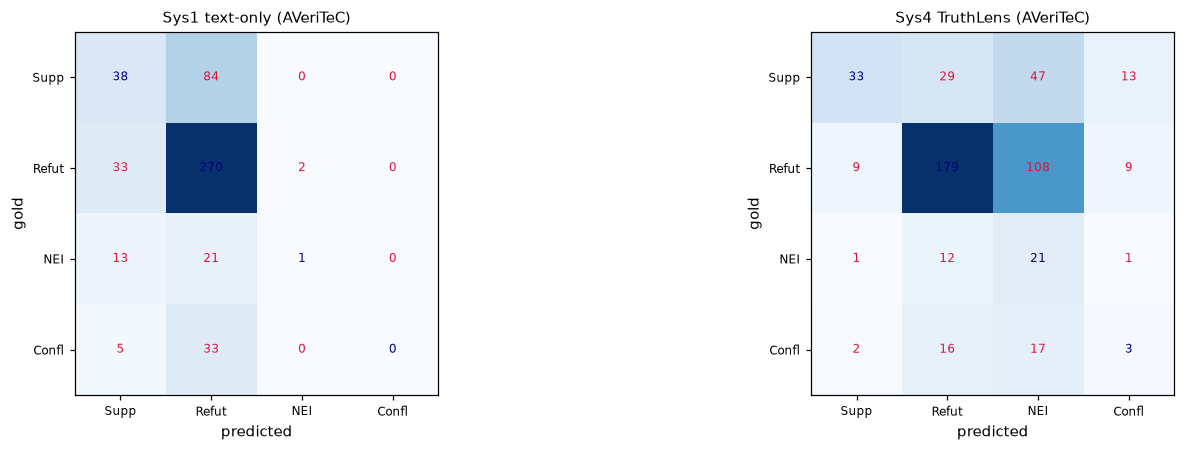

In [33]:
# ============================================================================
# 11.5 AVeriTeC - significance, per-class, India subset, confusion matrices
# ============================================================================
av_stats = dict(
    sys4_acc_ci=bootstrap_ci(av_gold, av_systems["preds"]["sys4_hybrid"], acc_metric),
    sys4_f1_ci=bootstrap_ci(av_gold, av_systems["preds"]["sys4_hybrid"], macro_f1_metric),
    mcnemar_sys4_vs_sys3=mcnemar_test(av_systems["preds"]["sys4_hybrid"], av_systems["preds"]["sys3_hybrid"], av_gold),
    mcnemar_sys4_vs_sys1=mcnemar_test(av_systems["preds"]["sys4_hybrid"], av_sys1, av_gold))
print("AVeriTeC bootstrap CIs:")
print("  Sys4 accuracy:", av_stats["sys4_acc_ci"], "| macro-F1:", av_stats["sys4_f1_ci"])
print("  McNemar Sys4 vs Sys3:", av_stats["mcnemar_sys4_vs_sys3"])
print("  McNemar Sys4 vs Sys1:", av_stats["mcnemar_sys4_vs_sys1"])
print("\nSys4 per-class report (AVeriTeC):")
print(classification_report(av_gold, av_systems["preds"]["sys4_hybrid"], labels=AV_LABELS, zero_division=0))

# India subset
in_idx = [i for i, c in enumerate(AV_DEV) if c["location"] == "IN"]
if len(in_idx) >= 10:
    in_gold = [av_gold[i] for i in in_idx]
    rows = [dict(system=name, accuracy=round(accuracy_score(in_gold, [preds[i] for i in in_idx]), 3),
                 macro_f1=round(f1_score(in_gold, [preds[i] for i in in_idx], average="macro", zero_division=0), 3))
            for name, preds in [("Sys1 text-only", av_sys1),
                                ("Sys3 top-1 NLI", av_systems["preds"]["sys3_hybrid"]),
                                ("Sys4 TruthLens", av_systems["preds"]["sys4_hybrid"])]]
    AV_INDIA_DF = pd.DataFrame(rows)
    print(f"\nIndia subset (n={len(in_idx)}):"); display(AV_INDIA_DF)
    AV_INDIA_DF.to_csv(os.path.join(OUT_DIR, "averitec_india_subset.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, (pred, title) in zip(axes, [(av_sys1, "Sys1 text-only (AVeriTeC)"),
                                    (av_systems["preds"]["sys4_hybrid"], "Sys4 TruthLens (AVeriTeC)")]):
    cm = confusion_matrix(av_gold, pred, labels=AV_LABELS)
    ax.imshow(cm, cmap="Blues")
    short = ["Supp", "Refut", "NEI", "Confl"]
    ax.set_xticks(range(4), short, fontsize=8); ax.set_yticks(range(4), short, fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="crimson" if i != j else "navy", fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_xlabel("predicted"); ax.set_ylabel("gold")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "averitec_confusion_matrices.png")); plt.show()
EXPERIMENT_REGISTRY.append(dict(experiment="AVeriTeC retrieval eval (500 claims, 7,022-doc shared corpus)",
                                status="completed", data="real (github.com/MichSchli/AVeriTeC)"))
EXPERIMENT_REGISTRY.append(dict(experiment="AVeriTeC 4-way verdict classification (500 claims, 5 systems + ablations)",
                                status="completed", data="real"))
EXPERIMENT_REGISTRY.append(dict(experiment="AVeriTeC India subset (n=59)", status="completed", data="real"))

AVeriTeC narrative metrics loaded from cache


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense encoder: multilingual MiniLM on mps (full mode)


AVeriTeC narrative clustering (real claims): {'k': 13, 'silhouette': 0.1109, 'nmi_location': 0.349, 'nmi_claim_type': 0.116, 'nmi_verdict': 0.076}


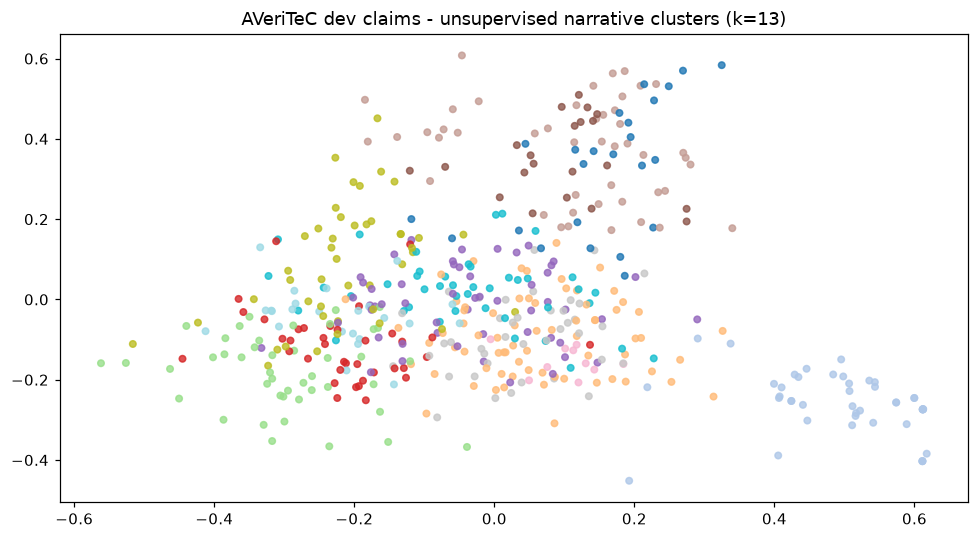

In [34]:
# ============================================================================
# 11.6 AVeriTeC - narrative clustering against real labels (NMI/silhouette)
# ============================================================================
av_narr = load_cache("averitec_narrative")
if av_narr is None:
    av_encoder2 = TextEncoder()
    av_vecs = av_encoder2.encode([c["claim"] for c in AV_DEV])
    svd = TruncatedSVD(n_components=32, random_state=SEED).fit(av_vecs)
    av_vecs_r = svd.transform(av_vecs)
    best_k, best_sil, best_labels = None, -1, None
    for k in range(2, 15):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(av_vecs_r)
        s = silhouette_score(av_vecs_r, km.labels_)
        if s > best_sil: best_k, best_sil, best_labels = k, s, km.labels_
    loc_labels = [c["location"] or "Unknown" for c in AV_DEV]
    type_labels = [c["claim_types"][0] if c["claim_types"] else "Unknown" for c in AV_DEV]
    av_narr = dict(k=best_k, silhouette=round(float(best_sil), 4),
                   nmi_location=round(normalized_mutual_info_score(loc_labels, best_labels), 3),
                   nmi_claim_type=round(normalized_mutual_info_score(type_labels, best_labels), 3),
                   nmi_verdict=round(normalized_mutual_info_score(av_gold, best_labels), 3))
    save_cache("averitec_narrative", av_narr)
    AV_CLAIM_VECS = av_vecs_r; AV_CLUSTER_LABELS = best_labels
else:
    print("AVeriTeC narrative metrics loaded from cache")
    av_encoder2 = TextEncoder()
    av_vecs = av_encoder2.encode([c["claim"] for c in AV_DEV])
    svd = TruncatedSVD(n_components=32, random_state=SEED).fit(av_vecs)
    AV_CLAIM_VECS = svd.transform(av_vecs); AV_CLUSTER_LABELS = None
    for k in range(2, 15):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(AV_CLAIM_VECS)
        if silhouette_score(AV_CLAIM_VECS, km.labels_) > (av_narr["silhouette"] - 1e-9):
            AV_CLUSTER_LABELS = km.labels_
print("AVeriTeC narrative clustering (real claims):", av_narr)
if AV_CLUSTER_LABELS is not None:
    pca = PCA(n_components=2, random_state=SEED).fit_transform(AV_CLAIM_VECS)
    plt.figure(figsize=(9, 5))
    plt.scatter(pca[:, 0], pca[:, 1], c=AV_CLUSTER_LABELS, cmap="tab20", s=18, alpha=0.8)
    plt.title(f"AVeriTeC dev claims - unsupervised narrative clusters (k={av_narr['k']})")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "averitec_narrative_clusters.png")); plt.show()
EXPERIMENT_REGISTRY.append(dict(experiment="AVeriTeC narrative clustering vs real labels (NMI location/claim-type/verdict)",
                                status="completed", data="real"))

### 11.7 Temporal robustness on real data (evidence timing vs claim date)

The synopsis asks for *temporal robustness* and *temporal/context-mismatch detection*. No public benchmark ships gold "recycled content" flags, so rather than invent labels we measure a temporal property that **is** verifiable in AVeriTeC, and we are explicit about how far the available dates let us push it.

**Where the dates come from (all real, none inferred by a model):**
- **Claim date** - AVeriTeC's own `claim_date` field, parsed for **all 500** dev claims (`D-M-YYYY`, variable padding).
- **Evidence date** - parsed from the evidence URL, in two kinds that do **not** carry the same weight:
  - **`publication`** - a date in the URL *path* (e.g. `nypost.com/2020/10/30/...`). This is the actual publication date, so it is a **two-sided** signal: it can establish that evidence pre-dates *or* post-dates a claim.
  - **`upper_bound`** - a `web.archive.org/web/<timestamp>/` snapshot. The page provably existed by then but may be much older, so it is a **one-sided** signal: it can establish pre-dating only. A snapshot taken after a claim proves nothing about when the page was written.

**The resulting three-way timing label**, used throughout: `pre` (provably existed at claim time), `post` (provably published after the claim - `publication` dates only), `unknown` (everything else). We never infer `post` from an archive snapshot; doing so would report an artefact of when the Internet Archive happened to crawl a page.

**Experiments**
- **T1 - Evidence timing characterisation.** How retrospective is AVeriTeC's evidence?
- **T2 - Verifiable-leakage ablation.** Drop only evidence that is *provably* post-claim and re-run the verdict system. This removes definite look-ahead without discarding unknowns, so it stays well-powered.
- **T3 - Strict contemporaneous bound.** Keep *only* provably-pre-dating evidence. This is deliberately reported as a **bound, not a fair system score**: as T1 shows, admissible evidence is so scarce that the system is forced to abstain on most claims. T3 therefore measures how retrospective the benchmark is, not how good the system is - and it is reported that way.

In [35]:
# ============================================================================
# 11.7a AVeriTeC temporal - parse claim dates and evidence dates (REAL data)
# ============================================================================
from datetime import date as _date

_ARCHIVE_RE = re.compile(r"web\.archive\.org/web/(\d{4})(\d{2})(\d{2})\d*/")
_PATHDATE_RE = re.compile(r"/(20\d{2})[/\-](\d{1,2})[/\-](\d{1,2})(?:[/\-]|$)")

def parse_claim_date(v):
    # AVeriTeC claim_date is D-M-YYYY with variable zero-padding (all 4 shapes occur)
    m = re.match(r"^\s*(\d{1,2})-(\d{1,2})-(\d{4})\s*$", str(v or ""))
    if not m:
        return None
    d_, m_, y_ = int(m.group(1)), int(m.group(2)), int(m.group(3))
    try:
        return _date(y_, m_, d_)
    except ValueError:
        return None

def parse_evidence_date(url):
    # (date, kind). "publication" = exact date from the URL path -> two-sided signal.
    # "upper_bound" = archive snapshot -> one-sided, can only establish pre-dating.
    if not url:
        return None, None
    tail = url.split("web.archive.org/web/")[-1]     # skip the snapshot stamp itself
    m = _PATHDATE_RE.search(tail)
    if m:
        y_, mo, dy = int(m.group(1)), int(m.group(2)), int(m.group(3))
        try:
            return _date(y_, mo, dy), "publication"
        except ValueError:
            pass
    m = _ARCHIVE_RE.search(url)
    if m:
        try:
            return _date(int(m.group(1)), int(m.group(2)), int(m.group(3))), "upper_bound"
        except ValueError:
            pass
    return None, None

AV_EV_DATE = [parse_evidence_date(d.get("source_url", "")) for d in AV_CORPUS]
AV_CLAIM_DATE = [parse_claim_date(c.get("claim_date")) for c in AV_DEV]

def evidence_timing(ev_idx, claim_dt):
    # "pre"  : provably existed at claim time (either date kind, on/before claim)
    # "post" : provably published after the claim (publication dates ONLY)
    # "unknown": undated, or an archive snapshot after the claim (proves nothing)
    if claim_dt is None:
        return "unknown"
    dt, kind = AV_EV_DATE[ev_idx]
    if dt is None:
        return "unknown"
    if (dt - claim_dt).days <= 0:
        return "pre"
    return "post" if kind == "publication" else "unknown"

n_claim_dates = sum(1 for d in AV_CLAIM_DATE if d)
n_ev_dates = sum(1 for d, k in AV_EV_DATE if d)
print(f"claim dates parsed:      {n_claim_dates}/{len(AV_DEV)}")
print(f"evidence docs with date: {n_ev_dates}/{len(AV_CORPUS)} ({n_ev_dates/len(AV_CORPUS):.1%})")
print(f"  by kind: {dict(Counter(k for _, k in AV_EV_DATE if k))}")
print("  (only 'publication' dates can establish post-dating)")

claim dates parsed:      500/500
evidence docs with date: 2954/7022 (42.1%)
  by kind: {'upper_bound': 2207, 'publication': 747}
  (only 'publication' dates can establish post-dating)


{
 "claims_considered": 437,
 "gold_evidence_items": 998,
 "pre": 90,
 "post": 16,
 "unknown": 892,
 "pct_provably_pre_dating": 9.0,
 "claims_with_no_predating_evidence": 362,
 "median_gap_days": 107,
 "pct_dated_items_after_claim": 76.1,
 "reliable_subset": {
  "claims_with_reliable_date": 80,
  "pre": 83,
  "post": 16
 }
}

Reading: AVeriTeC evidence is overwhelmingly RETROSPECTIVE - most of it was
published after the claim it is used to adjudicate. That is expected for a
fact-checking corpus, and it is exactly what T2/T3 below quantify the effect of.


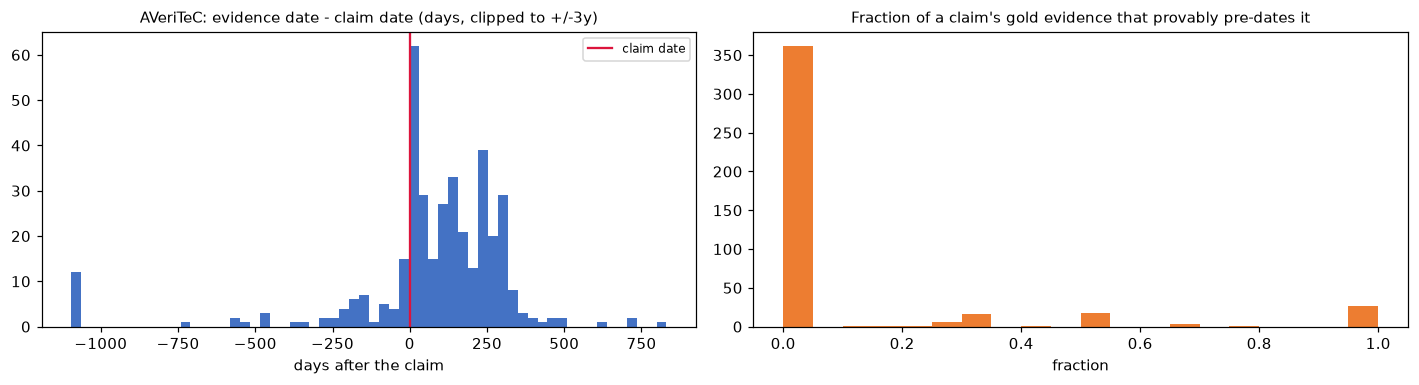

In [36]:
# ============================================================================
# 11.7b T1 - evidence timing characterisation (descriptive, real)
# ============================================================================
gaps, timing_counts, per_claim_frac = [], Counter(), []
reliable_pre = reliable_post = 0
claims_with_reliable = 0
for ci, c in enumerate(AV_DEV):
    cd = AV_CLAIM_DATE[ci]
    ev = c["evidence_ids"]
    if not ev:
        continue
    n_pre = 0
    n_reliable = 0
    for e in ev:
        t = evidence_timing(e, cd)
        timing_counts[t] += 1
        n_pre += (t == "pre")
        dt, kind = AV_EV_DATE[e]
        if dt and cd:
            gaps.append((dt - cd).days)
            if kind == "publication":
                n_reliable += 1
                if (dt - cd).days <= 0: reliable_pre += 1
                else:                   reliable_post += 1
    claims_with_reliable += (n_reliable > 0)
    per_claim_frac.append(n_pre / len(ev))

_tot = sum(timing_counts.values())
AV_TEMPORAL_T1 = dict(
    claims_considered=len(per_claim_frac),
    gold_evidence_items=_tot,
    pre=timing_counts["pre"], post=timing_counts["post"], unknown=timing_counts["unknown"],
    pct_provably_pre_dating=round(100 * timing_counts["pre"] / max(1, _tot), 1),
    claims_with_no_predating_evidence=sum(1 for f in per_claim_frac if f == 0),
    median_gap_days=int(np.median(gaps)) if gaps else None,
    pct_dated_items_after_claim=round(100 * float(np.mean([g > 0 for g in gaps])), 1) if gaps else None,
    reliable_subset=dict(claims_with_reliable_date=claims_with_reliable,
                         pre=reliable_pre, post=reliable_post))
print(json.dumps(AV_TEMPORAL_T1, indent=1))
with open(os.path.join(OUT_DIR, "averitec_temporal_characterisation.json"), "w") as f:
    json.dump(AV_TEMPORAL_T1, f, indent=1)
print("\nReading: AVeriTeC evidence is overwhelmingly RETROSPECTIVE - most of it was")
print("published after the claim it is used to adjudicate. That is expected for a")
print("fact-checking corpus, and it is exactly what T2/T3 below quantify the effect of.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
if gaps:
    axes[0].hist(np.clip(gaps, -365 * 3, 365 * 3), bins=60, color="#4472c4")
    axes[0].axvline(0, color="crimson", lw=1.5, label="claim date")
    axes[0].set_title("AVeriTeC: evidence date - claim date (days, clipped to +/-3y)", fontsize=10)
    axes[0].set_xlabel("days after the claim"); axes[0].legend(fontsize=8)
axes[1].hist(per_claim_frac, bins=20, color="#ed7d31")
axes[1].set_title("Fraction of a claim's gold evidence that provably pre-dates it", fontsize=10)
axes[1].set_xlabel("fraction")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "averitec_temporal_characterisation.png")); plt.show()
EXPERIMENT_REGISTRY.append(dict(
    experiment="AVeriTeC T1 evidence-timing characterisation (500 claims, URL-derived dates)",
    status="completed", data="real"))

In [37]:
# ============================================================================
# 11.7c T2/T3 - temporal ablations on the verdict system
#   A unrestricted            : the usual top-5
#   B no verifiable leakage   : drop provably post-claim evidence (T2)
#   C strict contemporaneous  : keep only provably pre-claim evidence (T3, a BOUND)
# ============================================================================
av_temporal = load_cache("averitec_temporal")
if av_temporal is None:
    if not TRANSFORMERS_OK:
        raise RuntimeError("Temporal ablation requires full mode (transformer NLI).")
    try:
        av_retriever
    except NameError:
        av_retriever = HybridRetriever(
            [dict(id=str(i), text=d["text"]) for i, d in enumerate(AV_CORPUS)],
            TextEncoder(), fit_texts=[c["claim"] for c in AV_DEV], cache_key="averitec")
    judge_t = NLIJudge(av_retriever.encoder)
    POOL_K, TOP_K_T = 30, 5        # deeper pool, filter it, then keep 5
    preds = dict(A=[], B=[], C=[])
    kept = dict(B=[], C=[])
    t0 = _time.time()
    for ci, c in enumerate(AV_DEV):
        cd = AV_CLAIM_DATE[ci]
        pool = av_retriever.search(c["claim"], k=POOL_K, mode="hybrid")
        tags = [evidence_timing(int(r["id"]), cd) for r in pool]
        sel = dict(
            A=pool[:TOP_K_T],
            B=[r for r, t in zip(pool, tags) if t != "post"][:TOP_K_T],
            C=[r for r, t in zip(pool, tags) if t == "pre"][:TOP_K_T])
        kept["B"].append(len(sel["B"])); kept["C"].append(len(sel["C"]))
        for cond, evs in sel.items():
            if not evs:
                preds[cond].append("Not Enough Evidence")   # nothing admissible -> abstain
                continue
            js = judge_t.judge_many(c["claim"], [e["text"] for e in evs])
            v, _ = aggregate_verdict([(l, pr, i) for i, (l, pr) in enumerate(js)],
                                     use_conflict=True)
            preds[cond].append(v)
    av_temporal = dict(preds=preds, kept=kept, pool_k=POOL_K, top_k=TOP_K_T)
    print(f"temporal ablation: {_time.time()-t0:.0f}s for {len(AV_DEV)} claims x 3 conditions")
    save_cache("averitec_temporal", av_temporal)
else:
    print("AVeriTeC temporal ablation loaded from cache")

_p, _k = av_temporal["preds"], av_temporal["kept"]
_n = len(AV_DEV)
print(f"admissible evidence within the top-{av_temporal['pool_k']} pool "
      f"(target {av_temporal['top_k']}):")
print(f"  B no-leakage      mean {np.mean(_k['B']):.2f} | claims with none: {sum(1 for x in _k['B'] if x == 0)}/{_n}")
print(f"  C contemporaneous mean {np.mean(_k['C']):.2f} | claims with none: {sum(1 for x in _k['C'] if x == 0)}/{_n}"
      f"   <-- forced abstentions make C a bound, not a score")

def _row(name, pred):
    return dict(condition=name,
                accuracy=round(accuracy_score(av_gold, pred), 3),
                macro_f1=round(f1_score(av_gold, pred, average="macro", zero_division=0), 3))

AV_TEMPORAL_DF = pd.DataFrame([
    _row("Sys1 text-only (no evidence, timing-invariant)", av_sys1),
    # NB: A is recomputed here from a depth-30 pool (so B and C have something to
    # filter), then truncated to 5. RRF fuses over a different BM25 candidate set at
    # depth 30 than at depth 5, so A differs very slightly from the Sys4 row in 11.4.
    # A is the correct internal control for B and C; 11.4 remains the headline number.
    _row("A  Sys4 unrestricted evidence (depth-30 pool)", _p["A"]),
    _row("B  Sys4 minus provably post-claim evidence (T2)", _p["B"]),
    _row("C  Sys4 provably contemporaneous only (T3, BOUND)", _p["C"]),
])
display(AV_TEMPORAL_DF)
AV_TEMPORAL_DF.to_csv(os.path.join(OUT_DIR, "averitec_temporal_robustness.csv"), index=False)

print(f"\nT2 effect (A -> B), the cost of removing verifiable look-ahead: "
      f"{AV_TEMPORAL_DF.loc[2,'accuracy'] - AV_TEMPORAL_DF.loc[1,'accuracy']:+.3f} accuracy")
print("   McNemar A vs B:", mcnemar_test(_p["A"], _p["B"], av_gold))
print(f"T3 bound  (A -> C): {AV_TEMPORAL_DF.loc[3,'accuracy'] - AV_TEMPORAL_DF.loc[1,'accuracy']:+.3f} accuracy")
print("   McNemar A vs C:", mcnemar_test(_p["A"], _p["C"], av_gold))
print("\nCaveat, stated plainly: date coverage limits both tests. Only 'publication'-kind")
print("URLs can prove post-dating, so T2 removes only the leakage we can PROVE, and the")
print("true look-ahead advantage is at least this large. T3 is dominated by forced")
print("abstentions and is reported as a bound on contemporaneous verification, not as a")
print("system score.")
EXPERIMENT_REGISTRY.append(dict(
    experiment="AVeriTeC T2/T3 temporal ablations (leakage removal + contemporaneous bound, 500 claims)",
    status="completed", data="real"))

AVeriTeC temporal ablation loaded from cache
admissible evidence within the top-30 pool (target 5):
  B no-leakage      mean 5.00 | claims with none: 0/500
  C contemporaneous mean 3.83 | claims with none: 14/500   <-- forced abstentions make C a bound, not a score


,condition,accuracy,macro_f1
0,"Sys1 text-only (no evidence, timing-invariant)",0.618,0.293
1,A Sys4 unrestricted evidence (depth-30 pool),0.466,0.332
2,B Sys4 minus provably post-claim evidence (T2),0.462,0.329
3,"C Sys4 provably contemporaneous only (T3, BOUND)",0.308,0.213



T2 effect (A -> B), the cost of removing verifiable look-ahead: -0.004 accuracy
   McNemar A vs B: {'b': 2, 'c': 0, 'chi2': 0.5, 'p': 0.4795}
T3 bound  (A -> C): -0.158 accuracy
   McNemar A vs C: {'b': 110, 'c': 31, 'chi2': 43.149, 'p': 0.0}

Caveat, stated plainly: date coverage limits both tests. Only 'publication'-kind
URLs can prove post-dating, so T2 removes only the leakage we can PROVE, and the
true look-ahead advantage is at least this large. T3 is dominated by forced
abstentions and is reported as a bound on contemporaneous verification, not as a
system score.


### 11.8 Evidence graph and source provenance on real data

Parts 6 and 11.7 covered the evidence graph and temporal layer on the demonstration corpus. AVeriTeC lets both be built from **real** provenance: every evidence document carries a `source_url` and `source_medium`, and every claim carries a date, so the synopsis's `claim ↔ evidence ↔ source ↔ date` graph can be instantiated without inventing anything.

This also addresses a risk the synopsis raises explicitly - *"web retrieval can introduce source bias, missing evidence and duplicate reporting; source diversity and provenance must be evaluated"*. Source concentration is measured here rather than assumed.

AVeriTeC evidence graph: 1974 nodes / 1974 edges
  {'claim': 500, 'evidence': 986, 'source': 488}
{
 "evidence_links": 998,
 "distinct_domains": 488,
 "top1_domain": "(no source url)",
 "top1_share": 5.8,
 "top10_share": 19.0,
 "mean_evidence_per_claim": 2.28,
 "mean_distinct_sources_per_claim": 1.79,
 "claims_resting_on_a_single_source": 207,
 "pct_claims_single_source": 47.4,
 "medium_distribution": {
  "Web text": 792,
  "PDF": 77,
  "Metadata": 57,
  "Web table": 29,
  "Image/graphic": 20,
  "Other": 13,
  "Video": 10
 }
}


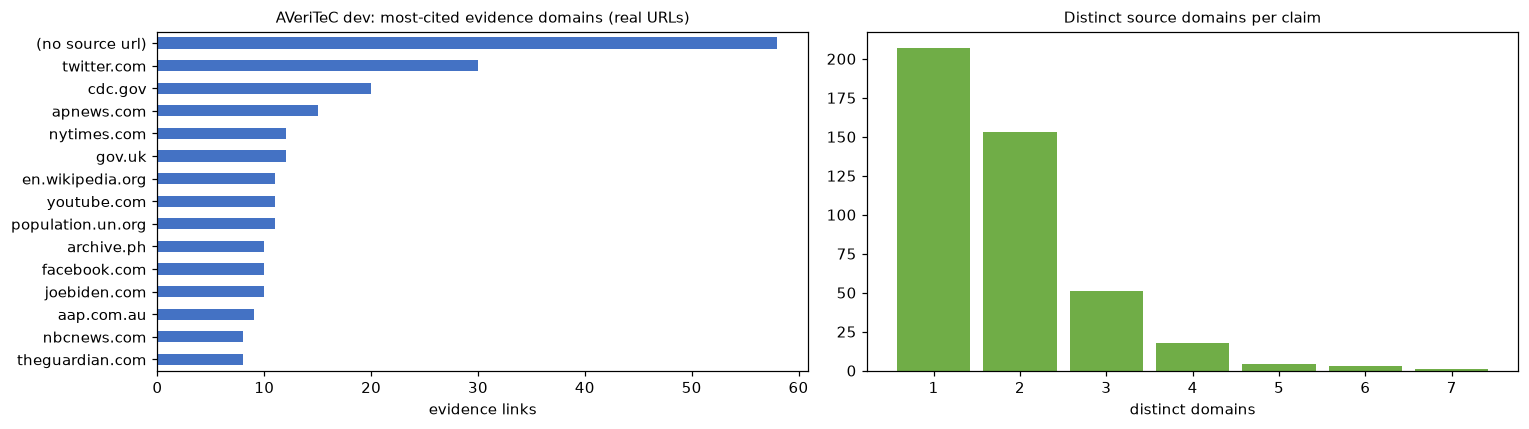

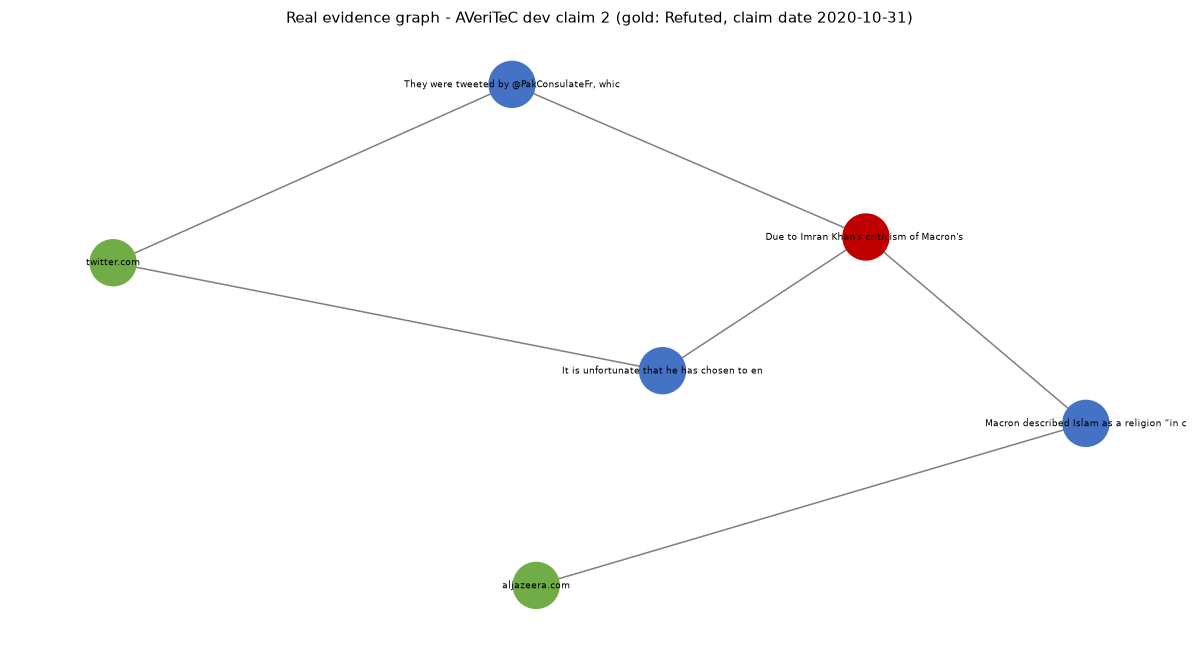


full graph exported to averitec_evidence_graph.gexf (1974 nodes) - openable in Gephi


In [38]:
# ============================================================================
# 11.8 Real evidence graph over AVeriTeC + source-provenance statistics
# ============================================================================
import networkx as nx          # explicit: do not depend on the Part 6 demo cell
from urllib.parse import urlparse

def source_domain(url):
    # Unwrap Internet Archive URLs so the ORIGINAL publisher is the node, not
    # "web.archive.org" -- otherwise every archived source collapses into one.
    if not url:
        return "unknown"
    u = url
    if "web.archive.org/web/" in u:
        tail = u.split("web.archive.org/web/", 1)[1]
        slash = tail.find("/")
        if slash >= 0:
            u = tail[slash + 1:]
    if not u.startswith("http"):
        u = "http://" + u
    try:
        host = urlparse(u).netloc.lower()
    except ValueError:
        return "(no source url)"
    if host.startswith("www."):
        host = host[4:]
    # AVeriTeC stores a literal placeholder (e.g. "metadata") rather than a URL for
    # some evidence -- notably Metadata-medium answers. Those parse to a dotless
    # "host" and must not be counted as the most-cited publisher.
    if not host or "." not in host:
        return "(no source url)"
    return host

AV_EV_DOMAIN = [source_domain(d.get("source_url", "")) for d in AV_CORPUS]

G = nx.DiGraph()
for ci, c in enumerate(AV_DEV):
    cnode = f"claim::{ci}"
    # NB: GEXF cannot serialise None, so every optional attribute defaults to ""
    G.add_node(cnode, kind="claim", label=c["claim"][:80], verdict=c["label"],
               date=str(AV_CLAIM_DATE[ci]) if AV_CLAIM_DATE[ci] else "",
               location=c.get("location") or "")
    for e in c["evidence_ids"]:
        enode = f"ev::{e}"
        if enode not in G:
            dt, kind = AV_EV_DATE[e]
            G.add_node(enode, kind="evidence", label=AV_CORPUS[e]["text"][:80],
                       date=str(dt) if dt else "", date_kind=kind or "",
                       medium=AV_CORPUS[e].get("source_medium") or "")
        snode = f"src::{AV_EV_DOMAIN[e]}"
        if snode not in G:
            G.add_node(snode, kind="source", label=AV_EV_DOMAIN[e])
        G.add_edge(cnode, enode, rel="has_evidence")
        G.add_edge(enode, snode, rel="published_by")
        if AV_CLAIM_DATE[ci]:
            G.add_edge(cnode, enode, rel="has_evidence",
                       timing=evidence_timing(e, AV_CLAIM_DATE[ci]))

kinds = Counter(d["kind"] for _, d in G.nodes(data=True))
print(f"AVeriTeC evidence graph: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges")
print(f"  {dict(kinds)}")

# ---- source provenance / concentration --------------------------------------
used_domains = [AV_EV_DOMAIN[e] for c in AV_DEV for e in c["evidence_ids"]]
dom_counts = Counter(used_domains)
n_links = len(used_domains)
top = dom_counts.most_common(15)
srcs_per_claim = [len({AV_EV_DOMAIN[e] for e in c["evidence_ids"]})
                  for c in AV_DEV if c["evidence_ids"]]
evs_per_claim = [len(c["evidence_ids"]) for c in AV_DEV if c["evidence_ids"]]
single_source = sum(1 for s in srcs_per_claim if s == 1)

AV_PROVENANCE = dict(
    evidence_links=n_links,
    distinct_domains=len(dom_counts),
    top1_domain=top[0][0], top1_share=round(100 * top[0][1] / n_links, 1),
    top10_share=round(100 * sum(n for _, n in dom_counts.most_common(10)) / n_links, 1),
    mean_evidence_per_claim=round(float(np.mean(evs_per_claim)), 2),
    mean_distinct_sources_per_claim=round(float(np.mean(srcs_per_claim)), 2),
    claims_resting_on_a_single_source=single_source,
    pct_claims_single_source=round(100 * single_source / len(srcs_per_claim), 1),
    medium_distribution=dict(Counter(
        (AV_CORPUS[e].get("source_medium") or "unknown")
        for c in AV_DEV for e in c["evidence_ids"]).most_common()))
print(json.dumps(AV_PROVENANCE, indent=1))
with open(os.path.join(OUT_DIR, "averitec_provenance.json"), "w") as f:
    json.dump(AV_PROVENANCE, f, indent=1)
pd.DataFrame(top, columns=["domain", "evidence_links"]).to_csv(
    os.path.join(OUT_DIR, "averitec_top_sources.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(dict(top[::-1])).plot.barh(ax=axes[0], color="#4472c4")
axes[0].set_title("AVeriTeC dev: most-cited evidence domains (real URLs)", fontsize=10)
axes[0].set_xlabel("evidence links")
axes[1].hist(srcs_per_claim, bins=range(1, max(srcs_per_claim) + 2), color="#70ad47",
             align="left", rwidth=0.85)
axes[1].set_title("Distinct source domains per claim", fontsize=10)
axes[1].set_xlabel("distinct domains")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "averitec_source_provenance.png")); plt.show()

# ---- draw one real claim's neighbourhood ------------------------------------
_cand = [ci for ci, c in enumerate(AV_DEV)
         if len({AV_EV_DOMAIN[e] for e in c["evidence_ids"]}) >= 2]
if _cand:
    ci = _cand[0]
    sub_nodes = {f"claim::{ci}"}
    for e in AV_DEV[ci]["evidence_ids"]:
        sub_nodes.add(f"ev::{e}"); sub_nodes.add(f"src::{AV_EV_DOMAIN[e]}")
    H = G.subgraph(sub_nodes)
    colors = {"claim": "#c00000", "evidence": "#4472c4", "source": "#70ad47"}
    pos = nx.spring_layout(H, seed=SEED, k=1.1)
    plt.figure(figsize=(11, 6))
    nx.draw_networkx_nodes(H, pos, node_size=900,
                           node_color=[colors[H.nodes[n]["kind"]] for n in H])
    nx.draw_networkx_edges(H, pos, alpha=0.5, arrowsize=11)
    nx.draw_networkx_labels(H, pos, font_size=6,
                            labels={n: (H.nodes[n].get("label") or n)[:42] for n in H})
    plt.title(f"Real evidence graph - AVeriTeC dev claim {ci} "
              f"(gold: {AV_DEV[ci]['label']}, claim date {AV_CLAIM_DATE[ci]})", fontsize=10)
    plt.axis("off"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "averitec_evidence_graph_example.png")); plt.show()

nx.write_gexf(G, os.path.join(OUT_DIR, "averitec_evidence_graph.gexf"))
print(f"\nfull graph exported to averitec_evidence_graph.gexf "
      f"({G.number_of_nodes()} nodes) - openable in Gephi")
EXPERIMENT_REGISTRY.append(dict(
    experiment="AVeriTeC real evidence graph + source-provenance analysis "
               "(500 claims, real URLs/domains/dates)",
    status="completed", data="real"))

## 12. REAL EXPERIMENT C - FactDrill (Indian fact-checked content, EN + HI)

**Dataset:** FactDrill [4] - 22,435 fact-checked social-media items from Indian fact-checking organizations (2013-2020), covering 13 languages. Obtained from the official Zenodo deposit (DOI 10.5281/zenodo.5854856). We downloaded the 17 English/Hindi organization files (13,796 items; 8,732 EN + 5,064 HI) - all files that were needed for the paper's language scope.

**What FactDrill supports here:**
- **(a) Real dataset characterization** for the Indian multilingual context (items per organization, language, time).
- **(b) Claim-to-fact-check retrieval** - given the claim text, retrieve its own fact-check article from a corpus of 13,796 real articles. This evaluates the retrieval layer (BM25 / dense / hybrid) on real Indian-domain claims in **English and Hindi separately**.

  **Protocol warning discovered during Phase 1, and handled rather than ignored.** In this deposit the `claim` column is largely *extracted from* the article `content`. Measured over all 13,788 items with a claim of at least 30 characters: the claim's first 120 characters occur verbatim in its own article for **89.8%** of items (68.7% as an exact prefix). Retrieving an article from a query that is a substring of it is duplicate detection, not evidence retrieval, and would produce a near-perfect hit@5 that means nothing. Part 12.2 therefore reports two settings - **leaky** (corpus as-is, kept only to make the inflation visible) and **de-leaked** (the claim span removed from its own gold article, so the match must be made against the fact-check's analysis text). **The de-leaked numbers are the result; the leaky numbers are an artefact.**

**What FactDrill does NOT support (documented limitation):** the deposit has **no structured verdict-label column**; verdicts are embedded in free text (titles like "False: ...", investigation summaries). Deriving labels from text patterns would amount to constructing labels heuristically, so **verdict classification is not run on FactDrill** in Phase 1. Exact steps to extend: manual annotation of a label sample (protocol in Part 14).

FactDrill items: 13796 | evidence articles: 13796


,site,items
0,alt_news_english,2079
1,alt_news_hindi,1758
2,newsmobile_english,1543
3,webqoof_english,1496
4,vishwas_hindi,1369
5,factly_english,971
6,boom_english,909
7,boom_hindi,791
8,india_today_english,788
9,newschecker_hindi,556


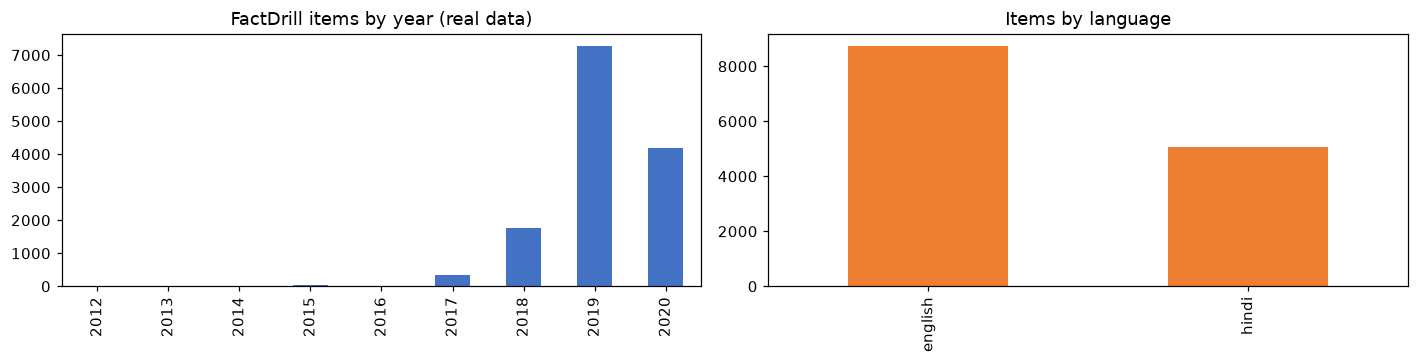

years: {2012: 2, 2013: 5, 2014: 10, 2015: 26, 2016: 17, 2017: 345, 2018: 1758, 2019: 7269, 2020: 4193}


In [39]:
# ============================================================================
# 12.1 FactDrill - load + real dataset characterization
# ============================================================================
FD_REC_PATH = os.path.join(DATA_DIR, "factdrill_records.jsonl")
FD_CORPUS_PATH = os.path.join(DATA_DIR, "factdrill_corpus.jsonl")
for p in [FD_REC_PATH, FD_CORPUS_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError("FactDrill prepared data missing - see acquisition steps in Part 14.")
FD_RECORDS = [json.loads(l) for l in open(FD_REC_PATH, encoding="utf-8")]
FD_CORPUS = [json.loads(l) for l in open(FD_CORPUS_PATH, encoding="utf-8")]
print(f"FactDrill items: {len(FD_RECORDS)} | evidence articles: {len(FD_CORPUS)}")
fd_by_lang = Counter(r["lang"] for r in FD_RECORDS)
fd_by_site = Counter(r["site"] for r in FD_RECORDS)
display(pd.DataFrame(fd_by_site.most_common(), columns=["site", "items"]))
years = Counter()
for r in FD_RECORDS:
    m = re.search(r"\d{4}", r["publish_date"] or "")
    if m: years[int(m.group())] += 1
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
pd.Series(dict(sorted(years.items()))).plot.bar(ax=axes[0], color="#4472c4", title="FactDrill items by year (real data)")
pd.Series(dict(fd_by_lang)).plot.bar(ax=axes[1], color="#ed7d31", title="Items by language")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "factdrill_stats.png")); plt.show()
print("years:", dict(sorted(years.items())))
EXPERIMENT_REGISTRY.append(dict(experiment="FactDrill dataset characterization (13,796 real items, EN+HI)",
                                status="completed", data="real (Zenodo 10.5281/zenodo.5854856)"))

In [40]:
# ============================================================================
# 12.2 FactDrill - claim-to-fact-check retrieval, EN and HI
#
# CRITICAL PROTOCOL NOTE. In the FactDrill deposit the `claim` column is largely
# *extracted from* the article `content`: measured on all 13,788 items with a
# claim of >=30 chars, the claim's first 120 characters appear verbatim in the
# article for 89.8% of items (68.7% as an exact prefix). Retrieving the article
# from its own claim is therefore mostly duplicate detection, not evidence
# retrieval, and a hit@5 near 1.0 would say nothing about the retriever.
#
# We therefore report TWO settings:
#   (leaky)    corpus as-is                     -- a trivial upper bound, kept only
#                                                  so the inflation is visible
#   (de-leaked) claim span removed from its own -- the real task: match a claim to
#              gold article                        the fact-check's *analysis* text
# ============================================================================
def _norm_ws(s):
    return " ".join(s.lower().split())

def strip_claim_from_article(claim, text, min_len=40):
    # Remove the claim span from its own article so retrieval cannot win by
    # spotting a verbatim copy. Matching is whitespace/case-insensitive; we locate
    # the span on the normalised text and cut the corresponding slice of the raw text.
    if not claim or len(claim) < min_len:
        return text
    n_claim, n_text = _norm_ws(claim), _norm_ws(text)
    # Prefer an exact full-claim match. Only if that fails do we fall back to a
    # 200-char probe -- and then we remove ONLY the probe, never the full claim
    # length. Cutting len(n_claim) after matching just a prefix would delete
    # unrelated article text and fake a de-leak.
    pos = n_text.find(n_claim)
    match_len = len(n_claim)
    if pos < 0:
        probe = n_claim[:200]
        pos = n_text.find(probe)
        if pos < 0:
            return text
        match_len = len(probe)
    # map normalised offsets back to raw offsets by walking both strings
    raw_start = raw_end = None
    ni = 0
    prev_space = True
    for ri, ch in enumerate(text):
        if ch.isspace():
            if prev_space:
                continue
            prev_space = True
            ni += 1                      # one normalised space
        else:
            prev_space = False
            ni += 1
        if raw_start is None and ni > pos:
            raw_start = ri
        if ni >= pos + match_len:
            raw_end = ri + 1
            break
    if raw_start is None:
        return text
    if raw_end is None:
        raw_end = len(text)
    out = (text[:raw_start] + " " + text[raw_end:]).strip()
    return out if len(out) >= 100 else text     # never empty a document

FD_SETTINGS = {}
FD_SETTINGS["leaky"] = [dict(id=d["id"], text=d["text"]) for d in FD_CORPUS]
FD_SETTINGS["de_leaked"] = [
    dict(id=d["id"], text=strip_claim_from_article(FD_RECORDS[i]["claim"], d["text"]))
    for i, d in enumerate(FD_CORPUS)]

_removed = sum(1 for a, b in zip(FD_SETTINGS["leaky"], FD_SETTINGS["de_leaked"])
               if len(b["text"]) < len(a["text"]))
print(f"de-leaking: claim span removed from {_removed}/{len(FD_CORPUS)} articles "
      f"({_removed/len(FD_CORPUS):.1%})")
print(f"  mean article length {np.mean([len(d['text']) for d in FD_SETTINGS['leaky']]):.0f} "
      f"-> {np.mean([len(d['text']) for d in FD_SETTINGS['de_leaked']]):.0f} chars")

fd_cache = load_cache("factdrill_retrieval")
if fd_cache is None or "by_setting" not in fd_cache:
    fd_cache = dict(by_setting={})
    for setting, docs in FD_SETTINGS.items():
        print(f"\n--- FactDrill retrieval [{setting}] ---", flush=True)
        fd_retriever = HybridRetriever(docs, TextEncoder(),   # multilingual MiniLM for Hindi
                                       cache_key=f"factdrill_{setting}")
        random.seed(SEED)
        fd_cache["by_setting"][setting] = {}
        for lang in ["english", "hindi"]:
            # records[i] <-> FD_CORPUS[i] (built in the same loop in prep_factdrill.py)
            pool_idx = [i for i, r in enumerate(FD_RECORDS)
                        if r["lang"] == lang and len(r["claim"]) >= 30]
            random.shuffle(pool_idx)
            query_idx = pool_idx[:400]
            per_mode = {}
            for mode in ["bm25", "dense", "hybrid"]:
                hits = []
                for qi in query_idx:
                    gold_id = f"FD{qi:05d}"
                    top = [x["id"] for x in
                           fd_retriever.search(FD_RECORDS[qi]["claim"], k=5, mode=mode)]
                    hits.append(1 if gold_id in top else 0)
                per_mode[mode] = dict(hit_rate_at_5=round(float(np.mean(hits)), 4),
                                      n_queries=len(query_idx))
                print(f"  [{lang:7s}] {mode:6s} hit@5 = {per_mode[mode]['hit_rate_at_5']}", flush=True)
            fd_cache["by_setting"][setting][lang] = per_mode
    save_cache("factdrill_retrieval", fd_cache)
else:
    print("FactDrill retrieval eval loaded from cache")

FD_ROWS = []
for setting, langs in fd_cache["by_setting"].items():
    for lang, modes in langs.items():
        for mode, m in modes.items():
            FD_ROWS.append(dict(setting=setting, language=lang, mode=mode,
                                hit_rate_at_5=m["hit_rate_at_5"], n_queries=m["n_queries"]))
FD_RETRIEVAL = pd.DataFrame(FD_ROWS)
FD_RETRIEVAL.to_csv(os.path.join(OUT_DIR, "factdrill_retrieval_eval.csv"), index=False)
display(FD_RETRIEVAL.pivot_table(index=["setting", "mode"], columns="language",
                                 values="hit_rate_at_5"))
print("\nThe de-leaked rows are the reportable result. The leaky rows are the")
print("inflation you get for free when the query is a substring of the target.")
print("Language comparison (EN vs HI) is the real multilingual finding: the same")
print("retriever, the same corpus construction, only the language differs.")
EXPERIMENT_REGISTRY.append(dict(
    experiment="FactDrill claim-to-fact-check retrieval, leaky vs de-leaked, EN+HI "
               "(800 real claims/setting, 13,796-doc corpus)",
    status="completed", data="real (Zenodo 10.5281/zenodo.5854856)"))

de-leaking: claim span removed from 11960/13796 articles (86.7%)
  mean article length 2584 -> 1900 chars

--- FactDrill retrieval [leaky] ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense encoder: multilingual MiniLM on mps (full mode)


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

  encoded 13796 docs in 64s


...

  [hindi  ] bm25   hit@5 = 0.66


  [hindi  ] dense  hit@5 = 0.3875


  [hindi  ] hybrid hit@5 = 0.67


language          english   hindi
setting   mode                   
de_leaked bm25     0.8250  0.6600
          dense    0.4700  0.3875
          hybrid   0.7650  0.6700
leaky     bm25     1.0000  0.9925
          dense    0.9725  0.8775
          hybrid   0.9900  0.9800


The de-leaked rows are the reportable result. The leaky rows are the
inflation you get for free when the query is a substring of the target.
Language comparison (EN vs HI) is the real multilingual finding: the same
retriever, the same corpus construction, only the language differs.


## 13. Consolidated Results and Experiment Registry

Cross-dataset summary of the real experiments (accuracy / macro-F1 on verdict classification; retrieval quality at k=5), followed by the registry of every experiment run in Phase 1.

In [41]:
# ============================================================================
# 13.1 Cross-dataset consolidated results + experiment registry (real data only)
# ============================================================================
CONSOLIDATED = pd.concat([FEVER_SYSTEMS_DF, AV_SYSTEMS_DF], ignore_index=True)
CONSOLIDATED.to_csv(os.path.join(OUT_DIR, "consolidated_system_eval.csv"), index=False)
print("=== Verdict classification (real datasets) ===")
display(CONSOLIDATED.pivot_table(index="system", columns="dataset",
                                 values=["accuracy", "macro_f1"], aggfunc="first"))
print("\n=== Evidence retrieval (real datasets, Recall@5 / Precision@5 / Evidence-F1@5) ===")
# Keep the setting and mode labels: a retrieval number is meaningless without
# the size and composition of the corpus it was measured against.
_av_ret = AV_RETRIEVAL.reset_index().rename(columns={"index": "mode"})
_av_ret["dataset"] = "AVeriTeC"; _av_ret["setting"] = "qa_evidence_shared_corpus"
_av_ret["n_docs"] = len(AV_CORPUS)
_fe_ret = FEVER_RETRIEVAL.copy(); _fe_ret["dataset"] = "FEVER"
_cols = ["dataset", "setting", "n_docs", "mode",
         "recall_at_5", "precision_at_5", "evidence_f1_at_5"]
RETRIEVAL_ALL = pd.concat([_fe_ret[_cols], _av_ret[_cols]], ignore_index=True)
display(RETRIEVAL_ALL)
RETRIEVAL_ALL.to_csv(os.path.join(OUT_DIR, "consolidated_retrieval_eval.csv"), index=False)

print("\n=== FactDrill claim-to-fact-check retrieval (hit@5, real Indian claims) ===")
print("    'de_leaked' is the reportable setting; 'leaky' is the trivial upper bound.")
display(FD_RETRIEVAL.pivot_table(index=["setting", "mode"], columns="language",
                                 values="hit_rate_at_5"))

print("\n=== Temporal robustness (AVeriTeC, Part 11.7) ===")
try:
    display(AV_TEMPORAL_DF)
except NameError:
    print("  (not run in this kernel)")

print("\n=== EXPERIMENT REGISTRY (Phase 1) ===")
for i, e in enumerate(EXPERIMENT_REGISTRY, 1):
    print(f"{i:02d}. [{e['status']:9s}] {e['experiment']}  ({e['data']})")
with open(os.path.join(OUT_DIR, "experiment_registry.json"), "w", encoding="utf-8") as f:
    json.dump(EXPERIMENT_REGISTRY, f, indent=1)

=== Verdict classification (real datasets) ===


accuracy        macro_f1       
dataset                                     AVeriTeC  FEVER AVeriTeC  FEVER
system                                                                     
Sys-Maj majority class (Refuted)               0.610    NaN    0.189    NaN
Sys-Maj majority class (Supported)               NaN  0.333      NaN  0.167
Sys0 Binary text-only                          0.730  0.518    0.595  0.518
Sys1 Text-only classifier                      0.618  0.440    0.293  0.421
Sys2 Retrieval + surface heuristic (no NLI)    0.212  0.540    0.176  0.504
Sys3 (bm25)                                    0.314  0.673    0.241  0.675
Sys3 (dense)                                   0.310  0.652    0.242  0.654
Sys3 Retrieval+NLI top-1                       0.324  0.660    0.252  0.663
Sys4 TruthLens full                              NaN  0.723      NaN  0.722
Sys4 TruthLens full (conflict-aware)           0.472    NaN    0.334    NaN
Sys4 ablation (bm25-only)                      0.434  0.710    0.312  0.712
Sys4 ablation (dense-only)                     0.484  0.667    0.342  0.669
Sys4 ablation: no conflict label               0.498    NaN    0.331    NaN


=== Evidence retrieval (real datasets, Recall@5 / Precision@5 / Evidence-F1@5) ===


,dataset,setting,n_docs,mode,recall_at_5,precision_at_5,evidence_f1_at_5
0,FEVER,gold_pages_only,6934,bm25,0.7637,0.2121,0.3097
1,FEVER,gold_pages_only,6934,dense,0.7242,0.1995,0.2925
2,FEVER,gold_pages_only,6934,hybrid,0.7877,0.2207,0.3209
3,FEVER,expanded,207089,bm25,0.6267,0.1602,0.2427
4,FEVER,expanded,207089,dense,0.5901,0.1547,0.2314
5,FEVER,expanded,207089,hybrid,0.6695,0.1773,0.2637
6,AVeriTeC,qa_evidence_shared_corpus,7022,bm25,0.3976,0.1680,0.2193
7,AVeriTeC,qa_evidence_shared_corpus,7022,dense,0.4106,0.1657,0.2203
8,AVeriTeC,qa_evidence_shared_corpus,7022,hybrid,0.4148,0.1753,0.2289



=== FactDrill claim-to-fact-check retrieval (hit@5, real Indian claims) ===
    'de_leaked' is the reportable setting; 'leaky' is the trivial upper bound.


language          english   hindi
setting   mode                   
de_leaked bm25     0.8250  0.6600
          dense    0.4700  0.3875
          hybrid   0.7650  0.6700
leaky     bm25     1.0000  0.9925
          dense    0.9725  0.8775
          hybrid   0.9900  0.9800


=== Temporal robustness (AVeriTeC, Part 11.7) ===


,condition,accuracy,macro_f1
0,"Sys1 text-only (no evidence, timing-invariant)",0.618,0.293
1,A Sys4 unrestricted evidence (depth-30 pool),0.466,0.332
2,B Sys4 minus provably post-claim evidence (T2),0.462,0.329
3,"C Sys4 provably contemporaneous only (T3, BOUND)",0.308,0.213



=== EXPERIMENT REGISTRY (Phase 1) ===
01. [completed] FEVER retrieval eval (BM25/dense/hybrid, 397 gold-evidence claims)  (real (fever.ai))
02. [completed] FEVER verdict classification (600 claims, 5 systems + ablations)  (real (fever.ai))
03. [completed] FEVER two-stage retrieval (cross-encoder rerank of depth-50 pool): retrieval + verdict impact, 600 claims  (real)
04. [completed] AVeriTeC conflict-rule study (threshold grid selected on 600 train claims, evaluated on 500 dev claims)  (real)
05. [completed] AVeriTeC two-stage retrieval (cross-encoder rerank of depth-50 pool): retrieval + 4-way verdict impact, 500 claims  (real)
06. [completed] AVeriTeC retrieval eval (500 claims, 7,022-doc shared corpus)  (real (github.com/MichSchli/AVeriTeC))
07. [completed] AVeriTeC 4-way verdict classification (500 claims, 5 systems + ablations)  (real)
08. [completed] AVeriTeC India subset (n=59)  (real)
09. [completed] AVeriTeC narrative clustering vs real labels (NMI location/claim-type/verdict

## 14. Limitations, Dataset Acquisition and Reproducibility

### 14.1 What ran and what could not run

The "what ran" list is **not written by hand** - it is printed in 14.1a below from `EXPERIMENT_REGISTRY`, which each experiment appends to only after it actually executes in this kernel. If a cell did not run, it cannot appear in that list. The hardware and timing table in 14.3 is likewise measured at runtime, not transcribed.

**Not run - documented limitations, with what it would take to close each:**
1. **FEVEROUS** [7] (table / structured evidence). Needs the FEVEROUS DB and its table-linearisation pipeline; the claim loader is straightforward but the evidence side is a separate build. Not attempted in Phase 1.
2. **FactDrill verdict classification.** The Zenodo deposit has **no structured verdict-label column** - verdicts live in free text (titles such as "False: ..."). Deriving labels by pattern-matching those titles would be *constructing* supervision and then scoring against it, so it is deliberately not done. To close: annotate a stratified sample (protocol in 14.5) and report inter-annotator agreement.
3. **Full-Wikipedia FEVER retrieval.** Phase 1 reports two settings - gold-pages-only (6,934 sentences) and expanded (**207,089** sentences, 45,667 random distractor pages). Neither is the full 5.4M-page shared-task index. To close: build a FAISS/ANN index over the whole dump; the sampling script already streams it.
4. **AVeriTeC knowledge store** (per-claim Google-search dumps, multi-GB). Phase 1 uses the released per-claim QA evidence instead, which is why AVeriTeC retrieval is a *shared-corpus claim-matching* task rather than open-web retrieval.
5. **AVerImaTeC** [8] (image-text claims) - out of Phase-1 scope per the synopsis MVP (text-first).
6. **Gold "recycled content" temporal labels.** No public benchmark ships them. Rather than invent flags, Part 11.7 measures a *verifiable* temporal property (evidence provably pre-dating its claim) and runs a contemporaneous-evidence ablation. The demo-corpus temporal detector remains a validation figure only.
7. **Multilingual NLI evaluation.** FactDrill has no verdict labels, so the *entailment* layer cannot be scored in Hindi. Multilingual capability is therefore evaluated on the **retrieval** layer only (EN vs HI, Part 12.2). Scoring Hindi NLI needs either labelled Hindi claim-evidence pairs or human annotation.
8. **Human evaluation** of justification quality (clarity / traceability / uncertainty). Template emitted to `truthlens_outputs/human_eval_template.csv`; needs human raters, so no numbers are reported.

### 14.2 Dataset acquisition (exact steps)
From the project folder, with `data/` as the download target:
```
data/
  fever_shared_task_dev.jsonl   https://fever.ai/download/fever/shared_task_dev.jsonl      (  4.3 MB)
  fever_train.jsonl             https://fever.ai/download/fever/train.jsonl                ( 33   MB)
  wiki-pages.zip                https://fever.ai/download/fever/wiki-pages.zip             (  1.7 GB)
  averitec_train.json           https://raw.githubusercontent.com/MichSchli/AVeriTeC/main/data/train.json   ( 10 MB)
  averitec_dev.json             https://raw.githubusercontent.com/MichSchli/AVeriTeC/main/data/dev.json     (1.8 MB)
      NOTE: the huggingface.co/chenxwh/AVeriTeC mirror is GATED (HTTP 401 anonymously).
            The GitHub URLs above are the ones that reproduce without credentials.
  factdrill/*.xlsx              https://zenodo.org/api/records/5854856/files/<name>.xlsx/content
      FactDrill is OPEN ACCESS on Zenodo (DOI 10.5281/zenodo.5854856): 32 files, ~50 MB.
      Phase 1 uses the 17 English/Hindi organisation files (13,796 items).

python prep_fever.py          # sample 600 dev claims + gold-page sentence corpus
python prep_fever_expand.py   # add 45,667 random distractor pages -> 207,089-sentence corpus
python prep_averitec.py       # claim records + QA evidence corpus (with source URLs)
python prep_factdrill.py      # consolidate xlsx -> records + fact-check article corpus
python run_notebook.py        # execute the notebook end to end
```
All four prep scripts are **idempotent** (they skip when their outputs exist) and **deterministic** (`SEED=42`).
Licenses: FEVER - CC BY-SA / research use (see the fever.ai license page); AVeriTeC - CC BY-NC 4.0; FactDrill - see the Zenodo record.

### 14.3 Reproducibility
- **Seeds.** All sampling uses `SEED=42`; KMeans / LogisticRegression / bootstrap use fixed random states.
- **Caches.** Every heavy experiment writes JSON to `data/cache/`, and corpus embeddings are cached as `.npy`. Cache keys carry the run mode **and the NLI tier**, so results from a small-model CPU run can never be silently mixed with strong-model accelerated results. Set `FORCE_RERUN = True` to recompute.
- **Environment.** Pinned in `requirements.txt`. Python 3.11 is required: torch has no wheels for 3.14, and the transformer stack will not install there.
- **Hardware and timings** are measured by the notebook itself and printed in 14.3a below, so they describe *this* run rather than a remembered one.

### 14.4 Ethics
The system analyses public content, does not profile users, shows source provenance with every verdict, and reports uncertainty (*Not Enough Evidence* / *Conflicting Evidence*) instead of forcing a binary decision. All datasets are used under their public research licences. The demonstration corpus contains only synthetic rewrites of publicly reported facts and is labelled as such everywhere it appears.

### 14.5 Protocol to extend FactDrill with verdict labels (future work)
Stratify by organisation and language; sample n>=600; two annotators label each item into the 4-way TruthLens space from the fact-check article body (not the title, which leaks the verdict); measure Cohen's kappa; adjudicate disagreements. Only then is FactDrill verdict classification reportable.

In [42]:
# ============================================================================
# 14.1a What actually ran - printed from the live registry, not from prose
# ============================================================================
print(f"=== EXPERIMENT REGISTRY: {len(EXPERIMENT_REGISTRY)} experiments recorded this run ===")
for i, e in enumerate(EXPERIMENT_REGISTRY, 1):
    print(f"{i:02d}. [{e['status']:9s}] {e['experiment']}")
    print(f"      data: {e['data']}")
with open(os.path.join(OUT_DIR, "experiment_registry.json"), "w", encoding="utf-8") as f:
    json.dump(EXPERIMENT_REGISTRY, f, indent=1)
print("\n(An experiment appears above only because its cell executed in this kernel.)")

=== EXPERIMENT REGISTRY: 14 experiments recorded this run ===
01. [completed] FEVER retrieval eval (BM25/dense/hybrid, 397 gold-evidence claims)
      data: real (fever.ai)
02. [completed] FEVER verdict classification (600 claims, 5 systems + ablations)
      data: real (fever.ai)
03. [completed] FEVER two-stage retrieval (cross-encoder rerank of depth-50 pool): retrieval + verdict impact, 600 claims
      data: real
04. [completed] AVeriTeC conflict-rule study (threshold grid selected on 600 train claims, evaluated on 500 dev claims)
      data: real
05. [completed] AVeriTeC two-stage retrieval (cross-encoder rerank of depth-50 pool): retrieval + 4-way verdict impact, 500 claims
      data: real
06. [completed] AVeriTeC retrieval eval (500 claims, 7,022-doc shared corpus)
      data: real (github.com/MichSchli/AVeriTeC)
07. [completed] AVeriTeC 4-way verdict classification (500 claims, 5 systems + ablations)
      data: real
08. [completed] AVeriTeC India subset (n=59)
      data: rea

In [43]:
# ============================================================================
# 14.3a Measured hardware / software environment for THIS run
# ============================================================================
import platform
_env = dict(
    python=platform.python_version(),
    platform=platform.platform(),
    machine=platform.machine(),
    cpu_count=os.cpu_count(),
    torch=(torch.__version__ if TRANSFORMERS_OK else None),
    device=DEVICE,
    torch_dtype=TORCH_DTYPE,
    nli_tier=NLI_TIER,
    nli_model=NLI_MODEL_NAME,
    encoder="paraphrase-multilingual-MiniLM-L12-v2",
    transformers=(transformers.__version__ if TRANSFORMERS_OK else None),
    numpy=np.__version__, sklearn=sklearn.__version__, pandas=pd.__version__)
try:
    import subprocess as _sp
    if platform.system() == "Darwin":
        _env["cpu_model"] = _sp.check_output(
            ["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
        _env["ram_gb"] = round(int(_sp.check_output(
            ["sysctl", "-n", "hw.memsize"]).decode().strip()) / 1024**3)
except Exception:
    pass
print(json.dumps(_env, indent=1))
with open(os.path.join(OUT_DIR, "run_environment.json"), "w", encoding="utf-8") as f:
    json.dump(_env, f, indent=1)

{
 "python": "3.11.16",
 "platform": "macOS-26.6.2-arm64-arm-64bit",
 "machine": "arm64",
 "cpu_count": 8,
 "torch": "2.14.0",
 "device": "mps",
 "torch_dtype": "float16",
 "nli_tier": "strong",
 "nli_model": "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli",
 "encoder": "paraphrase-multilingual-MiniLM-L12-v2",
 "transformers": "5.17.0",
 "numpy": "2.4.6",
 "sklearn": "1.9.1",
 "pandas": "3.0.5",
 "cpu_model": "Apple M1 Pro",
 "ram_gb": 32
}


In [44]:
# ============================================================================
# 14.6 Final artifacts manifest
# ============================================================================
print("Artifacts written to truthlens_outputs/:")
for fn in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, fn))
    print(f"  - {fn:52s} {sz:>9,d} B")
print("\nExperiment cache (data/cache/):")
for fn in sorted(os.listdir(CACHE_DIR)):
    sz = os.path.getsize(os.path.join(CACHE_DIR, fn))
    print(f"  - {fn:52s} {sz:>9,d} B")
print("\nPhase 1 complete.")
print("  Real-data results : Parts 10-12 (FEVER, AVeriTeC incl. temporal, FactDrill)")
print("  Demo validation   : Parts 2-9  (labelled demonstration data, NOT research results)")

Artifacts written to truthlens_outputs/:


  - averitec_conflict_rules.csv                                248 B
  - averitec_conflict_threshold_sweep.csv                      944 B
  - averitec_confusion_matrices.png                         33,111 B
  - averitec_evidence_graph.gexf                           982,872 B
  - averitec_evidence_graph_example.png                     50,231 B
  - averitec_india_subset.csv                                  106 B
  - averitec_narrative_clusters.png                        108,482 B
  - averitec_provenance.json                                   434 B
  - averitec_rerank_eval.csv                                   227 B
  - averitec_retrieval_eval.csv                                129 B
  - averitec_source_provenance.png                          46,683 B
  - averitec_system_eval.csv                                   559 B
  - averitec_temporal_characterisation.json                    326 B
  - averitec_temporal_characterisation.png                  31,208 B
  - averitec_temporal_robustness.c